# Проект: ABC/XYZ‑анализ ассортимента (Online Retail II)

## Контекст и бизнес-задача

Британский интернет‑магазин подарков и товаров для дома постепенно расширял ассортимент, и теперь поддерживает большое количество SKU. Руководство подозревает, что часть позиций продаётся редко, занимает место на складе и усложняет закупки. Простое удаление «слабых» товаров рискованно: можно потерять выручку, ухудшить клиентский опыт или убрать важные дополнения к основным покупкам.

Компания рассматривает сокращение ассортимента примерно на 20%, но ожидает, что аналитик сначала оценит риски и покажет, какие товары действительно являются кандидатами на вывод. Главный вопрос — какие товары держать в постоянном наличии, какие требуют осторожного управления запасами, а какие можно сокращать, и какой эффект даст такое решение.

В распоряжении — транзакционные данные Online Retail II: строки заказов с `InvoiceNo`, `StockCode`, `Quantity`, `UnitPrice`, `CustomerID`, `InvoiceDate`, `Country`. В данных есть отмены, отрицательные количества, пропуски в `CustomerID` и `Description`, нулевые и подозрительные цены, служебные коды.

In [1]:
# Устанавливаем и подключаем Python‑библиотеку kagglehub, чтобы обращаться к датасетам на Kaggle
#!pip install kagglehub
import kagglehub

# Скачиваем датасет и сохраняем путь к папке
path = kagglehub.dataset_download('mashlyn/online-retail-ii-uci')

In [2]:
# Импортируем остальные библиотеки для проекта
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.lines import Line2D

import warnings
warnings.filterwarnings('ignore')

In [3]:
# Загружаем датасет и сразу преобразуем информацию о датах в соответствующий тип данных
df = pd.read_csv(f"{path}/online_retail_II.csv", parse_dates=['InvoiceDate'])

# Сохраним копию исходного датасета
df_raw = df.copy()

In [4]:
# Функция отображения информации о датасете
def info_summary(dataframe):
    display(dataframe.head(5))
    display(dataframe.info())

In [5]:
# Проверяем загруженные данные 
info_summary(df)

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,2009-12-01 07:45:00,6.95,13085.0,United Kingdom
1,489434,79323P,PINK CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom
2,489434,79323W,WHITE CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom
3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48,2009-12-01 07:45:00,2.10,13085.0,United Kingdom
4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,2009-12-01 07:45:00,1.25,13085.0,United Kingdom


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1067371 entries, 0 to 1067370
Data columns (total 8 columns):
 #   Column       Non-Null Count    Dtype         
---  ------       --------------    -----         
 0   Invoice      1067371 non-null  object        
 1   StockCode    1067371 non-null  object        
 2   Description  1062989 non-null  object        
 3   Quantity     1067371 non-null  int64         
 4   InvoiceDate  1067371 non-null  datetime64[ns]
 5   Price        1067371 non-null  float64       
 6   Customer ID  824364 non-null   float64       
 7   Country      1067371 non-null  object        
dtypes: datetime64[ns](1), float64(2), int64(1), object(4)
memory usage: 65.1+ MB


None

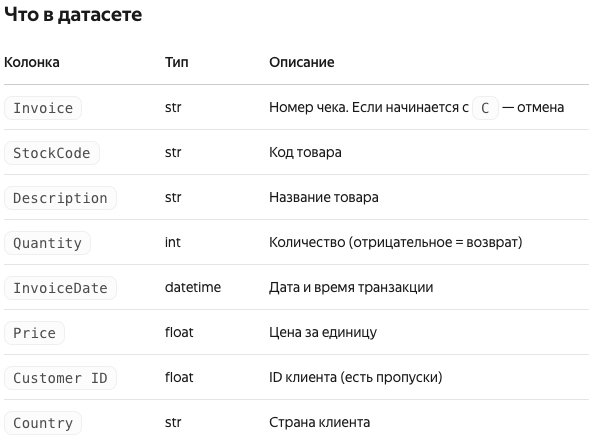

Для основной части проекта рекомендуется выбрать 12 полных последовательных месяцев. Конкретные границы периода студент определяет самостоятельно и фиксирует в начале анализа. Если выбран другой период, необходимо кратко объяснить, почему он подходит для задачи.

Рассмотрим представленный датасет с точки зрения диапазона дат.

In [6]:
# Функция отображения диапазона дат
def info_date_range(dataframe, column_name):
    min_date = dataframe[column_name].min()
    max_date = dataframe[column_name].max()
    print(f"Минимальное значение даты: {min_date}")
    print(f"Максимальное значение даты: {max_date}")

In [7]:
# Проверим интервал дат в данных
info_date_range(df, 'InvoiceDate')

Минимальное значение даты: 2009-12-01 07:45:00
Максимальное значение даты: 2011-12-09 12:50:00


Датасет охватывает диапазон с 1 декабря 2009 по 9 декабря 2011, то есть декабрь 2011 в данных не полный. Нам для исследования нужно окно, которое:
- включает пиковый сезон (декабрь - Рождество в Великобритании, пик продаж для подарков),
- включает летний спад (июнь–август),
- не включает неполный декабрь 2011.

Выбираем период декабрь 2010 - ноябрь 2011 - полный сезонный цикл, без обрезанных данных. Это более свежий срез данных: чем ближе период к концу датасета, тем актуальнее картина ассортимента: меньше выведенных товаров, больше текущих позиций, актуальные цены и спрос.

Если взять, например, декабрь 2009 - декабрь 2011, то первый месяц (декабрь 2009) и последний (декабрь 2011) будут «неполными» с точки зрения анализа: у первого не будет предыдущего месяца для сравнения и оценки тренда, у последнего - последующего (к тому же он и сам в нашем случае неполный). Для расчёта вариации и трендов это создаёт перекосы. 

Анализ за 12 месяцев даёт актуальные рекомендации «что держать сейчас», а не усреднённые по двум годам, где часть данных уже неактуальна.

## Этап 1. Знакомство с данными и правила очистки

Начните не с расчета ABC, а с понимания набора данных. Покажите размер таблицы, типы полей, временной диапазон и основные проблемы качества данных. Не требуется устранять любую аномалию. Важно решить, влияет ли она на текущую бизнес-задачу.

Обязательно исследуйте пропуски, дубликаты, отмененные операции, отрицательные значения Quantity, нулевые или необычные значения UnitPrice, корректность дат и неоднозначные StockCode. Для каждого существенного правила очистки оставьте короткое пояснение в ноутбуке: что обнаружено, какое решение принято и почему.

Для студентов базового уровня. Достаточно корректно выделить период, привести даты к нужному типу, сформировать выборку реальных продаж и объяснить обработку отмен, отрицательных количеств и пропусков. Не нужно придумывать сложную систему очистки ради самой очистки.

Для сильных студентов. Можно отдельно исследовать связь отрицательных операций с исходными покупками, специальные StockCode, изменение описаний одного SKU, выбросы по количеству и цене. Это должно помогать качеству решения, а не превращаться в бесконечную чистку.

In [8]:
# Основная информация о наборе данных 
info_summary(df)

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,2009-12-01 07:45:00,6.95,13085.0,United Kingdom
1,489434,79323P,PINK CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom
2,489434,79323W,WHITE CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom
3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48,2009-12-01 07:45:00,2.10,13085.0,United Kingdom
4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,2009-12-01 07:45:00,1.25,13085.0,United Kingdom


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1067371 entries, 0 to 1067370
Data columns (total 8 columns):
 #   Column       Non-Null Count    Dtype         
---  ------       --------------    -----         
 0   Invoice      1067371 non-null  object        
 1   StockCode    1067371 non-null  object        
 2   Description  1062989 non-null  object        
 3   Quantity     1067371 non-null  int64         
 4   InvoiceDate  1067371 non-null  datetime64[ns]
 5   Price        1067371 non-null  float64       
 6   Customer ID  824364 non-null   float64       
 7   Country      1067371 non-null  object        
dtypes: datetime64[ns](1), float64(2), int64(1), object(4)
memory usage: 65.1+ MB


None

Датасет содержит 1 067 371 строк и 8 колонок. Типы полей: Invoice, StockCode, Description и Country - object, Quantity - int64, Price и Customer ID - float64, InvoiceDate — datetime64[ns]. В столбцах Description и Customer ID есть пропуски. 

In [9]:
# Функция для расчёта количества и доли пропусков в столбцах
def count_and_percentage_missing_values(df):
    missing_count = df.isna().sum()
    missing_percentage = (df.isna().sum() / len(df)) * 100
    return pd.DataFrame({'Количество пропусков': missing_count, 'Доля пропусков, %': missing_percentage})

In [10]:
# Посчитаем пропуски в столбцах датасета
count_and_percentage_missing_values(df)

,Количество пропусков,"Доля пропусков, %"
Invoice,0,0.000000
StockCode,0,0.000000
Description,4382,0.410541
Quantity,0,0.000000
InvoiceDate,0,0.000000
Price,0,0.000000
Customer ID,243007,22.766873
Country,0,0.000000


В столбце Description (описание/название товара) 0,41% пропусков (незначительно). В столбце Customer ID (идентификатор покупателя) - 22,77% пропусков, но столбец не обязателен для ABC.

In [11]:
# Функция отображения количества дубликатов
def info_duplicated(dataframe):
    display(f'Количество дубликатов: {dataframe.duplicated().sum()}')
    display(f'Процент дубликатов: {dataframe.duplicated().sum() / len(df) * 100}')

In [12]:
# Проверим данные на наличие дубликатов
info_duplicated(df)

'Количество дубликатов: 34335'

'Процент дубликатов: 3.2167821685243467'

In [13]:
def analyze_data_quality(df: pd.DataFrame) -> dict:
    """
    Проводит разведочный анализ качества данных для датасета Online Retail II.
    Возвращает словарь с метриками и флагами проблем для принятия решений по очистке.
    """
    total_rows = len(df)
    metrics = {}

    print("=" * 70)

    # ── 1. Отменённые операции (Invoice начинается с 'C') ──
    print("\n1. ОТМЕНЁННЫЕ ОПЕРАЦИИ (Invoice начинается с 'C')")
    print("-" * 50)

    cancelled = df[df['Invoice'].astype(str).str.startswith('C')]
    cancelled_qty_negative = cancelled[cancelled['Quantity'] < 0]
    cancelled_qty_positive = cancelled[cancelled['Quantity'] > 0]
    cancelled_qty_zero = cancelled[cancelled['Quantity'] == 0]

    pct_cancelled = len(cancelled) / total_rows * 100
    print(f"Всего строк с 'C' в Invoice: {len(cancelled):,} ({pct_cancelled:.2f}%)")
    print(f"  - Quantity < 0: {len(cancelled_qty_negative):,}")
    print(f"  - Quantity > 0: {len(cancelled_qty_positive):,}")
    print(f"  - Quantity = 0: {len(cancelled_qty_zero):,}")

    cancelled_sum = (cancelled['Quantity'] * cancelled['Price']).sum()
    print(f"Сумма (Quantity × Price) по отменам: £{cancelled_sum:,.0f}")

    if len(cancelled_qty_positive) > 0:
        print(f"\n⚠️ НАЙДЕНЫ АНОМАЛИИ: отмены с положительным Quantity ({len(cancelled_qty_positive):,} строк)")
        print("Примеры:")
        print(cancelled_qty_positive[
            ['Invoice', 'StockCode', 'Description', 'Quantity', 'Price']
        ].head(10).to_string(index=False))

    metrics['cancelled'] = {
        'count': len(cancelled),
        'pct': pct_cancelled,
        'anomalies_positive_qty': len(cancelled_qty_positive),
        'total_revenue_loss': cancelled_sum
    }

    # ── 2. Отрицательные значения Quantity (вне отмен) ──
    print("\n2. ОТРИЦАТЕЛЬНЫЕ QUANTITY (не связанные с отменами)")
    print("-" * 50)

    neg_qty = df[df['Quantity'] < 0]
    neg_qty_with_c = neg_qty[neg_qty['Invoice'].astype(str).str.startswith('C')]
    neg_qty_without_c = neg_qty[~neg_qty['Invoice'].astype(str).str.startswith('C')]

    pct_neg_total = len(neg_qty) / total_rows * 100
    pct_anomaly = len(neg_qty_without_c) / len(neg_qty) * 100 if len(neg_qty) > 0 else 0

    print(f"Всего Quantity < 0: {len(neg_qty):,} ({pct_neg_total:.2f}%)")
    print(f"  - Связаны с отменами (C): {len(neg_qty_with_c):,}")
    print(f"  - Аномалии (нет C): {len(neg_qty_without_c):,} ({pct_anomaly:.1f}% от всех отрицательных)")

    if len(neg_qty_without_c) > 0:
        print("\nПримеры аномальных отрицательных Quantity:")
        print(neg_qty_without_c[
            ['Invoice', 'StockCode', 'Description', 'Quantity', 'Price']
        ].head(10).to_string(index=False))

    print(f"\nСтатистика отрицательных Quantity:")
    print(neg_qty['Quantity'].describe().to_string())

    print(f"\nТоп-5 по модулю:")
    print(neg_qty.nsmallest(5, 'Quantity')[
        ['Invoice', 'StockCode', 'Description', 'Quantity', 'Price']
    ].to_string(index=False))

    metrics['negative_quantity'] = {
        'count_total': len(neg_qty),
        'pct_total': pct_neg_total,
        'count_anomalies': len(neg_qty_without_c),
        'pct_anomalies_of_neg': pct_anomaly
    }

    # ── 3. Проблемы с ценой (Price) ──
    print("\n3. ПРОБЛЕМЫ С ЦЕНОЙ (Price)")
    print("-" * 50)

    zero_price = df[df['Price'] == 0]
    neg_price = df[df['Price'] < 0]

    print(f"Строк с Price = 0: {len(zero_price):,} ({len(zero_price) / total_rows * 100:.2f}%)")
    print(f"Строк с Price < 0: {len(neg_price):,}")
    print(f"Строк с Price > 0: {len(df[df['Price'] > 0]):,}")

    print(f"\nСтатистика Price:")
    print(df['Price'].describe().to_string())

    print(f"\nТоп-10 самых дорогих позиций:")
    print(df.nlargest(10, 'Price')[
        ['Invoice', 'StockCode', 'Description', 'Quantity', 'Price']
    ].to_string(index=False))

    if len(zero_price) > 0:
        print(f"\nПримеры строк с Price = 0:")
        print(zero_price[
            ['Invoice', 'StockCode', 'Description', 'Quantity', 'Price']
        ].head(10).to_string(index=False))

        print(f"\nУникальных StockCode с Price = 0: {zero_price['StockCode'].nunique()}")
        print(f"Топ-10 StockCode с Price = 0 по частоте:")
        print(zero_price['StockCode'].value_counts().head(10).to_string())

    if len(neg_price) > 0:
        print(f"\n⚠️ НАЙДЕНЫ ОТРИЦАТЕЛЬНЫЕ ЦЕНЫ:")
        print(neg_price[
            ['Invoice', 'StockCode', 'Description', 'Quantity', 'Price']
        ].head(10).to_string(index=False))

    price_variants = df.groupby('StockCode')['Price'].nunique()
    multi_price = price_variants[price_variants > 1]
    print(f"\nТоваров с более чем одной ценой: {len(multi_price):,} из {df['StockCode'].nunique():,}")
    print("Это нормально — цена может меняться со временем или по акциям.")

    metrics['price_issues'] = {
        'zero_count': len(zero_price),
        'negative_count': len(neg_price),
        'multi_price_count': len(multi_price)
    }

    # ── 4. Корректность дат ──
    print("\n4. КОРРЕКТНОСТЬ ДАТ (InvoiceDate)")
    print("-" * 50)

    print(f"Тип колонки InvoiceDate: {df['InvoiceDate'].dtype}")
    min_date = df['InvoiceDate'].min()
    max_date = df['InvoiceDate'].max()
    null_dates = df['InvoiceDate'].isnull().sum()

    print(f"Минимальная дата: {min_date}")
    print(f"Максимальная дата: {max_date}")
    print(f"Дней в данных: {(max_date - min_date).days}")
    print(f"Пустых дат: {null_dates} ({null_dates / total_rows * 100:.2f}%)")

    df['Month'] = df['InvoiceDate'].dt.to_period('M')
    monthly = df.groupby('Month').size()
    print(f"\nСтрок по месяцам:")
    print(monthly.to_string())

    all_months = pd.period_range(df['Month'].min(), df['Month'].max(), freq='M')
    missing_months = [m for m in all_months if m not in monthly.index]
    print(f"\nМесяцев без данных: {len(missing_months)}")
    if missing_months:
        print(f"  Пропущенные месяцы: {missing_months}")

    last_month = df['Month'].max()
    last_month_data = df[df['Month'] == last_month]
    days_in_last_month = last_month_data['InvoiceDate'].dt.day.nunique()
    print(f"\nПоследний месяц ({last_month}): {days_in_last_month} дн. с продажами")
    print(f"Последняя дата: {max_date.strftime('%Y-%m-%d')}")
    is_incomplete = days_in_last_month < 15
    if is_incomplete:
        print(f"  ⚠️ Месяц {last_month} неполный — данные обрываются ({days_in_last_month} дн. из ~30)")

    metrics['dates'] = {
        'min': min_date,
        'max': max_date,
        'null_count': null_dates,
        'last_month': str(last_month),
        'days_in_last_month': days_in_last_month,
        'is_incomplete': is_incomplete
    }

    # ── 5. Неоднозначные StockCode и описания ──
    print("\n5. НЕОДНОЗНАЧНЫЕ STOCKCODE И ОПИСАНИЯ")
    print("-" * 50)

    print(f"Тип колонки StockCode: {df['StockCode'].dtype}")

    standard_mask = df['StockCode'].astype(str).str.match(r'^\d{5}[A-Z]?$')
    non_standard = df[~standard_mask]

    print(f"Всего уникальных StockCode: {df['StockCode'].nunique():,}")
    print(f"Стандартных (5 цифр + опц. буква): {df[standard_mask]['StockCode'].nunique():,}")
    print(f"Нестандартных: {non_standard['StockCode'].nunique():,}")
    print(f"Строк с нестандартными кодами: {len(non_standard):,} ({len(non_standard) / total_rows * 100:.2f}%)")

    non_std_summary = (
        non_standard.groupby('StockCode')
        .agg(
            count=('Invoice', 'count'),
            description=('Description', 'first'),
            avg_price=('Price', 'mean'),
            total_qty=('Quantity', 'sum'),
        )
        .sort_values('count', ascending=False)
        .reset_index()
    )

    print(f"\nВсе нестандартные StockCode:")
    print(non_std_summary.to_string(index=False))

    no_desc = df[df['Description'].isnull()]
    print(f"\nСтрок без Description: {len(no_desc):,} ({len(no_desc) / total_rows * 100:.2f}%)")

    weird_pattern = r'(?i)(manual|adjust|wrong|error|lost|broken|return|found|correct|test|sample|throw|missing|damaged|check|update|sold|route|resolve|balance|canceled)'
    weird_desc = df[df['Description'].astype(str).str.contains(weird_pattern, na=False)]
    print(f"\nСтрок с подозрительными описаниями: {len(weird_desc):,}")
    if len(weird_desc) > 0:
        print("Топ-15 таких описаний:")
        print(weird_desc['Description'].value_counts().head(15).to_string())

    metrics['stockcode_issues'] = {
        'non_standard_codes_count': non_standard['StockCode'].nunique(),
        'non_standard_rows_pct': len(non_standard) / total_rows * 100,
        'weird_description_count': len(weird_desc),
        'no_description_count': len(no_desc)
    }

    print("\n" + "=" * 70)
    print("АНАЛИЗ ЗАВЕРШЕН. Метрики сохранены в словаре `metrics`.")
    return metrics

In [14]:
quality_metrics = analyze_data_quality(df)


1. ОТМЕНЁННЫЕ ОПЕРАЦИИ (Invoice начинается с 'C')
--------------------------------------------------
Всего строк с 'C' в Invoice: 19,494 (1.83%)
  - Quantity < 0: 19,493
  - Quantity > 0: 1
  - Quantity = 0: 0
Сумма (Quantity × Price) по отменам: £-1,526,668

⚠️ НАЙДЕНЫ АНОМАЛИИ: отмены с положительным Quantity (1 строк)
Примеры:
Invoice StockCode Description  Quantity  Price
C496350         M      Manual         1 373.57

2. ОТРИЦАТЕЛЬНЫЕ QUANTITY (не связанные с отменами)
--------------------------------------------------
Всего Quantity < 0: 22,950 (2.15%)
  - Связаны с отменами (C): 19,493
  - Аномалии (нет C): 3,457 (15.1% от всех отрицательных)

Примеры аномальных отрицательных Quantity:
Invoice StockCode     Description  Quantity  Price
 489464     21733    85123a mixed       -96    0.0
 489463     71477           short      -240    0.0
 489467    85123A     21733 mixed      -192    0.0
 489521     21646             NaN       -50    0.0
 489655     20683             NaN       -4

### 1.1 Правила очистки датасета:

1. Пропуски

в Description
Обнаружено: 4 382 строки (0,41%) без описания товара. Решение: строки оставить. Description не участвует в расчёте ABC/XYZ - анализ идёт по StockCode. При необходимости заполнить описанием из других строк с тем же StockCode. Почему: пропуск описания не влияет на выручку или спрос. Удаление этих строк приведёт к потере реальных продаж и искажению ABC/XYZ - товары потеряют часть выручки и могут сместиться в более низкую группу.

в Customer ID
Обнаружено: 243007 строк (22,77%) без идентификатора покупателя. Решение: строки оставить. Customer ID не используется в ABC/XYZ-анализе. Почему: 22,77% - это четверть датасета. Удаление этих строк уберёт четверть выручки и объёмов продаж, радикально исказит ABC-ранжирование и приведёт к ошибочным выводам по товарной политике. Отсутствие Customer ID никак не мешает расчёту: ABC строится по StockCode и выручке, XYZ - по StockCode и месячному спросу.

2. Дубликаты

Обнаружено: 34 335 полных дубликатов строк (3,22%). Решение: удалить. Почему: дубликаты задваивают выручку и объём продаж, смещают границы ABC-групп и завышают коэффициент вариации в XYZ. 

3. Отменённые операции (Invoice начинается с 'C')

Обнаружено: 19 494 строки (1,83%), из них 19 493 с отрицательным Quantity. Одна аномалия - C496350 с положительным Quantity (Manual-операция). Сумма по отменам: £−1 526 668. Решение: удалить все строки, где Invoice начинается с 'C'. Почему: это возвраты и отмены - не реальный спрос. Если оставить, товары с большими возвратами получат заниженную выручку и могут ошибочно сместиться из группы A в B. Аномалия с положительным Quantity - служебная операция, тоже не товар.

4. Отрицательные Quantity без 'C'

Обнаружено: 3 457 строк (15,1% от всех отрицательных). Это складские корректировки: lost, damaged, short, mixed, thrown away. Все с Price = 0. Решение: удалить все строки с Quantity < 0 (после удаления отмен их не останется, но фильтр страховочный). Почему: это не продажи, а внутренние корректировки склада. Они не отражают спрос и искажают ABC/XYZ.

5. Нулевая цена (Price = 0)

Обнаружено: 6 202 строки (0,58%), 2 971 уникальный StockCode. Часто сопутствует складским операциям (lost, damaged, short), но встречается и у обычных товаров. Решение: удалить все строки с Price = 0. Почему: нулевая выручка по строке искажает ABC-ранжирование - товар выглядит «бесплатным» и не вносит вклада, хотя физически отгружался. Для товарной политики важна реальная выручка.

6. Отрицательная цена (Price < 0)

Обнаружено: 5 строк, все с StockCode B и описанием Adjust bad debt (корректировка безнадёжных долгов). Решение: удалить все строки с Price < 0. Почему: это бухгалтерская корректировка, а не продажа товара.

7. Нестандартные StockCode (служебные коды)

Обнаружено: 240 нестандартных кодов, 10 739 строк (1,01%). Среди них:

Явно нетоварные: POST (почтовые расходы), DOT (доставка dotcom), M и m (ручные операции), C2 (транспорт), D (скидки), S (образцы), B (безнадёжные долги), BANK CHARGES, AMAZONFEE, ADJUST, ADJUST2, CRUK (комиссия благотворительности), TEST001/TEST002 (тестовые записи), gift_0001_* (подарочные ваучеры - финансовый инструмент, не товар). Похожие на товары, но с нестандартным кодом: 15056BL, 79323LP, 84997a, 84509a и т. д. - это реальные товары с нестандартным форматом кода (буквы в нижнем регистре, дополнительный суффикс).

Решение: удалить строку с явными служебными кодами. Коды реальных товаров оставить. Почему: служебные операции - это не часть ассортимента и не предмет товарной политики. Они искажают выручку и ранжирование. Реальные товары с нестандартным кодом - часть ассортимента, их нельзя терять.

8. Неполный последний месяц
   
Обнаружено: декабрь 2011 содержит данные только за 8 дней (1-9 декабря). Решение: ограничить период анализа декабрём 2010 - ноябрём 2011. Почему: неполный месяц искажает коэффициент вариации - товары выглядят менее стабильными, чем есть на самом деле, и могут ошибочно попасть в Z.

Для сильных студентов. Можно отдельно исследовать связь отрицательных операций с исходными покупками, специальные StockCode, изменение описаний одного SKU, выбросы по количеству и цене. Это должно помогать качеству решения, а не превращаться в бесконечную чистку.

1. Исследуем связь возвратов с покупками

Проверяем, есть ли для каждой отмены парная исходная покупка (тот же клиент, товар, количество). Если >70% имеют пару - это легитимные возвраты, удаляем без сомнений. Если много без пары - часть корректировки, но всё равно удаляем, потому что ни возвраты, ни корректировки не должны влиять на ABC/XYZ.

In [15]:
# ── 1. Связь отрицательных операций с исходными покупками ──
print("=" * 70)
print("1. СВЯЗЬ ОТРИЦАТЕЛЬНЫХ ОПЕРАЦИЙ С ИСХОДНЫМИ ПОКУПКАМИ")
print("=" * 70)

neg = df[df['Quantity'] < 0].copy()
neg['AbsQty'] = neg['Quantity'].abs()
neg['StockCodeUpper'] = neg['StockCode'].astype(str).str.upper()

pos = df[df['Quantity'] > 0].copy()
pos['StockCodeUpper'] = pos['StockCode'].astype(str).str.upper()

# Убираем строки без Customer ID — для них проверку не провести
neg_with_cid = neg[neg['Customer ID'].notna()].copy()
no_customer = len(neg) - len(neg_with_cid)

# Merge по ключам: StockCode, Customer ID
merged = neg_with_cid.merge(
    pos[['StockCodeUpper', 'Customer ID', 'Quantity', 'InvoiceDate']],
    on=['StockCodeUpper', 'Customer ID'],
    suffixes=('_neg', '_pos')
)

# Оставляем только пары, где количество совпадает и покупка раньше отмены
matched_pairs = merged[
    (merged['Quantity_pos'] == merged['AbsQty'])
    & (merged['InvoiceDate_pos'] <= merged['InvoiceDate_neg'])
]

# Составной ключ для подсчёта уникальных neg-строк, нашедших пару
neg_with_cid['row_key'] = (
    neg_with_cid['Invoice'].astype(str) + '_'
    + neg_with_cid['StockCodeUpper'] + '_'
    + neg_with_cid['AbsQty'].astype(str)
)
matched_pairs['row_key'] = (
    matched_pairs['Invoice'].astype(str) + '_'
    + matched_pairs['StockCodeUpper'] + '_'
    + matched_pairs['AbsQty'].astype(str)
)

matched_rows = matched_pairs['row_key'].nunique()
total_neg_rows = len(neg_with_cid)
unmatched_rows = total_neg_rows - matched_rows

total_neg = len(neg)
print(f"Всего отрицательных операций: {total_neg:,}")
print(f"  Найдена парная покупка: {matched_rows:,} ({matched_rows/total_neg*100:.1f}%)")
print(f"  Парная покупка не найдена: {unmatched_rows:,} ({unmatched_rows/total_neg*100:.1f}%)")
print(f"  Нет Customer ID - нельзя проверить: {no_customer:,} ({no_customer/total_neg*100:.1f}%)")

print(f"\nВывод для ABC/XYZ:")
pct_matched = matched_rows / total_neg * 100
if pct_matched > 70:
    print(f"  {pct_matched:.0f}% отрицательных операций имеют парную покупку.")
    print(f"  Это легитимные возвраты. Удаляем — они не реальный спрос.")
else:
    print(f"  Менее 70% имеют парную покупку. Часть - складские корректировки.")
    print(f"  Всё равно удаляем все Quantity < 0 - ни возвраты, ни корректировки")
    print(f"  не должны влиять на ABC/XYZ.")

1. СВЯЗЬ ОТРИЦАТЕЛЬНЫХ ОПЕРАЦИЙ С ИСХОДНЫМИ ПОКУПКАМИ
Всего отрицательных операций: 22,950
  Найдена парная покупка: 6,553 (28.6%)
  Парная покупка не найдена: 12,191 (53.1%)
  Нет Customer ID - нельзя проверить: 4,206 (18.3%)

Вывод для ABC/XYZ:
  Менее 70% имеют парную покупку. Часть - складские корректировки.
  Всё равно удаляем все Quantity < 0 - ни возвраты, ни корректировки
  не должны влиять на ABC/XYZ.


2. Специальные коды - финальная сводка
   
Сводим в один список все служебные коды с пояснением, что каждый значит. Подтверждаем: PADS - это товар (подкладки под подушки), оставляем. Остальное удаляем.

In [16]:
# ── 2. Специальные StockCode — краткая сводка ──
print("\n" + "=" * 70)
print("2. СПЕЦИАЛЬНЫЕ STOCKCODE - КРАТКАЯ СВОДКА")
print("=" * 70)

# Создаём столбец с выручкой Revenue
df['Revenue'] = df['Quantity'] * df['Price']

service_keywords = {
    'POST': 'почтовые расходы',
    'DOT': 'доставка dotcom',
    'M': 'ручная операция',
    'm': 'ручная операция',
    'C2': 'транспорт',
    'D': 'скидка',
    'S': 'образцы',
    'B': 'безнадёжные долги',
    'BANK CHARGES': 'банковские комиссии',
    'AMAZONFEE': 'комиссия Amazon',
    'ADJUST': 'корректировка',
    'ADJUST2': 'корректировка',
    'CRUK': 'благотворительная комиссия',
    'TEST001': 'тестовая запись',
    'TEST002': 'тестовая запись',
    'GIFT': 'подарочный ваучер',
    'gift_0001_10': 'подарочный ваучер',
    'gift_0001_20': 'подарочный ваучер',
    'gift_0001_30': 'подарочный ваучер',
    'gift_0001_40': 'подарочный ваучер',
    'gift_0001_50': 'подарочный ваучер',
    'gift_0001_60': 'подарочный ваучер',
    'gift_0001_70': 'подарочный ваучер',
    'gift_0001_80': 'подарочный ваучер',
    'gift_0001_90': 'подарочный ваучер',
    'PADS': 'подкладки (возможно товар — оставляем)',
}

service_codes = [k for k, v in service_keywords.items() if v != 'подкладки (возможно товар - оставляем)']
service_mask = df['StockCode'].isin(service_codes)
service_rows = df[service_mask]

print(f"Служебных кодов: {len(service_codes)}")
print(f"Строк со служебными кодами: {len(service_rows):,} ({len(service_rows)/len(df)*100:.2f}%)")
print(f"Выручка по служебным кодам: £{service_rows['Revenue'].sum():,.0f}")
print(f"\nВсе служебные коды удаляем - это не товары.")

# Отдельно: PADS — оставляем (это реальный товар)
pads_count = len(df[df['StockCode'] == 'PADS'])
print(f"\nКод 'PADS' ({pads_count:,} строк) - оставляем как товар.")


2. СПЕЦИАЛЬНЫЕ STOCKCODE - КРАТКАЯ СВОДКА
Служебных кодов: 26
Строк со служебными кодами: 5,931 (0.56%)
Выручка по служебным кодам: £-96,411

Все служебные коды удаляем - это не товары.

Код 'PADS' (19 строк) - оставляем как товар.


3. Описание одного SKU
   
Показывает, сколько SKU имеют несколько разных описаний. Это не влияет на ABC/XYZ (группировка по StockCode), но для отчёта нужно знать: брать самое частое описание. Если у одного StockCode кардинально разные описания - возможно, код переиспользовался для разных товаров, но в рамках этого датасета это скорее опечатки и вариации написания.

In [17]:
# ── 3. Изменение описаний одного SKU ──
print("\n" + "=" * 70)
print("3. ИЗМЕНЕНИЕ ОПИСАНИЙ ОДНОГО SKU")
print("=" * 70)

desc_per_sku = df.groupby('StockCode')['Description'].nunique()
multi_desc = desc_per_sku[desc_per_sku > 1].sort_values(ascending=False)

print(f"Всего SKU: {df['StockCode'].nunique():,}")
print(f"SKU с одним описанием: {(desc_per_sku == 1).sum():,}")
print(f"SKU с несколькими описаниями: {len(multi_desc):,} ({len(multi_desc)/df['StockCode'].nunique()*100:.1f}%)")

print(f"\nТоп-20 SKU с наибольшим числом разных описаний:")
for code in multi_desc.head(20).index:
    descs = df[df['StockCode'] == code]['Description'].value_counts()
    print(f"\n  {code} ({len(descs)} описаний):")
    print(descs.head(5).to_string().replace('\n', '\n    '))

# Проверяем: это опечатки или реально разные товары?
print(f"\nВывод для ABC/XYZ:")
print(f"  Описание не используется в расчёте - группировка по StockCode.")
print(f"  Разные описания не влияют на ABC/XYZ.")
print(f"  Для отчёта берём самое частое описание каждого SKU.")


3. ИЗМЕНЕНИЕ ОПИСАНИЙ ОДНОГО SKU
Всего SKU: 5,305
SKU с одним описанием: 3,718
SKU с несколькими описаниями: 1,232 (23.2%)

Топ-20 SKU с наибольшим числом разных описаний:

  20713 (9 описаний):
JUMBO BAG OWLS                  1372
    found                              1
    missing                            1
    wrongly coded 23343                1
    wrongly marked. 23343 in box       1

  22423 (7 описаний):
REGENCY CAKESTAND 3 TIER    4412
    damaged                        3
    damages                        2
    smashed                        2
    faulty                         2

  21181 (7 описаний):
PLEASE ONE PERSON METAL SIGN     1730
    PLEASE ONE PERSON  METAL SIGN     181
    adjustment                          2
    on cargo order                      1
    missing                             1

  23084 (7 описаний):
RABBIT NIGHT LIGHT                     1051
    Amazon                                    1
    website fixed                             1
    add

4. Выбросы по Quantity и Price

Для оценки выбросов по Quantity и Price нужно сначала применить уже принятые нами ранее правила очистки и подготовки датасета - иначе статистика будет искажена.

### 1.2 Очищаем датасет

In [18]:
# ── Создаём копию исходного датасета и к нему применяем все принятые нами правила очистки и подготовки ──
df_bcg = df.copy()
original_len = len(df_bcg)
print(f"Исходный датасет: {original_len:,} строк\n")

Исходный датасет: 1,067,371 строк



In [19]:
# 1. Дубликаты
before = len(df_bcg)
df_bcg = df_bcg.drop_duplicates().reset_index(drop=True)
print(f"1. Дубликаты удалены: {before - len(df_bcg):,} (было {before:,} → {len(df_bcg):,})")

1. Дубликаты удалены: 34,335 (было 1,067,371 → 1,033,036)


In [20]:
# 2. Отменённые операции (строки, где Invoice начинается с 'C')
before = len(df_bcg)
df_bcg = df_bcg[~df_bcg['Invoice'].astype(str).str.startswith('C')].copy()
print(f"2. Отменённые операции удалены: {before - len(df_bcg):,} (было {before:,} → {len(df_bcg):,})")

2. Отменённые операции удалены: 19,104 (было 1,033,036 → 1,013,932)


In [21]:
# 3. Отрицательные Quantity (страховочный фильтр - после отмен их почти не остаётся)
before = len(df_bcg)
df_bcg = df_bcg[df_bcg['Quantity'] > 0].copy()
print(f"3. Quantity ≤ 0 удалены: {before - len(df_bcg):,} (было {before:,} → {len(df_bcg):,})")

3. Quantity ≤ 0 удалены: 3,393 (было 1,013,932 → 1,010,539)


In [22]:
# 4. Price ≤ 0 (нулевые и отрицательные)
before = len(df_bcg)
df_bcg = df_bcg[df_bcg['Price'] > 0].copy()
print(f"4. Price ≤ 0 удалены: {before - len(df_bcg):,} (было {before:,} → {len(df_bcg):,})")

4. Price ≤ 0 удалены: 2,626 (было 1,010,539 → 1,007,913)


In [23]:
# 5. Служебные StockCode
service_codes = [
    'POST', 'DOT', 'M', 'm', 'C2', 'D', 'S', 'B',
    'BANK CHARGES', 'AMAZONFEE',
    'ADJUST', 'ADJUST2', 'CRUK',
    'TEST001', 'TEST002',
    'GIFT',
    'gift_0001_10', 'gift_0001_20', 'gift_0001_30',
    'gift_0001_40', 'gift_0001_50', 'gift_0001_60',
    'gift_0001_70', 'gift_0001_80', 'gift_0001_90',
]
before = len(df_bcg)
df_bcg = df_bcg[~df_bcg['StockCode'].isin(service_codes)].copy()
print(f"5. Служебные StockCode удалены: {before - len(df_bcg):,} (было {before:,} → {len(df_bcg):,})")

5. Служебные StockCode удалены: 4,556 (было 1,007,913 → 1,003,357)


In [24]:
# 6. DCGS-коды без описания — служебные записи
dcgs_mask = (
    df_bcg['StockCode'].astype(str).str.startswith('DCGS')
    & df_bcg['Description'].isna()
)
before = len(df_bcg)
df_bcg = df_bcg[~dcgs_mask].copy()
print(f"6. DCGS без описания удалены: {before - len(df_bcg):,} (было {before:,} → {len(df_bcg):,})")

6. DCGS без описания удалены: 0 (было 1,003,357 → 1,003,357)


In [25]:
# 7. Пропуски в Description заполняем самым частым описанием по StockCode
def fill_desc_mode(group):
    if group.notna().sum() == 0:
        return group.fillna('UNKNOWN')
    mode_val = group.mode()
    if len(mode_val) == 0:
        return group.fillna('UNKNOWN')
    return group.fillna(mode_val.iloc[0])

df_bcg['Description'] = df_bcg.groupby('StockCode')['Description'].transform(fill_desc_mode)

remaining_na = df_bcg['Description'].isna().sum()
print(f"7. Description заполнен по StockCode, остаток NaN: {remaining_na}")

7. Description заполнен по StockCode, остаток NaN: 0


In [26]:
# 8. Customer ID оставляем как есть (22,77% пропусков, не нужен для ABC/XYZ)
print(f"8. Customer ID: пропуски оставлены ({df_bcg['Customer ID'].isna().sum():,} строк) — не нужен для ABC/XYZ")

8. Customer ID: пропуски оставлены (226,761 строк) — не нужен для ABC/XYZ


In [27]:
# 9. Ранее мы уже добавили в df новый столбец с выручкой Revenue
print("9. Колонка Revenue уже создана ранее — используем существующую.")

9. Колонка Revenue уже создана ранее — используем существующую.


In [28]:
# 10. Принятый нами ранее временной диапазон: декабрь 2010 - ноябрь 2011
df_bcg['Month'] = df_bcg['InvoiceDate'].dt.to_period('M')
before = len(df_bcg)
df_clean = df_bcg[(df_bcg['Month'] >= '2010-12') & (df_bcg['Month'] < '2011-12')].copy()
print(f"10. Временной период ограничен (2010-12  2011-11): удалено {before - len(df_bcg):,} (было {before:,} → {len(df_clean):,})")

10. Временной период ограничен (2010-12  2011-11): удалено 0 (было 1,003,357 → 497,787)


In [29]:
# ── Итоговая сводка по очистке датасета ──
total_removed = original_len - len(df_clean)
print(f"\n{'=' * 60}")
print(f"ИТОГО")
print(f"{'=' * 60}")
print(f"Исходный датасет:     {original_len:,} строк")
print(f"После очистки:       {len(df_clean):,} строк")
print(f"Удалено:             {total_removed:,} строк ({total_removed / original_len * 100:.1f}%)")
print(f"Уникальных SKU:       {df_clean['StockCode'].nunique():,}")
print(f"Уникальных клиентов:  {df_clean['Customer ID'].nunique():,}")
print(f"Общая выручка:        £{df_clean['Revenue'].sum():,.0f}")
print(f"Период:               {df_clean['InvoiceDate'].min().date()} - {df_clean['InvoiceDate'].max().date()}")


ИТОГО
Исходный датасет:     1,067,371 строк
После очистки:       497,787 строк
Удалено:             569,584 строк (53.4%)
Уникальных SKU:       3,905
Уникальных клиентов:  4,293
Общая выручка:        £9,632,728
Период:               2010-12-01 - 2011-11-30


4. Возвращаемся к выбросам по Quantity и Price

In [30]:
# --- Выбросы по Quantity (количество в строке заказа) ---
print("--- ВЫБРОСЫ ПО КОЛИЧЕСТВУ (Quantity) ---")

print("Базовая статистика по Quantity:")
q_median = df_clean['Quantity'].median()
q_mean = df_clean['Quantity'].mean()
q_std = df_clean['Quantity'].std()
q99 = df_clean['Quantity'].quantile(0.99)
q999 = df_clean['Quantity'].quantile(0.999)
q_max = df_clean['Quantity'].max()

print(f"  Медиана:         {q_median:,.0f}")
print(f"  Среднее:         {q_mean:,.1f}")
print(f"  Std:             {q_std:,.1f}")
print(f"  99-й перцентиль: {q99:,.0f}")
print(f"  99.9-й перцентиль: {q999:,.0f}")
print(f"  Максимум:        {q_max:,.0f}\n")

print("Распределение Quantity по перцентилям:")
for p in [50, 75, 90, 95, 99, 99.5, 99.9, 100]:
    val = df_clean['Quantity'].quantile(p / 100)
    print(f"  P{p:<6}: {val:,.0f}")

print("\nТоп-15 строк с наибольшим Quantity (ручная проверка):")
top_15_qty = df_clean.nlargest(15, 'Quantity')[
    ['Invoice', 'StockCode', 'Description', 'Quantity', 'Price', 'Revenue']
]
print(top_15_qty.to_string(index=False))

print("\nПоиск выбросов по методу 1.5×IQR:")
q1 = df_clean['Quantity'].quantile(0.25)
q3 = df_clean['Quantity'].quantile(0.75)
iqr = q3 - q1
lower_bound = q1 - 1.5 * iqr
upper_bound = q3 + 1.5 * iqr

outliers_qty = df_clean[df_clean['Quantity'] > upper_bound]
print(f"  Q1 = {q1:,.0f}, Q3 = {q3:,.0f}, IQR = {iqr:,.0f}")
print(f"  Верхняя граница 1.5×IQR: {upper_bound:,.0f}")
print(f"  Строк-выбросов: {len(outliers_qty):,} ({len(outliers_qty)/len(df_clean)*100:.2f}% от всех строк)")
print(f"  Доля выручки этих строк: £{outliers_qty['Revenue'].sum():,.0f} "
      f"({outliers_qty['Revenue'].sum()/df_clean['Revenue'].sum()*100:.1f}%)")

print("\n--- ИТОГОВЫЙ ВЫВОД ПО QUANTITY ---")
print(f"  Крупные заказы (Quantity > {q99:,.0f}) — это {len(df_clean[df_clean['Quantity'] > q99]):,} строк.")

--- ВЫБРОСЫ ПО КОЛИЧЕСТВУ (Quantity) ---
Базовая статистика по Quantity:
  Медиана:         4
  Среднее:         10.5
  Std:             111.8
  99-й перцентиль: 100
  99.9-й перцентиль: 456
  Максимум:        74,215

Распределение Quantity по перцентилям:
  P50    : 4
  P75    : 12
  P90    : 24
  P95    : 30
  P99    : 100
  P99.5  : 171
  P99.9  : 456
  P100   : 74,215

Топ-15 строк с наибольшим Quantity (ручная проверка):
Invoice StockCode                         Description  Quantity  Price  Revenue
 541431     23166      MEDIUM CERAMIC TOP STORAGE JAR     74215   1.04 77183.60
 573008     84077   WORLD WAR 2 GLIDERS ASSTD DESIGNS      4800   0.21  1008.00
 554868     22197                SMALL POPCORN HOLDER      4300   0.72  3096.00
 544612     22053               EMPIRE DESIGN ROSETTE      3906   0.82  3202.92
 560599     18007 ESSENTIAL BALM 3.5g TIN IN ENVELOPE      3186   0.06   191.16
 540815     21108  FAIRY CAKE FLANNEL ASSORTED COLOUR      3114   2.10  6539.40
 550461   

Вывод 

Крупные заказы (Quantity > 100) - это 4,655 строк. Это типично для e‑commerce с B2B‑сегментом или крупными розничными клиентами: один заказ может содержать тысячи единиц одного SKU. Это оптовые покупки, реальный спрос, не удаляем: они важны для ABC-анализа: именно крупные заказы формируют группу A. Для XYZ-анализа аномально крупные заказы могут искажать коэффициент вариации, но на уровне агрегации по месяцам по SKU это сглаживается.

Можно выделить отдельный сегмент «оптовые заказы» (например, Quantity > 100 или > 200) и анализировать его отдельно: динамика по таким заказам, доля в выручке, стабильность клиентов.

Можно добавить флаг is_bulk_order = Quantity > 100 и использовать его в отчётах, чтобы видеть, какая доля выручки приходится на крупные заказы и как они распределены по SKU и периодам:

In [31]:
df_clean['is_bulk_order'] = df_clean['Quantity'] > 100
bulk_share = df_clean.loc[df_clean['is_bulk_order'], 'Revenue'].sum() / df_clean['Revenue'].sum()
print(f"Доля выручки от крупных заказов (Quantity > 100): {bulk_share:.1%}")

Доля выручки от крупных заказов (Quantity > 100): 17.6%


Q1=1, Q3=12, IQR=11
Верхняя граница 1.5×IQR = 28
Медиана = 4, Среднее = 10.5
P99 = 100


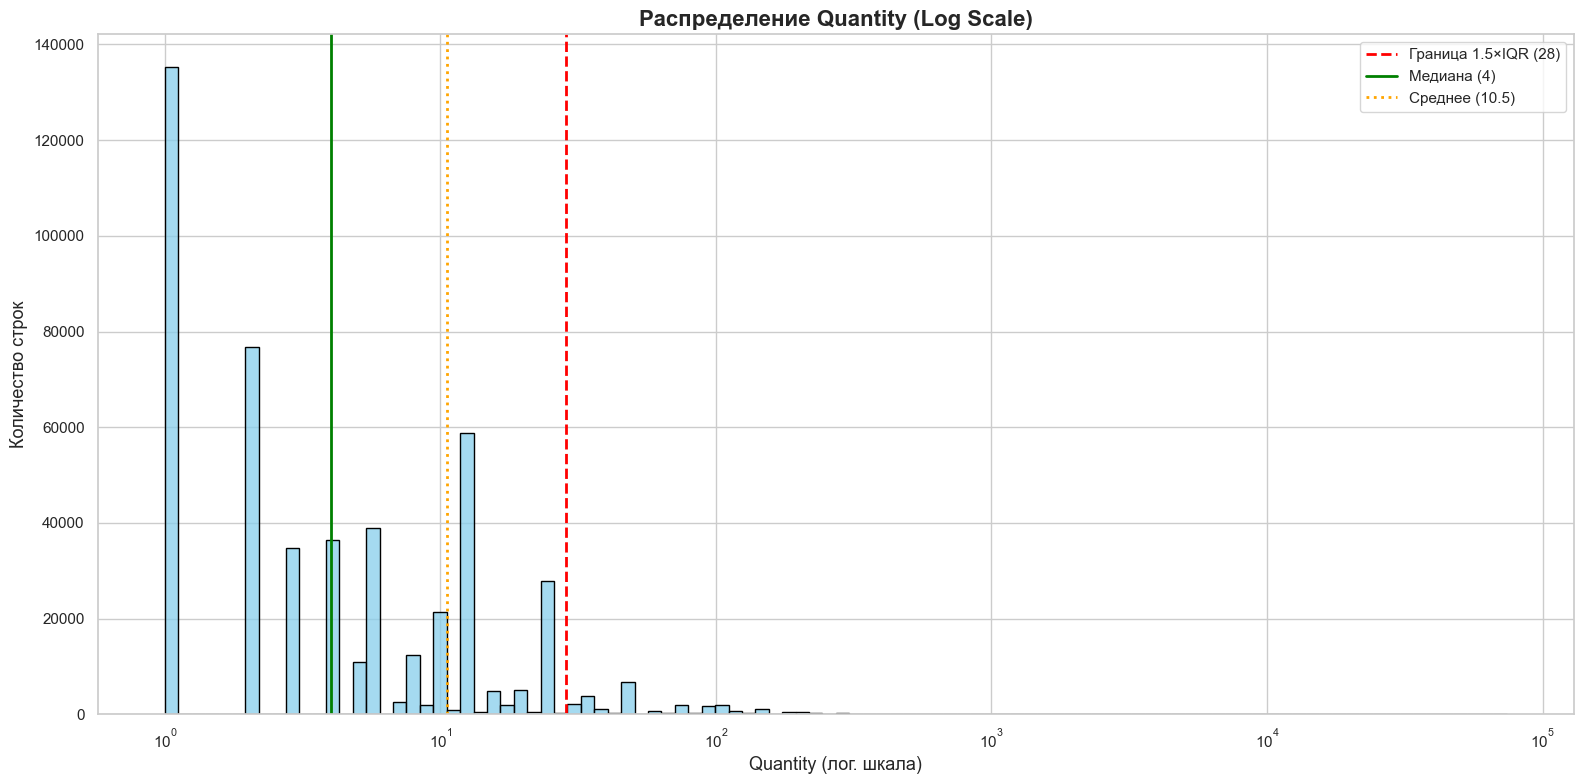

In [32]:
# Построим несколько визуализаций выбросов по количеству

# Настройка стиля графиков
sns.set_theme(style="whitegrid")
plt.rcParams['font.size'] = 12

# Пересчитываем границы
q1 = df_clean['Quantity'].quantile(0.25)
q3 = df_clean['Quantity'].quantile(0.75)
iqr = q3 - q1
upper_bound = q3 + 1.5 * iqr
q99 = df_clean['Quantity'].quantile(0.99)
median_qty = df_clean['Quantity'].median()
mean_qty = df_clean['Quantity'].mean()

df_clean['is_outlier_qty'] = df_clean['Quantity'] > upper_bound

print(f"Q1={q1:.0f}, Q3={q3:.0f}, IQR={iqr:.0f}")
print(f"Верхняя граница 1.5×IQR = {upper_bound:,.0f}")
print(f"Медиана = {median_qty:.0f}, Среднее = {mean_qty:,.1f}")
print(f"P99 = {q99:,.0f}")

# ==========================================
# 1. Гистограмма с логарифмической шкалой
# ==========================================
fig, ax = plt.subplots(figsize=(16, 8))

sns.histplot(df_clean['Quantity'], bins=100, log_scale=True,
             ax=ax, color='skyblue', edgecolor='black')

ax.axvline(upper_bound, color='red', linestyle='--', linewidth=2,
           label=f'Граница 1.5×IQR ({upper_bound:,.0f})')
ax.axvline(median_qty, color='green', linestyle='-', linewidth=2,
           label=f'Медиана ({median_qty:,.0f})')
ax.axvline(mean_qty, color='orange', linestyle=':', linewidth=2,
           label=f'Среднее ({mean_qty:,.1f})')

ax.set_title('Распределение Quantity (Log Scale)', fontsize=16, fontweight='bold')
ax.set_xlabel('Quantity (лог. шкала)', fontsize=13)
ax.set_ylabel('Количество строк', fontsize=13)
ax.legend(fontsize=11)

plt.tight_layout()
plt.show()

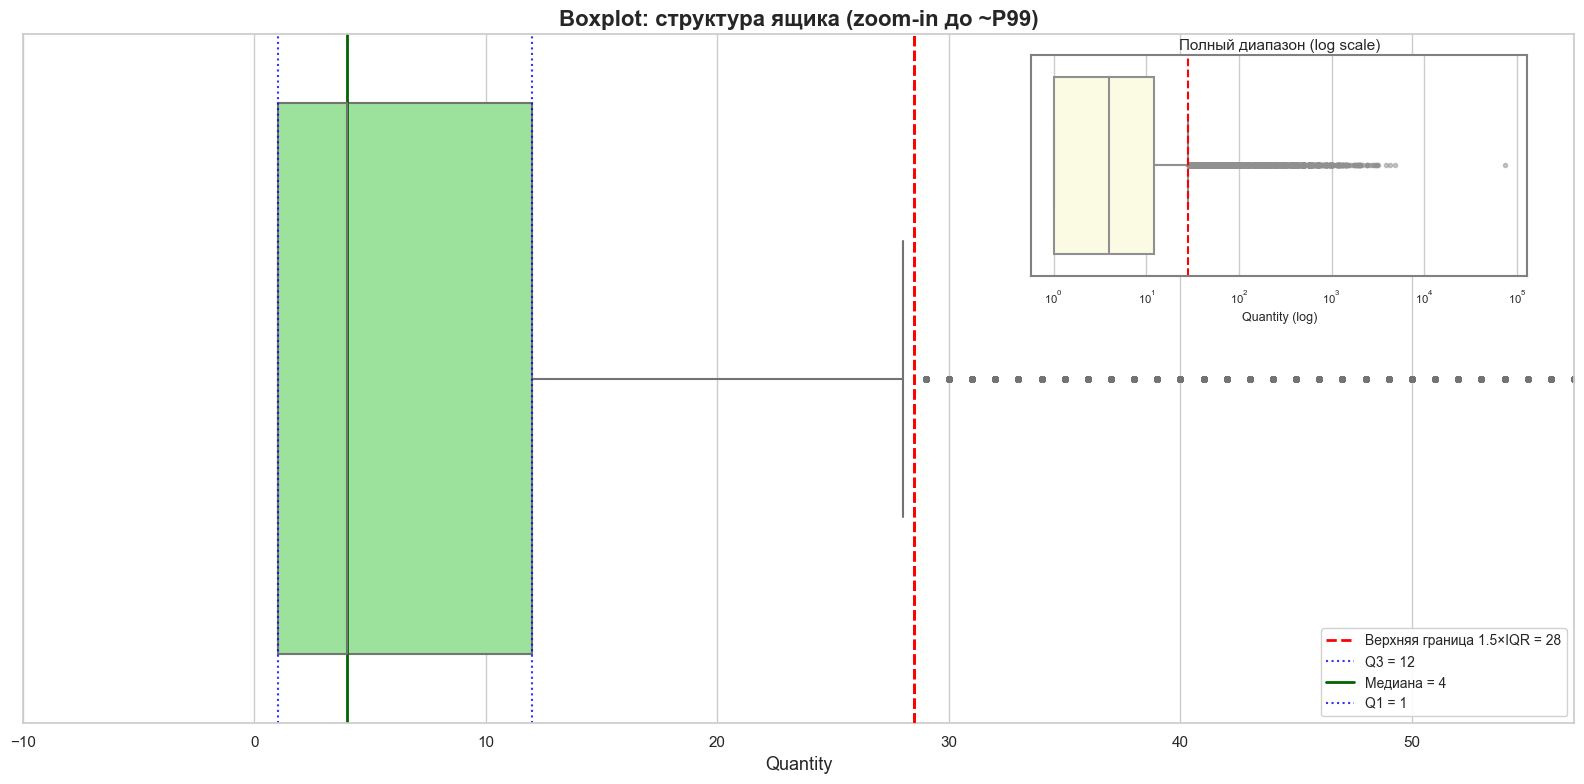

In [33]:
# ==========================================
# 2. Boxplot: основной (zoom-in) + врезка (полный диапазон)
# ==========================================
fig, ax_main = plt.subplots(figsize=(16, 8))

# Основной boxplot с ОБРЕЗАННОЙ осью для читаемости
xlim_max = min(q99 * 1.5, upper_bound * 2)

sns.boxplot(x=df_clean['Quantity'], ax=ax_main,
            color='lightgreen', fliersize=4,
            flierprops=dict(marker='o', color='red', alpha=0.6))

ax_main.set_xlim(-10, xlim_max)
ax_main.set_title('Boxplot: структура ящика (zoom-in до ~P99)', fontsize=16, fontweight='bold')
ax_main.set_xlabel('Quantity', fontsize=13)

# Вертикальные линии с подписями в легенде
ax_main.axvline(upper_bound, color='red', linestyle='--', linewidth=2,
                label=f'Верхняя граница 1.5×IQR = {upper_bound:,.0f}')
ax_main.axvline(q3, color='blue', linestyle=':', linewidth=1.5, alpha=0.8,
                label=f'Q3 = {q3:,.0f}')
ax_main.axvline(median_qty, color='darkgreen', linestyle='-', linewidth=2,
                label=f'Медиана = {median_qty:,.0f}')
ax_main.axvline(q1, color='blue', linestyle=':', linewidth=1.5, alpha=0.8,
                label=f'Q1 = {q1:,.0f}')

# Легенда
ax_main.legend(loc='lower right', fontsize=10, framealpha=0.9)

# ВРЕЗКА (inset): полный boxplot с выбросами
ax_inset = ax_main.inset_axes([0.65, 0.65, 0.32, 0.32])

sns.boxplot(x=df_clean['Quantity'], ax=ax_inset,
            color='lightyellow', fliersize=3,
            flierprops=dict(marker='o', color='red', alpha=0.5))

ax_inset.set_xscale('log')
ax_inset.set_title('Полный диапазон (log scale)', fontsize=11, pad=4)
ax_inset.set_xlabel('Quantity (log)', fontsize=9)
ax_inset.tick_params(labelsize=8)
ax_inset.axvline(upper_bound, color='red', linestyle='--', linewidth=1.5)

for spine in ax_inset.spines.values():
    spine.set_edgecolor('gray')
    spine.set_linewidth(1.5)

# Линия верхней границы 1.5×IQR
ax_main.axvline(upper_bound, color='red', linestyle='--', linewidth=2,
                label=f'Верхняя граница 1.5×IQR = {upper_bound:,.0f}',
                zorder=10)

plt.tight_layout()
plt.show()

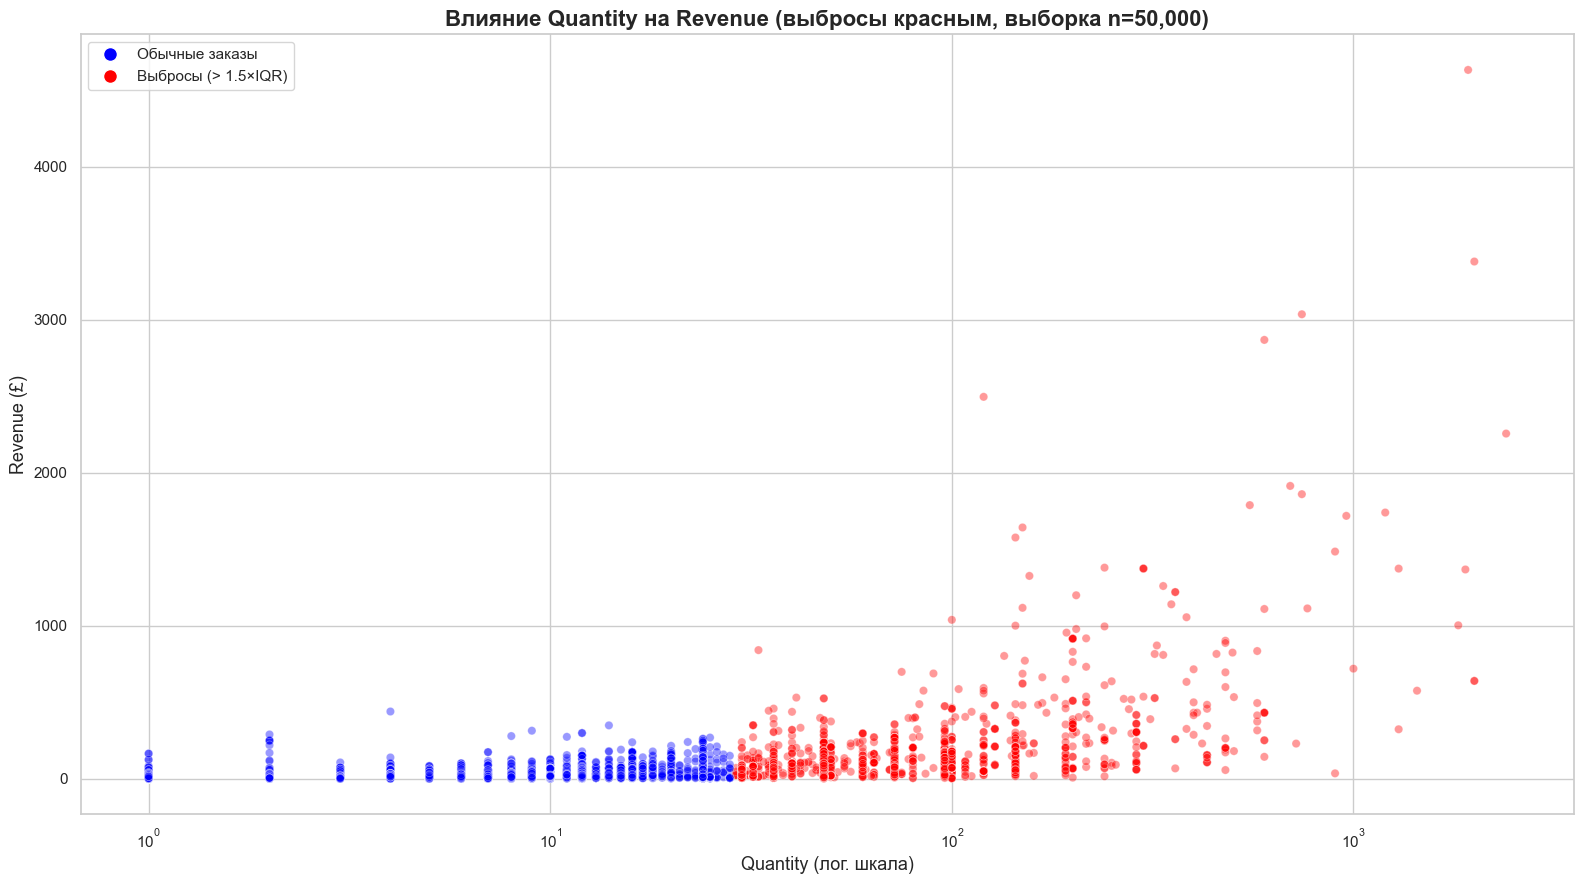

In [34]:
# ==========================================
# 3. Scatter plot: Quantity vs Revenue
# ==========================================
sample_size = min(50000, len(df_clean))
df_sample = df_clean.sample(n=sample_size, random_state=42)

fig, ax = plt.subplots(figsize=(16, 9))

sns.scatterplot(
    x='Quantity', y='Revenue',
    data=df_sample,
    hue='is_outlier_qty',
    palette={False: 'blue', True: 'red'},
    alpha=0.4,
    ax=ax,
    legend=False
)

ax.set_xscale('log')
ax.set_title(f'Влияние Quantity на Revenue (выбросы красным, выборка n={sample_size:,})',
             fontsize=16, fontweight='bold')
ax.set_xlabel('Quantity (лог. шкала)', fontsize=13)
ax.set_ylabel('Revenue (£)', fontsize=13)

legend_elements = [
    Line2D([0], [0], marker='o', color='w', markerfacecolor='blue',
           markersize=10, label='Обычные заказы'),
    Line2D([0], [0], marker='o', color='w', markerfacecolor='red',
           markersize=10, label='Выбросы (> 1.5×IQR)')
]
ax.legend(handles=legend_elements, loc='upper left', fontsize=11)

plt.tight_layout()
plt.show()

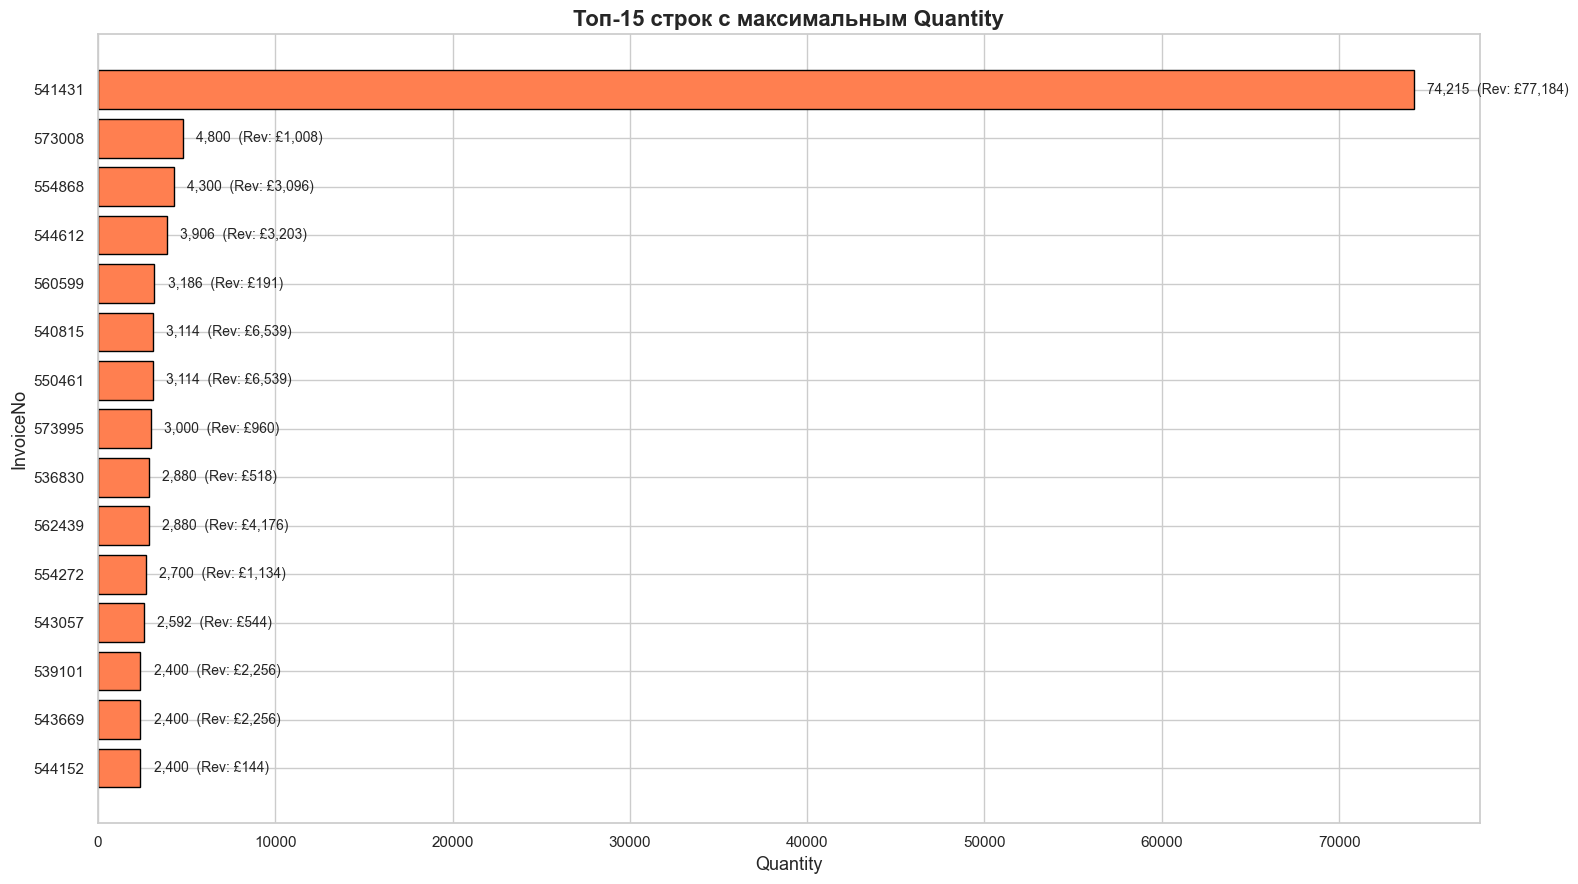

In [35]:
# ==========================================
# 4. Топ-15 заказов по Quantity (Barplot)
# ==========================================
top_15_qty = df_clean.nlargest(15, 'Quantity')[['Invoice', 'Quantity', 'Revenue']].reset_index(drop=True)

fig, ax = plt.subplots(figsize=(16, 9))

bars = ax.barh(top_15_qty['Invoice'].astype(str), top_15_qty['Quantity'],
               color='coral', edgecolor='black')

ax.set_title('Топ-15 строк с максимальным Quantity', fontsize=16, fontweight='bold')
ax.set_xlabel('Quantity', fontsize=13)
ax.set_ylabel('InvoiceNo', fontsize=13)
ax.invert_yaxis()

# Подписи значений на барах
for bar, qty, rev in zip(bars, top_15_qty['Quantity'], top_15_qty['Revenue']):
    ax.text(bar.get_width() + max(top_15_qty['Quantity']) * 0.01,
            bar.get_y() + bar.get_height() / 2,
            f'{qty:,.0f}  (Rev: £{rev:,.0f})',
            va='center', fontsize=10)

plt.tight_layout()
plt.show()

In [36]:
# Выбросы по Price (цена за единицу)
print("\n--- ВЫБРОСЫ ПО ЦЕНЕ (Price) ---")

print("Базовая статистика по Price:")
p_median = df_clean['Price'].median()
p_mean = df_clean['Price'].mean()
p99 = df_clean['Price'].quantile(0.99)
p999 = df_clean['Price'].quantile(0.999)
p_max = df_clean['Price'].max()

print(f"  Медиана:         £{p_median:,.2f}")
print(f"  Среднее:         £{p_mean:,.2f}")
print(f"  99-й перцентиль: £{p99:,.2f}")
print(f"  99.9-й перцентиль: £{p999:,.2f}")
print(f"  Максимум:        £{p_max:,.2f}\n")

print("Распределение Price по перцентилям:")
for p in [50, 75, 90, 95, 99, 99.5, 99.9, 100]:
    val = df_clean['Price'].quantile(p / 100)
    print(f"  P{p:<6}: £{val:,.2f}")

print("\nТоп-15 строк с самой высокой ценой (ручная проверка):")
top_15_price = df_clean.nlargest(15, 'Price')[
    ['Invoice', 'StockCode', 'Description', 'Quantity', 'Price', 'Revenue']
]
print(top_15_price.to_string(index=False))

print("\nПоиск выбросов по методу 1.5×IQR:")
p1 = df_clean['Price'].quantile(0.25)
p3 = df_clean['Price'].quantile(0.75)
iqr_p = p3 - p1
lower_p = p1 - 1.5 * iqr_p
upper_p = p3 + 1.5 * iqr_p

outliers_price = df_clean[df_clean['Price'] > upper_p]
print(f"  Q1 = £{p1:,.2f}, Q3 = £{p3:,.2f}, IQR = £{iqr_p:,.2f}")
print(f"  Верхняя граница 1.5×IQR: £{upper_p:,.2f}")
print(f"  Строк-выбросов: {len(outliers_price):,} ({len(outliers_price)/len(df_clean)*100:.2f}% от всех строк)")
print(f"  Доля выручки этих строк: £{outliers_price['Revenue'].sum():,.0f} "
      f"({outliers_price['Revenue'].sum()/df_clean['Revenue'].sum()*100:.1f}%)")

print("\nПроверка, есть ли SKU, где цена выбивается на фоне остальных строк того же SKU:")
price_stats = df_clean.groupby('StockCode')['Price'].agg(['mean', 'std', 'count'])
# SKU с большой вариацией цены (std > mean — коэффициент вариации > 1)
high_var_sku = price_stats[(price_stats['std'] > price_stats['mean']) & (price_stats['count'] > 5)]
print(f"  SKU с коэффициентом вариации цены > 1 (при >5 строк): {len(high_var_sku):,}")
if len(high_var_sku) > 0:
    print("  Примеры (топ-10 по вариации):")
    for code in high_var_sku.sort_values('std', ascending=False).head(10).index:
        prices = df_clean[df_clean['StockCode'] == code]['Price']
        print(f"    {code}: mean=£{prices.mean():.2f}, min=£{prices.min():.2f}, max=£{prices.max():.2f}, n={len(prices)}")


--- ВЫБРОСЫ ПО ЦЕНЕ (Price) ---
Базовая статистика по Price:
  Медиана:         £2.08
  Среднее:         £3.28
  99-й перцентиль: £16.63
  99.9-й перцентиль: £34.00
  Максимум:        £649.50

Распределение Price по перцентилям:
  P50    : £2.08
  P75    : £4.13
  P90    : £7.65
  P95    : £9.95
  P99    : £16.63
  P99.5  : £19.96
  P99.9  : £34.00
  P100   : £649.50

Топ-15 строк с самой высокой ценой (ручная проверка):
Invoice StockCode                    Description  Quantity  Price  Revenue
 556444     22502 PICNIC BASKET WICKER 60 PIECES        60  649.5  38970.0
 556446     22502 PICNIC BASKET WICKER 60 PIECES         1  649.5    649.5
 536835     22655    VINTAGE RED KITCHEN CABINET         1  295.0    295.0
 539080     22655    VINTAGE RED KITCHEN CABINET         1  295.0    295.0
 540647     22655    VINTAGE RED KITCHEN CABINET         1  295.0    295.0
 543253     22655    VINTAGE RED KITCHEN CABINET         1  295.0    295.0
 546480     22656   VINTAGE BLUE KITCHEN CABINET 

Вывод: 

Дорогие позиции (>£17) - это 4,514 строк. Это премиум-товары или редкие позиции, не удаляем.

По разбросу цены у одного SKU:

22502 - самый яркий случай: 466 строк, средняя цена £10.30, но есть строки по £649.50. Это не случайность при таком объёме, скорее всего, разные варианты товара (например, упаковка из 1 шт. и из 50 шт.) продаются под одним кодом, но с разной ценой.

Остальные SKU (35637C, 37370, 22856, 37482P и т. д.) имеют разброс в 5-10 раз - это могут быть:

- промоакции и распродажи (товар продавался по £1.06, потом по £16.13);
- разные фасовки под одним кодом (поштучно vs. набором);
- ошибки ввода цены кассиром.

Для ABC-анализа это не проблема. Группировка идёт по StockCode, а выручка суммируется по всем строкам SKU. Независимо от того, по какой цене продавалась каждая строка, суммарная выручка по SKU будет корректной.

Для XYZ-анализа тоже не критично. XYZ считается по месячному спросу (Quantity), а не по цене. Разброс цены внутри SKU не влияет на коэффициент вариации по месяцам.

Эти 78 SKU можно пометить флагом для будущего разбора (не для удаления).

In [37]:
# Флаг SKU с аномальной вариацией цены
price_var_sku = set(high_var_sku.index)
df_clean['price_var_flag'] = df_clean['StockCode'].isin(price_var_sku)
print(f"Строк с флагом price_var_flag: {df_clean['price_var_flag'].sum():,}")

Строк с флагом price_var_flag: 5,797


Q1: £1.25 | Q3: £4.13 | IQR: £2.88
Граница выбросов (1.5×IQR): £8.45
Всего строк-выбросов: 34,151


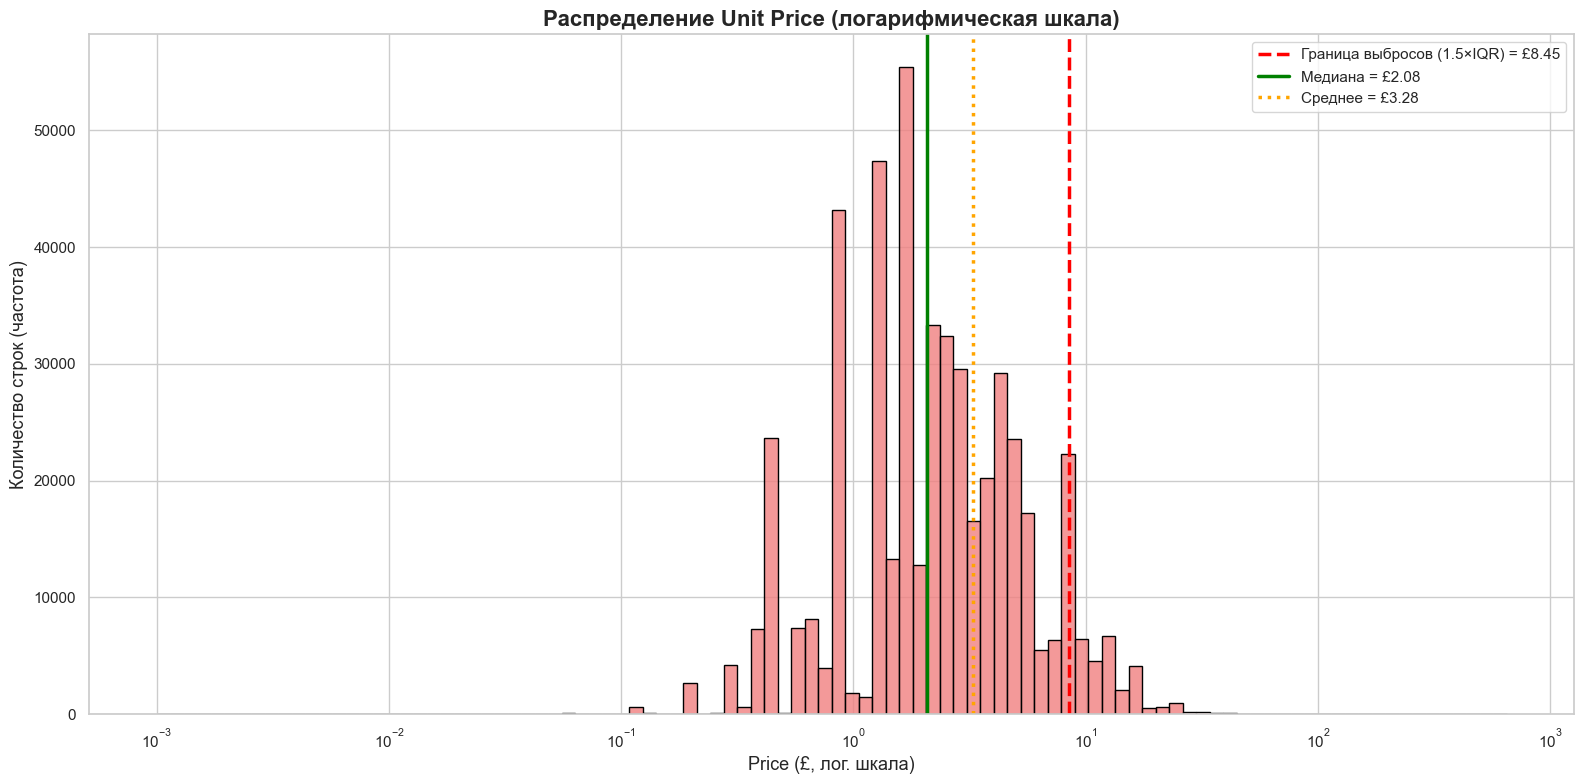

In [38]:
# Построим несколько визуализаций выбросов по цене

# Настройка стиля
sns.set_theme(style="whitegrid")
plt.rcParams['font.size'] = 12

# ==========================================
# 0. Подготовка метрик для Price
# ==========================================
p1 = df_clean['Price'].quantile(0.25)
p3 = df_clean['Price'].quantile(0.75)
iqr_p = p3 - p1
upper_p = p3 + 1.5 * iqr_p
p99 = df_clean['Price'].quantile(0.99)
p_median = df_clean['Price'].median()
p_mean = df_clean['Price'].mean()

# Флаг выброса для дальнейшего использования
df_clean['is_outlier_price'] = df_clean['Price'] > upper_p

print(f"Q1: £{p1:.2f} | Q3: £{p3:.2f} | IQR: £{iqr_p:.2f}")
print(f"Граница выбросов (1.5×IQR): £{upper_p:.2f}")
print(f"Всего строк-выбросов: {df_clean['is_outlier_price'].sum():,}")

# ==========================================
# 1. Гистограмма с логарифмической шкалой по X
# ==========================================
fig, ax = plt.subplots(figsize=(16, 8))

# log_scale=True применяет логарифм к оси X (цены)
sns.histplot(df_clean['Price'], bins=100, log_scale=True, 
             ax=ax, color='lightcoral', edgecolor='black', alpha=0.8)

ax.axvline(upper_p, color='red', linestyle='--', linewidth=2.5, 
           label=f'Граница выбросов (1.5×IQR) = £{upper_p:,.2f}')
ax.axvline(p_median, color='green', linestyle='-', linewidth=2.5, 
           label=f'Медиана = £{p_median:,.2f}')
ax.axvline(p_mean, color='orange', linestyle=':', linewidth=2.5, 
           label=f'Среднее = £{p_mean:,.2f}')

ax.set_title('Распределение Unit Price (логарифмическая шкала)', fontsize=16, fontweight='bold')
ax.set_xlabel('Price (£, лог. шкала)', fontsize=13)
ax.set_ylabel('Количество строк (частота)', fontsize=13)
ax.legend(fontsize=11, loc='upper right')

plt.tight_layout()
plt.show()

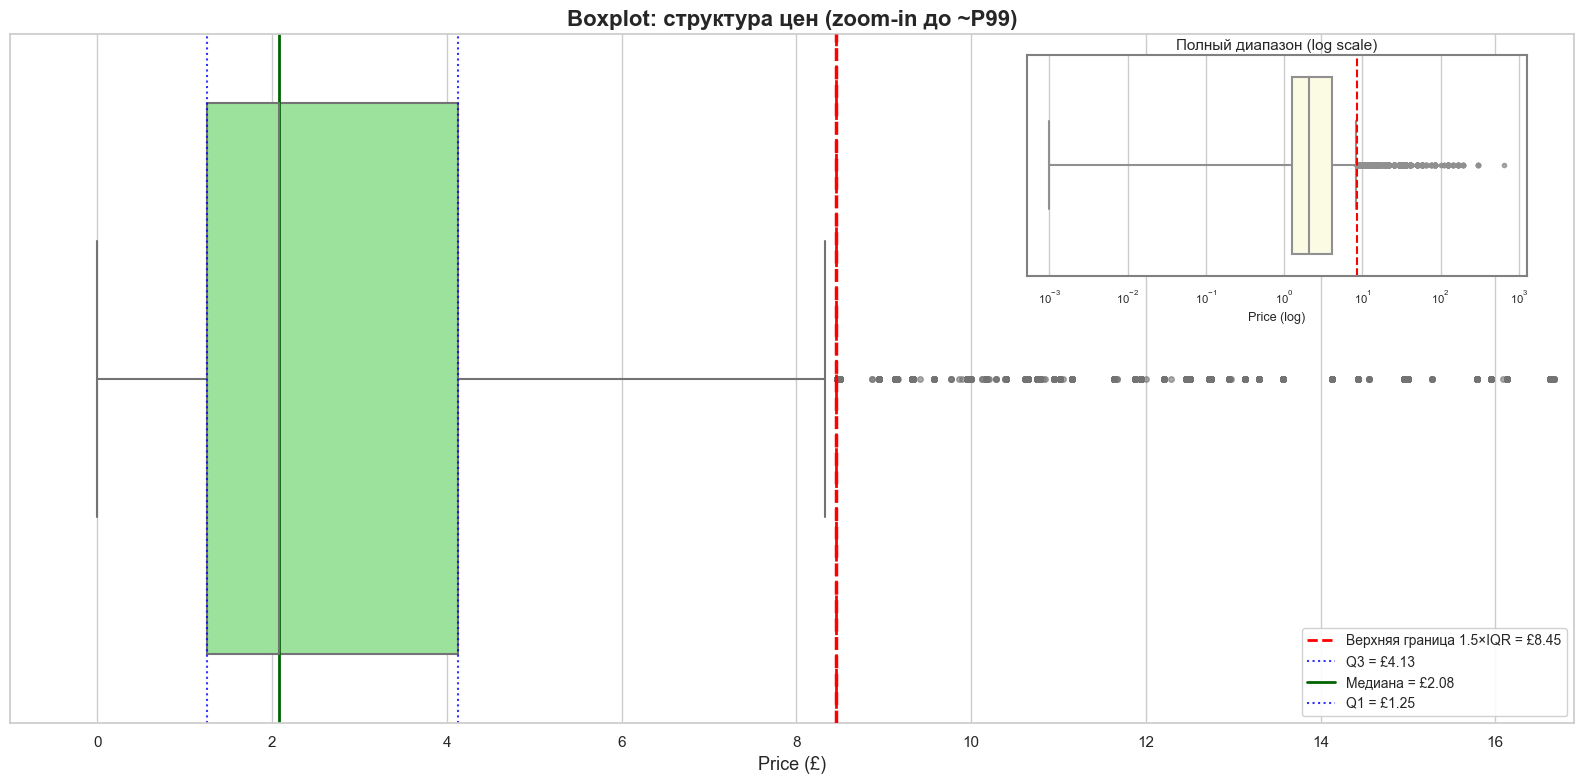

In [39]:
# ==========================================
# 2. Boxplot: структура ящика (zoom-in) + врезка (полный диапазон)
# ==========================================
fig, ax_main = plt.subplots(figsize=(16, 8))

# Основной boxplot с ОБРЕЗАННОЙ осью для читаемости
# Ограничиваем правую границу, чтобы "ящик" был хорошо виден
xlim_max = min(p99 * 1.5, upper_p * 2)

sns.boxplot(x=df_clean['Price'], ax=ax_main,
            color='lightgreen', fliersize=4,
            flierprops=dict(marker='o', color='red', alpha=0.6))

ax_main.set_xlim(-1, xlim_max) # Цена не может быть < 0, ставим -1 для отступа
ax_main.set_title('Boxplot: структура цен (zoom-in до ~P99)', fontsize=16, fontweight='bold')
ax_main.set_xlabel('Price (£)', fontsize=13)

# Вертикальные линии с подписями
ax_main.axvline(upper_p, color='red', linestyle='--', linewidth=2,
                label=f'Верхняя граница 1.5×IQR = £{upper_p:,.2f}')
ax_main.axvline(p3, color='blue', linestyle=':', linewidth=1.5, alpha=0.8,
                label=f'Q3 = £{p3:,.2f}')
ax_main.axvline(p_median, color='darkgreen', linestyle='-', linewidth=2,
                label=f'Медиана = £{p_median:,.2f}')
ax_main.axvline(p1, color='blue', linestyle=':', linewidth=1.5, alpha=0.8,
                label=f'Q1 = £{p1:,.2f}')

ax_main.legend(loc='lower right', fontsize=10, framealpha=0.9)

# ВРЕЗКА (inset): полный boxplot с выбросами
ax_inset = ax_main.inset_axes([0.65, 0.65, 0.32, 0.32])

sns.boxplot(x=df_clean['Price'], ax=ax_inset,
            color='lightyellow', fliersize=3,
            flierprops=dict(marker='o', color='red', alpha=0.5))

ax_inset.set_xscale('log')
ax_inset.set_title('Полный диапазон (log scale)', fontsize=11, pad=4)
ax_inset.set_xlabel('Price (log)', fontsize=9)
ax_inset.tick_params(labelsize=8)
ax_inset.axvline(upper_p, color='red', linestyle='--', linewidth=1.5)

# Оформление рамки врезки
for spine in ax_inset.spines.values():
    spine.set_edgecolor('gray')
    spine.set_linewidth(1.5)

# Линия верхней границы 1.5×IQR
ax_main.axvline(upper_p, color='red', linestyle='--', linewidth=2.5, zorder=10)

plt.tight_layout()
plt.show()

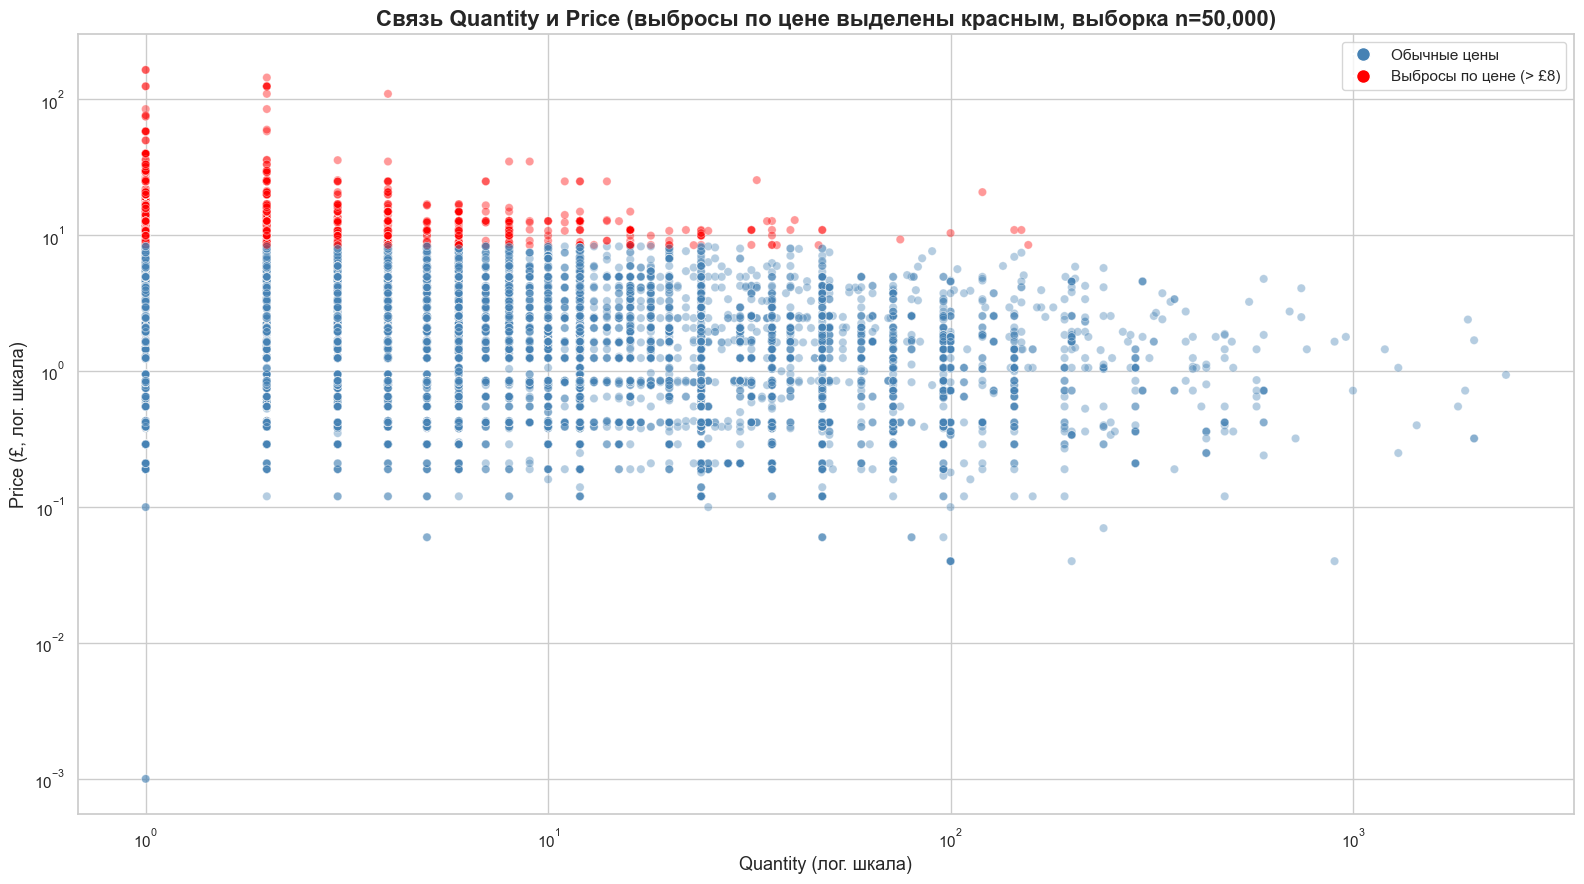

In [40]:
# ==========================================
# 3. Scatter plot: Price vs Quantity (логарифмические шкалы)
# ==========================================
sample_size = min(50000, len(df_clean))
df_sample = df_clean.sample(n=sample_size, random_state=42)

fig, ax = plt.subplots(figsize=(16, 9))

sns.scatterplot(
    x='Quantity', y='Price',
    data=df_sample,
    hue='is_outlier_price',
    palette={False: 'steelblue', True: 'red'},
    alpha=0.4,
    ax=ax,
    legend=False
)

# Логарифмические шкалы по обеим осям
ax.set_xscale('log')
ax.set_yscale('log')

ax.set_title(f'Связь Quantity и Price (выбросы по цене выделены красным, выборка n={sample_size:,})', 
             fontsize=16, fontweight='bold')
ax.set_xlabel('Quantity (лог. шкала)', fontsize=13)
ax.set_ylabel('Price (£, лог. шкала)', fontsize=13)

# Кастомная легенда
legend_elements = [
    Line2D([0], [0], marker='o', color='w', markerfacecolor='steelblue', 
           markersize=10, label='Обычные цены'),
    Line2D([0], [0], marker='o', color='w', markerfacecolor='red', 
           markersize=10, label=f'Выбросы по цене (> £{upper_p:,.0f})')
]
ax.legend(handles=legend_elements, loc='upper right', fontsize=11)

plt.tight_layout()
plt.show()

Основные наблюдения:

- Большинство транзакций сконцентрировано в диапазоне Quantity от 1 до 100 единиц и Price от £0.1 до £10.

- Выбросы по цене (красные точки, Price > £8) составляют небольшую долю от общей выборки, расположены в верхней части графика, встречаются при различных значениях Quantity (от 1 до ~100); максимальные цены достигают £100+

- Видна вертикальная группировка точек по целым значениям Quantity (1, 2, 3, 4, 5...), что указывает на дискретный характер количества товара.

- Диапазон значений: Quantity: от 1 до ~1000+ единиц, Price: от £0.001 до £100+

- Несколько транзакций имеют очень высокое количество (Quantity > 1000) при относительно низких ценах (£0.1-£10).

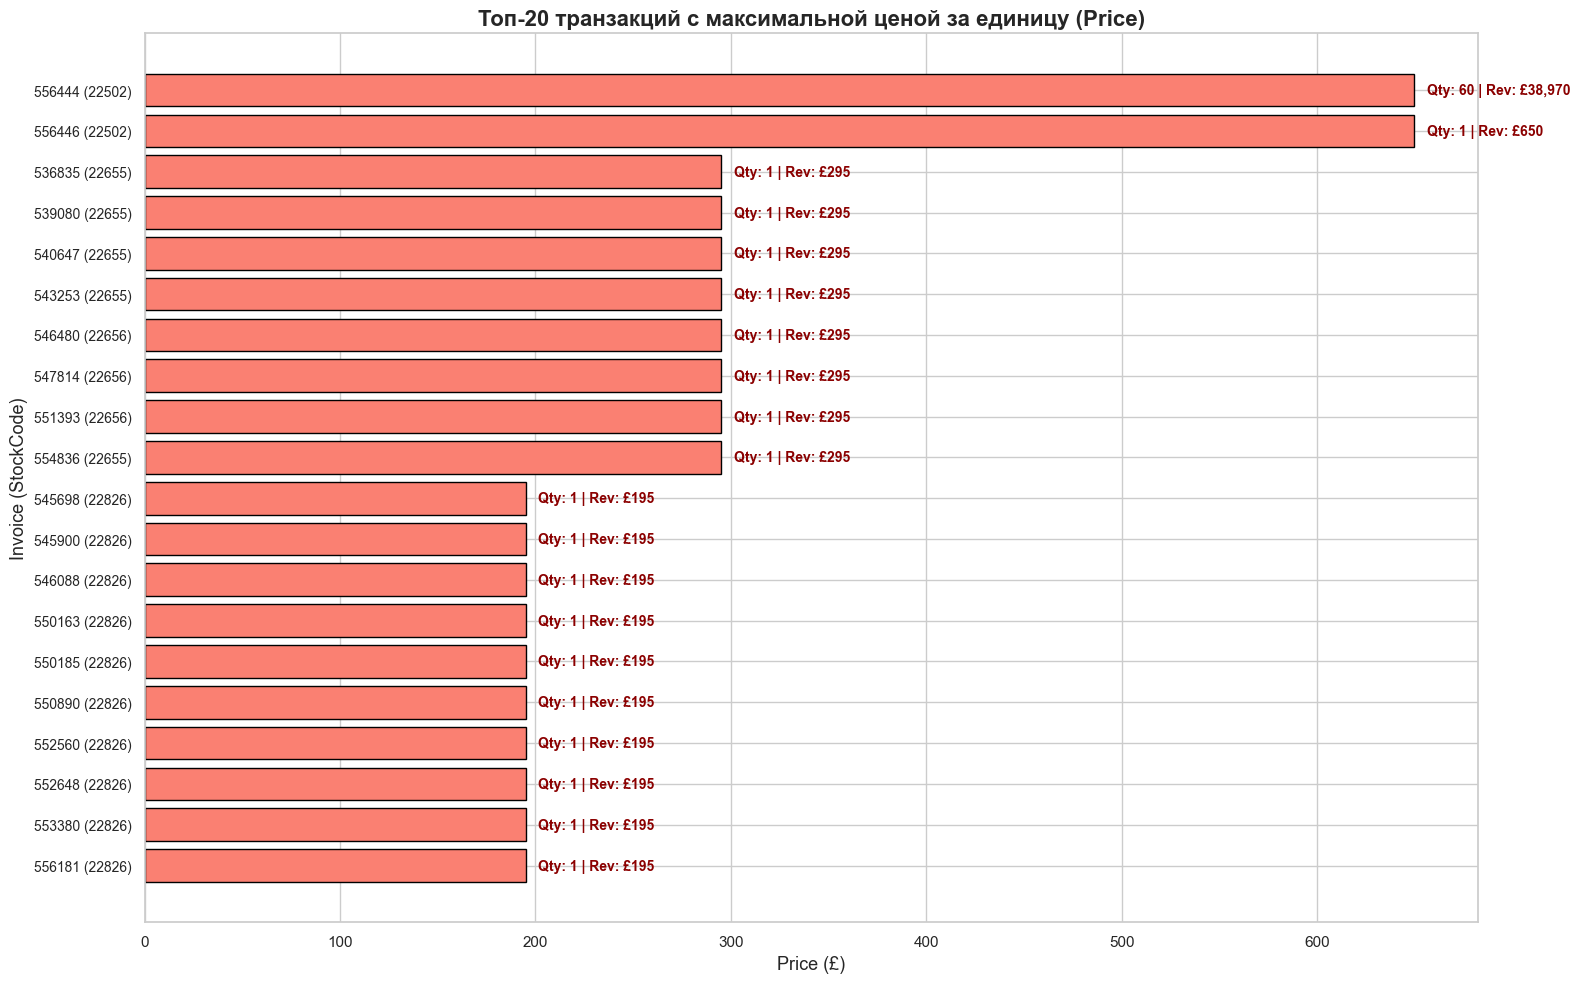

In [41]:
# ==========================================
# 4. Топ-20 строк с максимальной ценой (Price)
# ==========================================
top_20_price = df_clean.nlargest(20, 'Price')[
    ['Invoice', 'StockCode', 'Quantity', 'Price', 'Revenue']
].reset_index(drop=True)

fig, ax = plt.subplots(figsize=(16, 10))

# Используем Invoice как метку, но можно добавить StockCode для информативности
y_labels = [f"{row.Invoice} ({row.StockCode})" for _, row in top_20_price.iterrows()]

bars = ax.barh(y_labels, top_20_price['Price'], color='salmon', edgecolor='black')

ax.set_title('Топ-20 транзакций с максимальной ценой за единицу (Price)', fontsize=16, fontweight='bold')
ax.set_xlabel('Price (£)', fontsize=13)
ax.set_ylabel('Invoice (StockCode)', fontsize=13)
ax.invert_yaxis() # Чтобы самая высокая цена была сверху

# Добавляем текстовые аннотации к каждому бару
max_price = top_20_price['Price'].max()
for bar, row in zip(bars, top_20_price.itertuples()):
    # Формируем подпись: Кол-во и Общая выручка
    annotation = f"Qty: {row.Quantity:,} | Rev: £{row.Revenue:,.0f}"
    ax.text(bar.get_width() + max_price * 0.01, 
            bar.get_y() + bar.get_height() / 2,
            annotation,
            va='center', fontsize=10, fontweight='bold', color='darkred')

# Улучшаем читаемость меток по оси Y
plt.yticks(fontsize=10)
plt.tight_layout()
plt.show()

### 1.3 Сводный вывод по предварительной работе с данными

1. Данные очищены: выделен временной диапазон; удалены полные дубликаты, служебные коды, отмены, отрицательные и нулевые значения; пропуски в Description заполнены по StockCode, в Customer ID пропуски оставлены; добавлен столбец с рассчитанной выручкой Revenue; в выборке только реальные товарные позиции.
2. Выбросы по количеству: 5.15% строк с Quantity > 28 (по IQR), но они дают 36.6% выручки - это крупные заказы, их нужно сохранить и выделить в отдельный сегмент. Оптовые заказы с Quantity > 100 помечены флагом is_bulk_order.
3. Выбросы по цене: 78 SKU с высокой вариацией цены - в основном из‑за разных фасовок, акций или ошибок ввода; удалять не нужно, пометили их флагом price_var_flag для ручной проверки при интерпретации ABC.
4. ABC/XYZ можно считать на этих данных: очистка и анализ выбросов завершены, искажения устранены, оставшиеся аномалии - это бизнес‑реальность, а не ошибки.

### 1.4 Продажами считаются строки транзакций из финального датасета df_clean, удовлетворяющие одновременно трём условиям:

1. Позитивное количество товара: Quantity > 0. Отрицательные и нулевые значения удалены.
   
2. Реальная товарная позиция: исключены служебные коды, отмены и полные дубликаты. В агрегации участвуют только валидные SKU с заполненным описанием (или восстановленным по коду).

3. Факт реализации: в расчёт попадает каждая строка с продажей, включая крупные оптовые заказы (is_bulk_order = True). Несмотря на то, что такие заказы являются выбросами по объёму (5,15% строк дают 36,6% выручки), они сохранены, так как отражают реальную бизнес‑практику, а не ошибку ввода.

## Этап 2. Базовая картина бизнеса

До сегментации товара необходимо показать, что представляет собой магазин в выбранном периоде. Рассчитайте количество уникальных SKU, заказов и покупателей, общее число проданных единиц и выручку. Добавьте динамику заказов и выручки по месяцам. Средний чек рассчитывайте на уровне заказа, а не строки товара.

In [42]:
# Основные метрики
print(f"Уникальные SKU: {df_clean['StockCode'].nunique():,}")
print(f"Уникальные заказы: {df_clean['Invoice'].nunique():,}")
print(f"Уникальные покупатели: {df_clean['Customer ID'].nunique():,}")
print(f"Продано единиц: {df_clean['Quantity'].sum():,}")
print(f"Выручка: {round(df_clean['Revenue'].sum(), 2):,}")

# Средний чек на уровне заказа
order_revenue = df_clean.groupby('Invoice')['Revenue'].sum()
print(f"Средний чек на заказ: {round(order_revenue.mean(), 2):,}")

Уникальные SKU: 3,905
Уникальные заказы: 18,957
Уникальные покупатели: 4,293
Продано единиц: 5,248,740
Выручка: 9,632,728.4
Средний чек на заказ: 508.14


Выводы: 

Широкий ассортимент: 3 905 уникальных SKU - это довольно большая товарная матрица. Для ABC‑анализа это как раз нужный масштаб: можно будет выделить ядро ассортимента (A‑группа), которое даёт основную выручку.

Объём продаж: 5,25 млн единиц при выручке 9,63 млн - средняя цена единицы товара получается примерно 1,83 (9 632 728,4 / 5 248 740). Это намекает на много недорогих позиций.

Средний чек 508,14 - довольно устойчивый показатель. При этом он не очень высокий, значит, рост выручки скорее идёт за счёт количества заказов и конверсии, а не за счёт «допродаж» в одном чеке.

4 293 покупателя на 18 957 заказов - значит, у многих клиентов несколько покупок (в среднем около 4,4 заказа на покупателя). Это хороший сигнал для XYZ‑анализа: часть клиентской базы лояльна, и спрос по ряду товаров может быть стабильным (Y/Z‑группа).

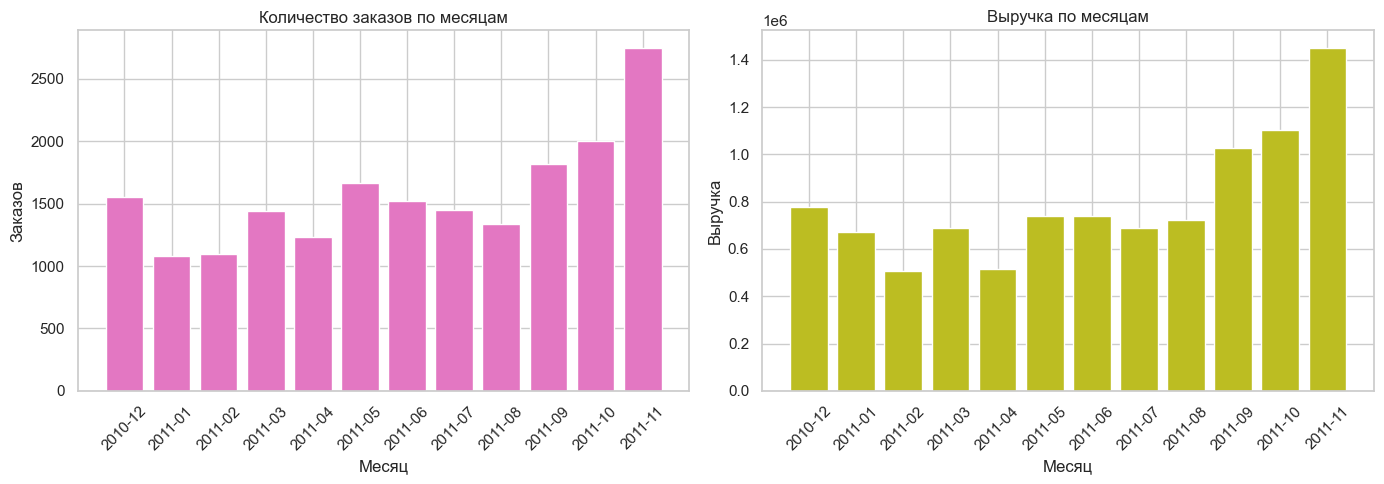

In [43]:
# Динамика заказов и выручки по месяцам
monthly = df_clean.groupby('Month').agg(
    Заказов=('Invoice', 'nunique'),
    Выручка=('Revenue', 'sum')
).round(2)

# Визуализируем

fig, axs = plt.subplots(1, 2, figsize=(14, 5))

# График 1: Заказы по месяцам
axs[0].bar(monthly.index.astype(str), monthly['Заказов'], color='#e377c2')
axs[0].set_title('Количество заказов по месяцам')
axs[0].set_xlabel('Месяц')
axs[0].set_ylabel('Заказов')
axs[0].tick_params(axis='x', rotation=45)

# График 2: Выручка по месяцам
axs[1].bar(monthly.index.astype(str), monthly['Выручка'], color='#bcbd22')
axs[1].set_title('Выручка по месяцам')
axs[1].set_xlabel('Месяц')
axs[1].set_ylabel('Выручка')
axs[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

Выводы по динамике:

- Устойчивый рост к концу периода: с декабря 2010 по ноябрь 2011 выручка и количество заказов стабильно растут, особенно заметно с сентября по ноябрь. Ноябрь — абсолютный пик: 2 751 заказ и 1,45 млн выручки.

- Сезонный всплеск в конце года: ноябрь и декабрь (если бы был полный декабрь) - классический сезонный пик. Это важно учесть при ABC/XYZ: товары, которые хорошо продаются в ноябре, могут иметь нестабильный спрос в остальные месяцы (то есть попасть в группу Z по стабильности).

- Относительно ровная середина года: с января по август показатели колеблются в схожем диапазоне, без резких провалов. Это говорит о стабильной базе спроса.

После этого проверьте, насколько выручка концентрирована на небольшой части ассортимента. Здесь полезно посмотреть распределение выручки по товарам, долю товаров с очень небольшими продажами и несколько крупнейших SKU.

In [44]:
# Считаем выручку по SKU
sku_rev = (
    df_clean.groupby('StockCode')['Revenue']
    .sum()
    .sort_values(ascending=False)
    .reset_index()
)

total_revenue = sku_rev['Revenue'].sum()

# Накопительная доля выручки
sku_rev['CumRevenue'] = sku_rev['Revenue'].cumsum() / total_revenue

# Доля топ‑10, топ‑20, топ‑50 SKU в выручке
top_n = [10, 20, 50]
for n in top_n:
    share = sku_rev.head(n)['Revenue'].sum() / total_revenue
    print(f"Топ-{n} SKU дают {share:.3%} выручки")

# «Длинный хвост»: доля SKU с очень низкой выручкой
# Порог: менее 0.1% от общей выручки на один SKU
threshold = 0.001
tail_skus = sku_rev[sku_rev['Revenue'] / total_revenue < threshold]

print(f"\nSKU с выручкой < {threshold:.1%}: {len(tail_skus)} шт. ({len(tail_skus)/len(sku_rev)*100:.1f}% ассортимента)")
print(f"Их суммарный вклад в выручку: {tail_skus['Revenue'].sum()/total_revenue:.3%}")

Топ-10 SKU дают 8.483% выручки
Топ-20 SKU дают 12.466% выручки
Топ-50 SKU дают 20.936% выручки

SKU с выручкой < 0.1%: 3682 шт. (94.3% ассортимента)
Их суммарный вклад в выручку: 51.864%


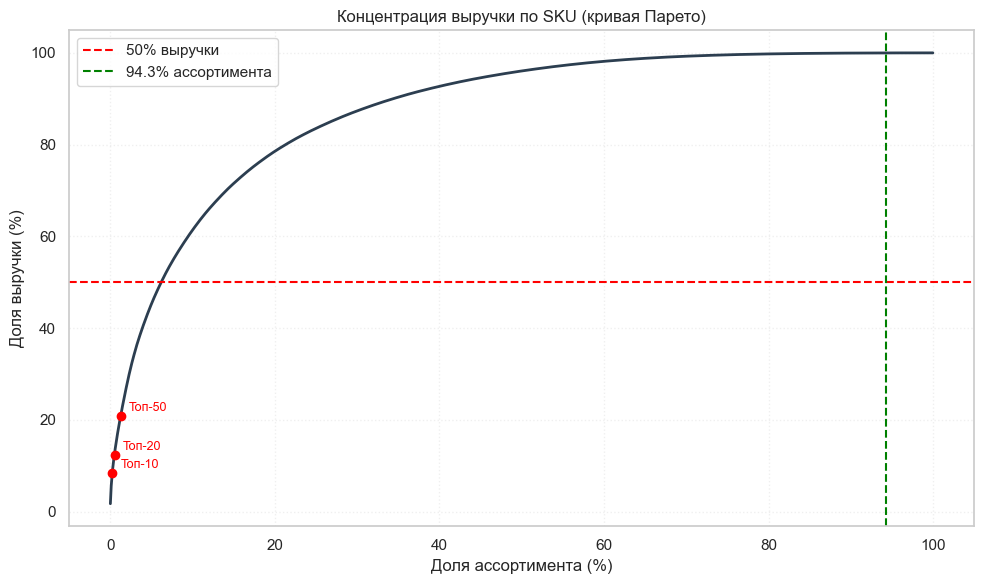

In [45]:
# Визуализация
# Точки для маркеров
markers = [
    (10/len(sku_rev)*100, sku_rev.head(10)['Revenue'].sum()/total_revenue*100, 'Топ-10'),
    (20/len(sku_rev)*100, sku_rev.head(20)['Revenue'].sum()/total_revenue*100, 'Топ-20'),
    (50/len(sku_rev)*100, sku_rev.head(50)['Revenue'].sum()/total_revenue*100, 'Топ-50'),
]

plt.figure(figsize=(10, 6))
plt.plot(
    sku_rev.index / len(sku_rev) * 100,
    sku_rev['CumRevenue'] * 100,
    color='#2c3e50', linewidth=2
)

# Рисуем точные маркеры
for x, y, label in markers:
    plt.scatter(x, y, color='red', zorder=5)
    plt.text(x+1, y+1, label, color='red', fontsize=9)

plt.axhline(50, color='red', linestyle='--', label='50% выручки')
plt.axvline(94.3, color='green', linestyle='--', label='94.3% ассортимента')
plt.xlabel('Доля ассортимента (%)')
plt.ylabel('Доля выручки (%)')
plt.title('Концентрация выручки по SKU (кривая Парето)')
plt.legend()
plt.grid(True, linestyle=':', alpha=0.3)
plt.tight_layout()
plt.show()

Выводы:

- Выручка по SKU распределена неравномерно.
  
- Топ-10 товаров формируют 8,5% выручки, топ-20 - 12,5%, а топ-50 - 20,9%.

- При этом 94,3% ассортимента составляют SKU, каждый из которых приносит менее 0,1% общей выручки. Несмотря на небольшой индивидуальный вклад этих товаров, совокупно они формируют 51,9% выручки.

Таким образом, ассортимент имеет выраженную концентрацию в наиболее востребованных SKU, однако одновременно сохраняется значительный вклад длинного хвоста товаров: большинство SKU имеют небольшой индивидуальный вклад в выручку, однако в совокупности формируют значительную часть оборота.

Что это означает для бизнеса:

1. Бизнес не зависит критически от нескольких товаров. Топ-10 SKU дают только 8,5% выручки, а топ-50 - около 20,9%. Это хороший признак с точки зрения устойчивости: потеря одного-двух лидирующих товаров не должна обрушить значительную часть оборота.

2. При этом есть важная группа лидеров. Около 5,7% ассортимента формируют 48,1% выручки. Эти товары нельзя допускать к дефициту: для них особенно важны наличие, своевременное пополнение запасов и контроль продаж.

3. Большой ассортимент действительно работает на бизнес. 94,3% SKU имеют индивидуальный вклад менее 0,1%, но вместе дают 51,9% выручки. Значит, товары с небольшими продажами по отдельности в совокупности являются существенной частью бизнеса. Поэтому просто массово сокращать такие позиции только из-за низкой выручки на SKU было бы рискованно.

4. Бизнесу важно управлять ассортиментом по группам, а не одинаково всеми товарами. Логично разделить SKU по вкладу в выручку.

## Этап 3. ABC-анализ

ABC-анализ в этом проекте используется для оценки экономической значимости товара. Базовая метрика – выручка за выбранный период. Сначала агрегируйте выручку по StockCode, затем отсортируйте товары от максимальной выручки к минимальной, рассчитайте долю каждого SKU в общей выручке 
и накопительную долю.

В качестве стартовых границ используйте классическую схему: A – товары, которые формируют примерно первые 80% выручки; B – следующие примерно 15%; C – оставшаяся часть. Границы являются рабочим правилом, а не законом. Если вы хотите использовать другие пороги, это допустимо при кратком обосновании.

В результате покажите количество и долю SKU в категориях A, B и C, их вклад в выручку и несколько характерных товаров. Хорошая визуализация для этого этапа – кривая Парето, которая позволяет увидеть, какая часть ассортимента создает основную долю оборота.

Ключевой вывод. Категория C означает низкий вклад в выбранную метрику, а не «плохой товар». Нельзя использовать ABC как готовый список на удаление.

Изначально не будем менять классические пороги. Сначала стоит посмотреть, как эти границы фактически разделяют наш ассортимент: посчитаем, сколько именно SKU и какой процент ассортимента попадёт в A, B и C. Это позволит увидеть, насколько классические границы действительно полезны именно для нашего бизнеса.

In [46]:
# Агрегируем выручку по каждому StockCode
sku_agg = (
    df_clean
    .groupby('StockCode', as_index=False)['Revenue']
    .sum()
)

# Сортируем по убыванию выручки
sku_agg = sku_agg.sort_values(by='Revenue', ascending=False).reset_index(drop=True)

# Считаем долю каждого SKU в общей выручке (%)
total_revenue = sku_agg['Revenue'].sum()
sku_agg['Share_Revenue'] = sku_agg['Revenue'] / total_revenue * 100

# Накопительная доля выручки (%)
sku_agg['Cum_Revenue'] = sku_agg['Share_Revenue'].cumsum()

# Накопительная доля ассортимента (%)
total_skus = len(sku_agg)
sku_agg['Cum_SKU_Pct'] = (sku_agg.index + 1) / total_skus * 100

# Присвоение классических ABC‑групп (80/15/5 по выручке)
def assign_abc_classic(row):
    if row['Cum_Revenue'] < 80:
        return 'A'
    elif row['Cum_Revenue'] < 95:
        return 'B'
    else:
        return 'C'

sku_agg['ABC_Classic'] = sku_agg.apply(assign_abc_classic, axis=1)

# Сводная статистика по группам
summary = (
    sku_agg
    .groupby('ABC_Classic')
    .agg(
        Count_SKU=('StockCode', 'count'),
        Share_SKU_Pct=('Cum_SKU_Pct', 'max'),
        Revenue_Sum=('Revenue', 'sum'),
        Share_Revenue_Pct=('Revenue', lambda x: x.sum() / total_revenue * 100)
    )
    .round(2)
)

# Добавим долю SKU внутри группы (для наглядности)
summary['Share_SKU_Group'] = summary['Count_SKU'] / total_skus * 100

print(summary[['Count_SKU', 'Share_SKU_Group', 'Share_Revenue_Pct']])

             Count_SKU  Share_SKU_Group  Share_Revenue_Pct
ABC_Classic                                               
A                  832        21.306018              79.99
B                  978        25.044814              15.01
C                 2095        53.649168               5.00


Классические пороги 80/15/5 для наших данных оказались вполне адекватны и хорошо интерпретируются с точки зрения бизнеса.

1. Классическое правило ABC практически идеально ложится на наши данные: 21,3% SKU формируют 80% выручки. Это очень близко к классическому принципу Парето 20% товаров → 80% результата.

2. Группа A - ядро бизнеса: 832 SKU (21,3% ассортимента) дают 80% выручки. Это товары, которые действительно определяют финансовый результат.

Для них логично:

- особенно внимательно контролировать наличие;
- не допускать длительного дефицита;
- поддерживать достаточный запас;
- регулярно контролировать продажи;
- отдельно анализировать проблемы с поставками.

Но не «держать максимальные страховые запасы» для всех A автоматически. Страховой запас зависит ещё и от стабильности спроса - здесь как раз пригодится XYZ.

3. Группа B - значимая, но менее критичная: 978 SKU (25%) дают 15% выручки. Это уже не ядро, но вклад достаточно существенный. Здесь можно искать товары, которые способны перейти в A:

- анализировать динамику продаж;
- смотреть оборачиваемость;
- выявлять растущие SKU;
- оценивать маржинальность.

4. Группа C - вот здесь результат особенно интересный: 53,6% всего ассортимента дают только 5% выручки. Именно эту группу уже вполне корректно называть длинным хвостом. При этом важно отличать её от предыдущих 94,3% SKU с индивидуальной долей менее 0,1%.

Что это говорит бизнесу:

- Ассортимент характеризуется выраженной концентрацией выручки: около 21% SKU формируют 80% оборота. При этом более половины ассортимента (53,6%) обеспечивает только 5% выручки. Это означает, что бизнес имеет значительный длинный хвост низкооборотных товаров и одновременно существенную зависимость финансового результата от относительно небольшой группы SKU.

- Поэтому при управлении запасами основной контроль следует сосредоточить на товарах группы A, поскольку их наличие напрямую влияет на большую часть выручки. Для группы B целесообразно анализировать потенциал роста, а для группы C - оценивать экономическую целесообразность поддержания широкого ассортимента с учётом оборачиваемости, маржинальности и стабильности спроса.

In [47]:
# Примеры характерных товаров в каждой группе
# Объединим с исходными данными, чтобы получить Description
sku_desc = (
    df_clean
    .groupby('StockCode')['Description']
    .first()
    .reset_index()
)

sku_final = sku_agg.merge(sku_desc, on='StockCode', how='left')

# Примеры по 3 SKU из каждой группы
top_a = sku_final[sku_final['ABC_Classic'] == 'A'].head(3)[['StockCode', 'Description', 'Revenue', 'Share_Revenue']]
top_b = sku_final[sku_final['ABC_Classic'] == 'B'].head(3)[['StockCode', 'Description', 'Revenue', 'Share_Revenue']]
top_c = sku_final[sku_final['ABC_Classic'] == 'C'].head(3)[['StockCode', 'Description', 'Revenue', 'Share_Revenue']]

print("Примеры SKU группы A:\n", top_a)
print("\nПримеры SKU группы B:\n", top_b)
print("\nПримеры SKU группы C:\n", top_c)

Примеры SKU группы A:
   StockCode                         Description    Revenue  Share_Revenue
0     22423            REGENCY CAKESTAND 3 TIER  168162.42       1.745740
1    85123A  WHITE HANGING HEART T-LIGHT HOLDER  102236.34       1.061344
2     47566                       PARTY BUNTING   98526.75       1.022833

Примеры SKU группы B:
     StockCode                  Description  Revenue  Share_Revenue
832     21781      MA CAMPAGNE CUTLERY BOX  2661.80       0.027633
833     22224       WHITE LOVEBIRD LANTERN  2658.41       0.027598
834     22433  WATERING CAN GREEN DINOSAUR  2651.67       0.027528

Примеры SKU группы C:
      StockCode                        Description  Revenue  Share_Revenue
1810     85125  SMALL ROUND CUT GLASS CANDLESTICK   760.39       0.007894
1811     10002        INFLATABLE POLITICAL GLOBE    759.89       0.007889
1812    85170D    SET/6 PINK BIRD T-LIGHT CANDLES   759.82       0.007888


Примеры дополняют картину и подтверждают, что классическая сегментация сработала корректно:

1. Группа A «сквозные хиты»:

Три верхних товара приносят от 1% до 1,75% выручки каждый - для ассортимента из 3900 SKU это очень солидно. Это декоративные товары для дома: многоярусная подставка для торта, подсвечник в виде сердца, праздничная гирлянда. Все три - подарочные/декоративные категории, которые покупают массово и круглый год. Нет ярко выраженной сезонности, нет нишевых позиций — это и есть «ядро».

2. Группа B «середняки»:

Выручка на SKU падает в 40 раз по сравнению с группой A. Доля выручки 0,028%. Но при этом каждый товар всё ещё продаётся регулярно: коробка для столовых приборов, фонарь с птичками, лейка-динозавр. Это тоже декор и подарки, просто менее популярные. Именно здесь нужно следить за оборачиваемостью - товар продаётся, но не «летит».

3. Группа C «хвост»:

Выручка на SKU падает ещё в 3,5 раза. Доля выручки около 0,008%. Названия уже более специфичные: подсвечник из резного стекла, надувной политический глобус, набор розовых свечей-птичек. Это нишевые, редкие или разовые товары. Важно: 2 095 таких SKU вместе дают всего 5% выручки - это кандидаты на упрощённое управление: минимальный остаток или заказ под запрос.

Дальше логично посмотреть, насколько стабильно продаются товары в каждой группе — провести XYZ‑анализ.

## Этап 4. XYZ-анализ

XYZ-анализ в проекте нужен для оценки вариативности физического спроса. Для каждого StockCode сформируйте временной ряд количества проданных единиц по месяцам. Затем рассчитайте среднее месячное количество, стандартное отклонение и коэффициент вариации CV = std / mean.

В качестве базовых порогов используйте: X – CV ≤ 0,5; Y – 0,5 < CV ≤ 1; Z – CV > 1. Пороговые значения можно изменить, если вы покажете распределение CV и объясните выбранный подход.

Главная техническая часть XYZ – корректно построить полный календарь для каждого товара. Если товар не продавался в конкретном месяце, этот месяц должен присутствовать в временном ряду с нулевым значением. Если считать CV только по месяцам, где есть строки продаж, редкий товар может ошибочно выглядеть идеально стабильным.

Отдельно подумайте о товарах, которые появились ближе к концу периода, имеют очень небольшое среднее количество продаж или очевидную сезонность. Сам по себе большой CV не говорит, почему спрос меняется. Высокая вариативность может быть следствием сезонности, возраста товара или редких крупных заказов.

Минимум для зачета XYZ. У товара должен быть корректный 12-месячный ряд, нулевые месяцы должны учитываться, а результат классификации X/Y/Z – воспроизводиться из рассчитанного CV.

In [48]:
# Полный 12-месячный ряд по каждому SKU

# 1. Определяем полный набор месяцев в данных
all_months = sorted(df_clean['Month'].unique())
print(f"Месяцы в данных: {all_months}")

# 2. Агрегируем количество проданных единиц по StockCode и месяцу
monthly_units = (
    df_clean
    .groupby(['StockCode', 'Month'])['Quantity']
    .sum()
    .reset_index()
)

# 3. Создаём полный набор комбинаций StockCode × Month (каждый SKU во всех месяцах)
#    Сначала строим индекс «все SKU × все месяцы»
sku_list = df_clean['StockCode'].unique()
full_index = pd.MultiIndex.from_product(
    [sku_list, all_months],
    names=['StockCode', 'Month']
)

# 4. Переиндексируем, чтобы каждый SKU имел все месяцы (недостающие → 0)
monthly_series = (
    monthly_units
    .set_index(['StockCode', 'Month'])
    .reindex(full_index, fill_value=0)
    .reset_index()
)

# Проверяем: каждый SKU должен иметь ровно 12 месяцев
assert monthly_series.groupby('StockCode').size().nunique() == 1, "Не у всех SKU 12 месяцев!"
print(f"SKU с полным 12-месячным рядом: {monthly_series['StockCode'].nunique()}")
print(f"Всего строк: {len(monthly_series)} (должно быть {monthly_series['StockCode'].nunique()} × {len(all_months)})")

Месяцы в данных: [Period('2010-12', 'M'), Period('2011-01', 'M'), Period('2011-02', 'M'), Period('2011-03', 'M'), Period('2011-04', 'M'), Period('2011-05', 'M'), Period('2011-06', 'M'), Period('2011-07', 'M'), Period('2011-08', 'M'), Period('2011-09', 'M'), Period('2011-10', 'M'), Period('2011-11', 'M')]
SKU с полным 12-месячным рядом: 3905
Всего строк: 46860 (должно быть 3905 × 12)


In [49]:
# Расчёт среднего, стандартного отклонения и CV

# Сводная таблица: строки - SKU, столбцы - месяцы
pivot = monthly_series.pivot(index='StockCode', columns='Month', values='Quantity')

# Среднее и стандартное отклонение по строкам
xyz_stats = pd.DataFrame({
    'mean_monthly': pivot.mean(axis=1),
    'std_monthly': pivot.std(axis=1, ddof=1),  # выборочное std (n-1)
})

# Коэффициент вариации: CV = std / mean
# Защита от деления на ноль: если mean = 0, CV = NaN (товар не продавался вообще)
xyz_stats['CV'] = np.where(
    xyz_stats['mean_monthly'] > 0,
    xyz_stats['std_monthly'] / xyz_stats['mean_monthly'],
    np.nan
)

# Количество месяцев с ненулевыми продажами (для выявления «новичков»)
xyz_stats['months_active'] = (pivot > 0).sum(axis=1)

# Первый месяц продаж (для товаров, появившихся не с начала периода)
xyz_stats['first_sale_month'] = monthly_series[monthly_series['Quantity'] > 0].groupby('StockCode')['Month'].min()

Пометим флагом is_late_arrival = first_sale_month > first_month_in_data 
То есть, если первый зафиксированный sale не в декабре 2010 → newcomer (новичок).
Но это может быть:
- реально новый товар;
- старый товар, который просто впервые продавался в выбранном периоде;
- товар, который раньше был out-of-stock;
- товар, который появился в данных позднее по другой причине.

Таким образом, это будут SKU с поздним первым наблюдаемым спросом» («newcomer по данным»).

In [50]:
# Флаги для «новичков» и товаров с очень низким спросом

# Флаг: товар появился не в первый месяц (короткая история)
first_month_in_data = all_months[0]
xyz_stats['is_late_arrival'] = xyz_stats['first_sale_month'] > first_month_in_data

# Флаг: очень низкое среднее (меньше 2 единиц в месяц)
xyz_stats['is_low_volume'] = xyz_stats['mean_monthly'] < 2

# Флаг: товар продавался только в 1-2 месяцах (спорадический)
xyz_stats['is_sparse'] = xyz_stats['months_active'] <= 2

In [51]:
# Присвоение групп X / Y / Z по классическим порогам

def assign_xyz(cv):
    if pd.isna(cv):
        return 'Z'  # не продавался вообще → Z
    if cv <= 0.5:
        return 'X'
    elif cv <= 1.0:
        return 'Y'
    else:
        return 'Z'

xyz_stats['XYZ'] = xyz_stats['CV'].apply(assign_xyz)

In [52]:
# Сводная статистика по группам

xyz_summary = (
    xyz_stats
    .groupby('XYZ')
    .agg(
        Count_SKU=('mean_monthly', 'count'),
        Mean_Monthly=('mean_monthly', 'mean'),
        Median_CV=('CV', 'median'),
        Late_Arrivals=('is_late_arrival', 'sum'),
        Low_Volume=('is_low_volume', 'sum'),
        Sparse=('is_sparse', 'sum'),
    )
    .round(2)
)
xyz_summary['Share_SKU_Pct'] = xyz_summary['Count_SKU'] / len(xyz_stats) * 100

print(xyz_summary)

     Count_SKU  Mean_Monthly  Median_CV  Late_Arrivals  Low_Volume  Sparse  \
XYZ                                                                          
X          322        372.45       0.42              1           0       0   
Y         1062        158.29       0.74            100          21       0   
Z         2521         59.25       1.70           1025         664     527   

     Share_SKU_Pct  
XYZ                 
X         8.245839  
Y        27.195903  
Z        64.558259  


Группа X - «локомотивы» (322 SKU): 
Всего 8% ассортимента, но продаются стабильно и много: в среднем 372 штуки в месяц, медианный CV 0,42. Почти нет «новичков» (всего 1) и ни одного низкообъёмного или спорадического товара. Это товары, которые продаются каждый месяц примерно одинаково - идеальные кандидаты на автоматическое пополнение запаса с минимальным страховым запасом.

Группа Y - «предсказуемая нестабильность» (1 062 SKU):
Чуть больше четверти ассортимента, средний объём 158 шт./мес. - тоже неплохо. Медианный CV 0,74 - колебания есть, но в разумных пределах. 100 товаров появились не с первого месяца - это новый ассортимент, который ещё набирает обороты. Здесь скорее всего есть сезонность (продажи растут к праздникам) или трендовые товары (мода пришла и ушла). Для этих товаров нужен страховой запас, рассчитанный с учётом сезонности.

Группа Z - вот тут самое интересное (2 521 SKU):
Почти две трети ассортимента - это группа Z. Но если копнуть глубже, оказывается, что высокий CV у большинства из них - не признак хаотичного спроса:

- 1 025 SKU (40,6% группы Z) - это товары, которые появились позже первого месяца. У них просто короткая история продаж: например, товар завезли в октябре, и он продавался 3 месяца. CV высокий не потому, что спрос «прыгает», а потому что период наблюдения слишком короткий. Эти товары могут быть абсолютно стабильными - просто мы пока не видим этого.
- 664 SKU (26,3%) - низкий объём (в среднем < 2 шт./мес.). При таких объёмах CV математически всегда будет высоким: одна продажа в один месяц и ноль в другой - и CV улетает за 1,0. Это не «нестабильность», а редкие продажи.
- 527 SKU (20,9%) - спорадические: продажи в 1–2 месяцах из 12. Это не товары с нестабильным спросом, это товары, которых по сути нет в регулярном спросе.

Если вычесть эти три категории, «настоящих Z» (товаров с полным 12‑месячным рядом, нормальным объёмом и реально хаотичным спросом) останется примерно 307 SKU - около 8% ассортимента. Это совсем другой масштаб.

Что это значит для управления запасами:

Z‑группа не однородна. Нельзя применять к ней единое правило «заказ под запрос». Нужно как минимум разделить:

- Z‑новички (1 025 SKU) - дать им доработать полный год и пересчитать CV заново. Возможно, многие перейдут в X или Y.
- Z‑редкие (664 SKU) - заказ под запрос или минимальный остаток, но с пометкой «не ошибка спроса, а специфика товара».
- Z‑спорадические (527 SKU) - кандидаты на вывод из ассортимента, если они не дают выручку.
- Z‑настоящие (~307 SKU) - те, у которых спрос реально непредсказуем при нормальном объёме. Вот для них - заказ под запрос или управление через страховой запас с повышенным коэффициентом.
  
Сезонность маскируется под Z. Товар, который продаётся только в декабре, получит CV > 1 и попадёт в Z. Но это не хаос - это предсказуемая сезонность. Для таких товаров нужен не «заказ под запрос», а плановое пополнение перед сезоном. Чтобы их выделить, можно посмотреть, в какие месяцы они продавались: если продажи сконцентрированы в 1–2 соседних месяцах - это сезонный паттерн.

AX‑товары - золото. Из 322 SKU группы X большинство наверняка входят и в группу A по выручке (потому что средний объём 372 шт./мес. — это много). Это товары, которые и зарабатывают, и продаются стабильно — идеальный кандидат на автоматическое пополнение без ручного контроля.

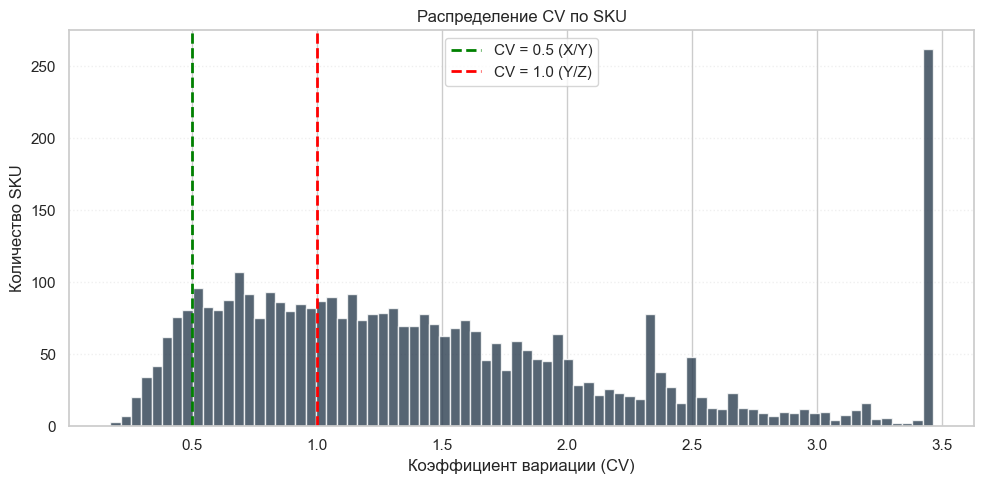

In [53]:
# Распределение CV (для проверки порогов)

# Гистограмма CV (без NaN и без экстремальных выбросов для наглядности)
cv_valid = xyz_stats['CV'].dropna()
cv_trimmed = cv_valid[cv_valid < 5]  # обрезаем хвост для читаемости

plt.figure(figsize=(10, 5))
plt.hist(cv_trimmed, bins=80, color='#2c3e50', edgecolor='white', alpha=0.8)
plt.axvline(0.5, color='green', linestyle='--', linewidth=2, label='CV = 0.5 (X/Y)')
plt.axvline(1.0, color='red', linestyle='--', linewidth=2, label='CV = 1.0 (Y/Z)')
plt.xlabel('Коэффициент вариации (CV)')
plt.ylabel('Количество SKU')
plt.title('Распределение CV по SKU')
plt.legend()
plt.grid(True, axis='y', linestyle=':', alpha=0.3)
plt.tight_layout()
plt.show()

Выводы:

- Классические пороги (0,5 и 1,0) попадают в естественные «перегибы» кривой CV, но правый хвост сильно искажён.

- Пик плотности приходится на диапазон CV 0,5–1,2 - это «тело» распределения, где сосредоточены товары с умеренной и высокой вариативностью. Именно здесь проходит граница между Y и Z.

- Длинный правый хвост (CV > 2,0) - это те самые 527 спорадических SKU и товары с очень низким средним объёмом. Один-два месяца продаж и много нулей математически дают огромный CV, и на графике это выглядит как резкий всплеск в районе 3,5.

- Пороги работают, но не для всей массы: зелёная линия (CV = 0,5) чётко отделяет стабильную группу X, а красная (CV = 1,0) - границу, где начинается «шум» из редких и новых товаров.

- Базовые пороги оставляем, но интерпретируем Z‑группу дифференцированно.

In [54]:
# Примеры товаров с разным профилем

# Объединяем с описанием
sku_desc = df_clean.groupby('StockCode')['Description'].first()

# Примеры для каждой группы
for group in ['X', 'Y', 'Z']:
    examples = xyz_stats[xyz_stats['XYZ'] == group].copy()
    examples['Description'] = examples.index.map(sku_desc)
    print(f"\n=== Группа {group} (примеры) ===")
    print(examples[['Description', 'mean_monthly', 'std_monthly', 'CV', 'months_active', 'is_late_arrival']].head(5).round(2))

# Отдельно: товары с высоким CV, но низкой вариативностью (мало активных месяцев)
suspicious = xyz_stats[
    (xyz_stats['XYZ'] == 'Z') &
    (xyz_stats['is_sparse'] == True)
].copy()
suspicious['Description'] = suspicious.index.map(sku_desc)
print(f"\n=== Z-товары, продававшиеся ≤2 месяцев (спорадические): {len(suspicious)} SKU ===")
print(suspicious[['Description', 'mean_monthly', 'CV', 'months_active']].head(10).round(2))


=== Группа X (примеры) ===
                       Description  mean_monthly  std_monthly    CV  \
StockCode                                                             
15056bl    EDWARDIAN PARASOL BLACK          6.83         3.19  0.47   
16161P          WRAP ENGLISH ROSE         587.58       290.04  0.49   
17084N       FAIRY DREAMS INCENSE         102.83        47.91  0.47   
20665         RED RETROSPOT PURSE          37.92        16.25  0.43   
20674          GREEN POLKADOT BOWL        127.08        49.51  0.39   

           months_active  is_late_arrival  
StockCode                                  
15056bl               12            False  
16161P                12            False  
17084N                12            False  
20665                 12            False  
20674                 12            False  

=== Группа Y (примеры) ===
                            Description  mean_monthly  std_monthly    CV  \
StockCode                                                     

Примеры SKU из групп X, Y и Z не просто подтверждают корректность расчётов - они раскрывают реальную природу спроса по сегментам.

- Группа X: «Стабильное ядро» (CV ≈ 0.4)
Примеры: 16161P WRAP ENGLISH ROSE (587 шт./мес), 20674 GREEN POLKADOT BOWL (127 шт./мес).
CV: 0.39–0.49 - очень низкая вариативность. У всех примеров months_active = 12. Это не «удачные» месяцы, а устойчивый спрос весь год. Это «повторяемые» подарки и декор (сумки-обёртки, посуда). Покупатель знает, что это такое, и берёт регулярно (например, для подарков на дни рождения). Для таких SKU идеально работает автоматическое пополнение с минимальным страховым запасом. Прогноз по скользящему среднему будет точным.

- Группа Y: «Умеренная волатильность» (CV ≈ 0.7–1.0)
Примеры: 15036 ASSORTED COLOURS SILK FAN (1980 шт./мес, CV=0.72), 10135 COLOURING PENCILS (CV=0.98).
Высокий объём при умеренной нестабильности: например, 15036 - очень популярный товар (почти 2000 шт./мес), но его CV = 0.72. Это значит, что спрос «дышит»: в одни месяцы берут по 3000, в другие - по 1000. Товар 11001 имеет CV ровно 1.00 - он балансирует на границе Y/Z. В следующем периоде он может уйти в Z из-за одного «провального» месяца. Здесь нельзя полагаться на простое среднее. Для группы Y нужно применять коэффициент сезонности или модели экспоненциального сглаживания. Страховой запас должен быть выше, чем у X, но не экстремальным.


- Группа Z: «Шум и специфика» (CV > 1.0)
Здесь примеры особенно показательны, так как демонстрируют разные причины попадания в Z:

1. «Редкие, но реальные» (CV 1.3–1.7)
Пример: 10002 INFLATABLE POLITICAL GLOBE (среднее 71.67, CV=1.66, активен 5 месяцев).
Это товар с нишевой аудиторией. Он продаётся не каждый месяц, но когда продаётся - партиями. Высокий CV здесь - следствие низкой частоты, а не хаоса.

2. «Спорадические» (CV > 2.5)
Пример: 10123C HEARTS WRAPPING TAPE (среднее 0.42, CV=2.79, активен 2 месяца).
Это классический «шум». Товар либо тестировали, либо он попал в ассортимент случайно. Математически CV здесь всегда будет огромным: если в году было 2 продажи, а в остальные месяцы 0, то стандартное отклонение будет кратно превышать среднее.

3. «Новички»
Пример: 10080 GROOVY CACTUS INFLATABLE (is_late_arrival = True).
Товар появился поздно, поэтому у него короткая история. Его высокий CV - это артефакт периода наблюдения, а не характеристика спроса.

Критический вывод: нельзя управлять Z‑группой единым правилом. Z — это не непредсказуемый спрос, а высокая вариативность спроса. Причину этой вариативности нужно определить отдельно. Примеры из блока «Z‑товары, продававшиеся ≤2 месяцев» (SKU 16043, 16202A и др.) показывают системную проблему: в группу Z сваливаются принципиально разные товары.

## Этап 4.1 Дифференцируем XYZ по признаку опта

Учитывая, что крупные оптовые заказы (помеченные нами ранее флагом is_bulk_order) сильно влияют на вариативность, сформируем два набора правил:

1. Базовый XYZ - на всех продажах (чтобы видеть общую картину и управлять общим остатком).
2. Розничный XYZ - только на строках is_bulk_order = False. Это покажет реальную стабильность спроса обычных покупателей.

Оптовые заказы будем учитывать отдельно как "редкие крупные всплески".

Пересчитаем CV с учётом опта - проверим влияние оптовых заказов на вариативность.

In [55]:
# ── 1. Полный набор месяцев ──
all_months = sorted(df_clean['Month'].unique())

# ── 2. Месячные суммы: все продажи ──
monthly_all = (
    df_clean
    .groupby(['StockCode', 'Month'])['Quantity']
    .sum()
    .reset_index(name='qty_all')
)

# ── 3. Месячные суммы: только розница (без опта) ──
monthly_retail = (
    df_clean[df_clean['is_bulk_order'] == False]
    .groupby(['StockCode', 'Month'])['Quantity']
    .sum()
    .reset_index(name='qty_retail')
)

# ── 4. Объединяем и заполняем нулями отсутствующие месяцы ──
full_index = pd.MultiIndex.from_product(
    [df_clean['StockCode'].unique(), all_months],
    names=['StockCode', 'Month']
)

monthly = (
    monthly_all
    .set_index(['StockCode', 'Month'])
    .reindex(full_index, fill_value=0)
    .reset_index()
    .merge(monthly_retail, on=['StockCode', 'Month'], how='left')
    .fillna({'qty_retail': 0})
)

# ── 5. Считаем статистики по каждому SKU ──
def safe_cv(x):
    m = x.mean()
    return x.std(ddof=1) / m if m > 0 else np.nan

xyz_metrics = monthly.groupby('StockCode').agg(
    mean_all=('qty_all', 'mean'),
    mean_retail=('qty_retail', 'mean'),
    cv_all=('qty_all', safe_cv),
    cv_retail=('qty_retail', safe_cv),
    months_active_all=('qty_all', lambda x: (x > 0).sum()),
    months_active_retail=('qty_retail', lambda x: (x > 0).sum()),
).reset_index()

# ── 6. Присваиваем XYZ-группы ──
def assign_xyz(cv):
    if pd.isna(cv):
        return 'Z'
    if cv <= 0.5:
        return 'X'
    elif cv <= 1.0:
        return 'Y'
    else:
        return 'Z'

xyz_metrics['XYZ_all'] = xyz_metrics['cv_all'].apply(assign_xyz)
xyz_metrics['XYZ_retail'] = xyz_metrics['cv_retail'].apply(assign_xyz)

# ── 7. СВОДКА 1: Распределение по XYZ_all ──
print("=== Распределение SKU по XYZ (все продажи) ===")
summary_all = xyz_metrics['XYZ_all'].value_counts().reindex(['X', 'Y', 'Z'])
summary_all_pct = summary_all / len(xyz_metrics) * 100
for g in ['X', 'Y', 'Z']:
    print(f"  {g}: {summary_all[g]} SKU ({summary_all_pct[g]:.1f}%)")

# ── 8. СВОДКА 2: Распределение по XYZ_retail ──
print("\n=== Распределение SKU по XYZ (только розница) ===")
summary_retail = xyz_metrics['XYZ_retail'].value_counts().reindex(['X', 'Y', 'Z'])
summary_retail_pct = summary_retail / len(xyz_metrics) * 100
for g in ['X', 'Y', 'Z']:
    print(f"  {g}: {summary_retail[g]} SKU ({summary_retail_pct[g]:.1f}%)")

# ── 9. СВОДКА 3: Сколько SKU сменили группу ──
changed = xyz_metrics[xyz_metrics['XYZ_all'] != xyz_metrics['XYZ_retail']]
print(f"\n=== SKU, у которых группа изменилась (все vs розница): {len(changed)} ===")

# Детализация переходов
transitions = changed.groupby(['XYZ_all', 'XYZ_retail']).size()
for (a, r), count in transitions.items():
    print(f"  {a} → {r}: {count} SKU")

# ── 10. СВОДКА 4: Топ-5 SKU с максимальной разницей CV ──
xyz_metrics['cv_diff'] = xyz_metrics['cv_all'] - xyz_metrics['cv_retail']
top5_diff = xyz_metrics.nlargest(5, 'cv_diff')[['StockCode', 'mean_all', 'mean_retail', 'cv_all', 'cv_retail', 'cv_diff', 'XYZ_all', 'XYZ_retail']]

# Добавляем описание
sku_desc = df_clean.groupby('StockCode')['Description'].first()
top5_diff['Description'] = top5_diff['StockCode'].map(sku_desc)

print("\n=== Топ-5 SKU с максимальной разницей CV (опт «ломает» стабильность) ===")
print(top5_diff[['StockCode', 'Description', 'cv_all', 'cv_retail', 'cv_diff', 'XYZ_all', 'XYZ_retail']].to_string(index=False))

=== Распределение SKU по XYZ (все продажи) ===
  X: 322 SKU (8.2%)
  Y: 1062 SKU (27.2%)
  Z: 2521 SKU (64.6%)

=== Распределение SKU по XYZ (только розница) ===
  X: 464 SKU (11.9%)
  Y: 1058 SKU (27.1%)
  Z: 2383 SKU (61.0%)

=== SKU, у которых группа изменилась (все vs розница): 276 ===
  X → Y: 4 SKU
  Y → X: 124 SKU
  Y → Z: 5 SKU
  Z → X: 22 SKU
  Z → Y: 121 SKU

=== Топ-5 SKU с максимальной разницей CV (опт «ломает» стабильность) ===
StockCode                        Description   cv_all  cv_retail  cv_diff XYZ_all XYZ_retail
    23166     MEDIUM CERAMIC TOP STORAGE JAR 3.289072   0.985436 2.303636       Z          Y
   72803A  ROSE SCENT CANDLE JEWELLED DRAWER 2.661175   0.665220 1.995954       Z          Y
    22102      MIRROR MOSAIC T-LIGHT HOLDER  3.185501   1.200992 1.984509       Z          Z
    22106      MIRROR MOSAIC HURRICANE LAMP  2.479388   0.517617 1.961772       Z          Y
    22105 MIRROR MOSAIC GOBLET CANDLE HOLDER 2.938895   1.001848 1.937047       Z         

Выводы:

- Опт реально "ломает" стабильность, но не тотально - он сдвигает группу лишь у 276 SKU из ~3900 (то есть у ~7 %). При этом розница "вытягивает" часть товаров в более стабильные группы: например, 124 SKU из Y стали X, а 121 SKU из Z стали Y.

- Следовательно, опт - это не шум, а отдельный режим спроса. Для 276 SKU он является главным драйвером высокой вариативности. Но для остальных 93% товаров розничный спрос уже даёт достаточно стабильную картину, чтобы применять типовые правила.

- Поэтому не нужно менять пороги XYZ - нужно разделить логику управления: отдельно для розницы (база) и отдельно для опта (пул/спецзаказ).

## Этап 5. Объединенная матрица ABC/XYZ

Соедините результаты двух анализов по StockCode. Каждый товар должен получить одну из девяти комбинаций: AX, AY, AZ, BX, BY, BZ, CX, CY или CZ. После этого посмотрите на матрицу не только по числу товаров, но и по бизнес-метрикам.

Для каждой группы рассчитайте количество SKU, долю ассортимента, выручку и ее долю, количество проданных единиц и количество заказов. 

По возможности добавьте число покупателей, количество активных месяцев и среднюю цену. Эти дополнительные показатели понадобятся при переходе от классификации к реальному решению.

In [56]:
# ── 1. Подготовка ABC (из sku_agg) ──
abc = sku_agg[['StockCode', 'ABC_Classic', 'Revenue']].rename(
    columns={'ABC_Classic': 'ABC', 'Revenue': 'SKU_Revenue_ABC'}
)

# ── 2. Подготовка XYZ (из xyz_stats) ─
xyz = xyz_stats[['XYZ', 'mean_monthly', 'months_active', 'CV']].rename(
    columns={'XYZ': 'XYZ', 'mean_monthly': 'Mean_Monthly', 'months_active': 'Months_Active'}
)

# ── 3. Объединение по StockCode ──
matrix = abc.merge(xyz, left_on='StockCode', right_index=True, how='inner')
matrix['ABC_XYZ'] = matrix['ABC'] + matrix['XYZ']

# ── 4. Привязываем классификацию ABC/XYZ к каждой строке транзакции ──
# Это нужно, чтобы Orders и Customers считались по уникальным значениям
# внутри ячейки, а не суммировались по SKU (что давало двойной счёт).
df_with_class = df_clean.merge(
    matrix[['StockCode', 'ABC', 'XYZ', 'ABC_XYZ']],
    on='StockCode', how='inner'
)

# ── 5. Сводная матрица по 9 ячейкам ─
# Orders и Customers — через nunique() по исходным строкам (корректно)
# Revenue, Quantity_Sold — через sum()
# Avg_Price, Months_Active — через mean() на уровне SKU внутри ячейки

# Базовые агрегаты по транзакциям
trans_agg = df_with_class.groupby(['ABC', 'XYZ']).agg(
    SKU_Count=('StockCode', 'nunique'),
    Revenue=('Revenue', 'sum'),
    Quantity_Sold=('Quantity', 'sum'),
    Orders=('Invoice', 'nunique'),          # ← исправлено: nunique по транзакциям
    Customers=('Customer ID', 'nunique'),   # ← исправлено: nunique по транзакциям
    Avg_Price=('Price', 'mean'),
).reset_index()

# Months_Active — среднее по SKU внутри ячейки (берём из matrix)
months_agg = matrix.groupby(['ABC', 'XYZ'])['Months_Active'].mean().reset_index()
months_agg.columns = ['ABC', 'XYZ', 'Months_Active_Avg']

# Объединяем
result = trans_agg.merge(months_agg, on=['ABC', 'XYZ'], how='left')

# ── 6. Доли ──
total_skus = result['SKU_Count'].sum()
total_revenue = result['Revenue'].sum()
total_qty = result['Quantity_Sold'].sum()
result['SKU_Share_Pct'] = (result['SKU_Count'] / total_skus * 100).round(2)
result['Revenue_Share_Pct'] = (result['Revenue'] / total_revenue * 100).round(2)

# ── 7. Комбинированный код и сортировка ──
result['ABC_XYZ'] = result['ABC'] + result['XYZ']
result = result.sort_values(['ABC', 'XYZ'])

# Упорядочиваем колонки
cols = ['ABC_XYZ', 'SKU_Count', 'SKU_Share_Pct', 'Revenue', 'Revenue_Share_Pct',
        'Quantity_Sold', 'Orders', 'Customers', 'Months_Active_Avg', 'Avg_Price']
result = result[cols]

# Округляем
for c in ['Revenue', 'Avg_Price', 'Months_Active_Avg']:
    result[c] = result[c].round(0)

result

,ABC_XYZ,SKU_Count,SKU_Share_Pct,Revenue,Revenue_Share_Pct,Quantity_Sold,Orders,Customers,Months_Active_Avg,Avg_Price
0,AX,208,5.33,2302544.0,23.90,1271716,15125,3934,12.0,3.0
1,AY,327,8.37,3214699.0,33.37,1404524,16379,4064,11.0,4.0
2,AZ,297,7.61,2187862.0,22.71,887871,13689,3765,8.0,4.0
3,BX,97,2.48,155132.0,1.61,153839,6369,2296,12.0,2.0
4,BY,361,9.24,538729.0,5.59,472860,11323,3467,12.0,2.0
5,BZ,520,13.32,752035.0,7.81,576932,11378,3529,8.0,3.0
6,CX,17,0.44,8244.0,0.09,13591,1062,541,12.0,1.0
7,CY,374,9.58,142102.0,1.48,139807,6094,2317,11.0,2.0
8,CZ,1704,43.64,331382.0,3.44,327600,8272,2871,5.0,2.0


1. Группа A делится на три почти равных по выручке блока, но с принципиально разным профилем спроса:

AX - 208 товаров, которые продаются каждый месяц (12/12) и дают 24% выручки. Очень ценные и стабильные товары.

AY - 327 товаров, 33% выручки (самая «жирная» ячейка), 11 активных месяцев. Главный источник выручки, но спрос менее стабилен.

AZ - 297 товаров, 23% выручки, но всего 8 активных месяцев. Почти треть активного периода - нули. Эти товары приносят четверть всех денег, но продаются рывками. Это самая рискованная ячейка: упустишь момент - потеряешь 23% выручки.

2. Группа B — «середняки» с сюрпризом:

BX - 97 товаров, продаются каждый месяц (12/12), приносят 1,6% выручки. Стабильные, но мелкие.

BY - 361 товаров, 5,6% выручки, активны все 12 месяцев (сюрприз), спрос здесь стабильнее, чем в AZ. То есть товары с умеренной выручкой продаются ровнее, чем некоторые лидеры. Это логично: мелкие рутинные покупки стабильнее крупных разовых.

BZ - 520 товаров, 7,8% выручки, 8 активных месяцев. Нестабильные середняки.

3. Группа C - «хвост», но не однородный:

CX - 17 товаров, 0,09% выручки, 12 активных месяцев. Стабильные микро-продажи.

CY - 374 товаров, 1,5% выручки, 11 активных месяцев. Умеренно стабильный хвост.

CZ - самая массовая ячейка: 1 704 SKU (44% всего ассортимента) приносят всего 3,4% выручки и активны в среднем 5 месяцев из 12. При этом у них 20 583 покупателя и 38 095 заказов - то есть спрос есть, но он спорадический. Это не «мёртвый груз», а длинный хвост редких покупок.

Количество заказов и покупателей:

AX: 106 264 заказов от 47 924 покупателей — ~2,2 заказа на покупателя. Стабильные по месячному объёму SKU с высокой выручкой.

AZ: 76 943 заказа от 47 063 покупателей — ~1,6 заказа на покупателя. Меньше повторных покупок → спрос более «эпизодический».

CZ: 38 095 заказов от 20 583 покупателей — ~1,9 заказа на покупателя. Много уникальных клиентов, но мало заказов на каждого. Это «разовые» покупки.

Средняя цена:

AX: £4,0 - недорогие товары с большим объёмом (1,27 млн единиц). Масс-маркет.

AY и AZ: £6,0 - дороже, объём меньше. Подарочные/декоративные категории.

CX: £1,0 - самый дешёвый сегмент. Мелочи, которые покупают стабильно, но на копейки.

CZ: £4,0 - средняя цена, но при 5 активных месяцах. Товары «попали в ассортимент и забылись».

## Этап 6. Интерпретация и стратегия управления

Сформулируйте стратегию работы с каждой группой. 

### 6.1 Базовая стратегия (без подгрупп)

AX - ценные и стабильные: максимальный приоритет по наличию и планированию.

AY - ценные и относительно стабильные: ключевой источник выручки, требует хорошего управления запасами.

AZ - ценные и нестабильные: главный риск прогнозирования. Нужна работа с сезонностью.

BX/BY - средняя ценность: можно оптимизировать уровень запасов и правила пополнения.

BZ - средняя ценность и нестабильность: особенно внимательно смотреть на сезонность и оборачиваемость.

CX/CY - низкая ценность, но спрос относительно стабильный: можно упростить управление, но не обязательно выводить: некоторые из них могут быть важными для полноты ассортимента.

CZ - низкая ценность и нестабильный спрос: почти половина ассортимента даёт 3% денег, но здесь есть нюанс: 20 583 покупателя. Прежде чем выводить, нужно проверить, не являются ли эти товары «комплектными» (покупают вместе с A-товарами). Если да - оставить как «довесок» с заказом под запрос. Заказ под запрос или вывод после проверки комплектности.

### 6.2 Проверка сезонности

Добавим проверку сезонности для AZ-товаров - посмотрим, в каких месяцах сосредоточены продажи у каждого из 297 SKU, и разделим их на «сезонные» (продажи в 1–2 соседних месяцах) и «хаотичные» (продажи разбросаны по году).

Порог 70% выбран как рабочий эвристический порог для выделения выраженного сезонного пика.

In [57]:
# ── 1. Получаем список AZ-товаров ──
az_stockcodes = matrix[matrix['ABC_XYZ'] == 'AZ']['StockCode'].unique()

# ── 2. Месячный ряд для AZ-товаров (12 месяцев, с нулями) ──
az_monthly = (
    df_clean[df_clean['StockCode'].isin(az_stockcodes)]
    .groupby(['StockCode', 'Month'])['Quantity']
    .sum()
    .unstack(fill_value=0)
)

# Добавляем описание
sku_desc = df_clean.groupby('StockCode')['Description'].first()
az_monthly = az_monthly.merge(sku_desc, left_index=True, right_index=True)

# ── 3. Функция проверки сезонности ──
def check_seasonality(row):
    """
    Возвращает ('seasonal', 'Месяц1-Месяц2') или ('chaotic', None).
    Логика:
      1. Берём месяцы с продажами > 0.
      2. Считаем долю двух самых «жирных» соседних месяцев в общей сумме.
      3. Если эта доля >= 70% — сезонный.
      4. Дополнительно: если продаж нет в 6+ месяцах из 12 — скорее хаотичный.
    """
    months = list(range(12))  # 12 колонок-месяцев
    values = row.iloc[:12].values.astype(float)
    total = values.sum()

    if total == 0:
        return 'chaotic', None, 0.0

    # Месяцы с продажами
    active_idx = [i for i, v in enumerate(values) if v > 0]

    # Если активных месяцев <= 2 → это не сезонность, а спорадичность
    # (но в AZ такие тоже могут быть — помечаем как chaotic)
    if len(active_idx) <= 2:
        # Проверяем, соседние ли они
        if len(active_idx) == 2 and abs(active_idx[1] - active_idx[0]) == 1:
            share = (values[active_idx[0]] + values[active_idx[1]]) / total
            return 'seasonal', f'{active_idx[0]}-{active_idx[1]}', share
        elif len(active_idx) == 1:
            return 'seasonal', f'{active_idx[0]}', 1.0
        else:
            return 'chaotic', None, 0.0

    # Ищем лучшую пару соседних месяцев (по сумме продаж)
    best_pair = None
    best_share = 0.0
    for i in range(11):  # 0..10 (месяц i и i+1)
        pair_sum = values[i] + values[i + 1]
        share = pair_sum / total
        if share > best_share:
            best_share = share
            best_pair = (i, i + 1)

    # Порог: 70% выручки в 2 соседних месяцах → сезонный
    if best_share >= 0.70:
        return 'seasonal', f'{best_pair[0]}-{best_pair[1]}', best_share
    else:
        return 'chaotic', None, best_share


# ── 4. Применяем к каждому AZ-товару ──
seasonality_results = []
desc_col = az_monthly.columns.get_loc('Description')

for stockcode in az_monthly.index:
    row = az_monthly.loc[stockcode]
    desc = row['Description']
    month_values = row.iloc[:12].values.astype(float)
    total_qty = month_values.sum()
    active_months = (month_values > 0).sum()
    peak_month = int(np.argmax(month_values))
    peak_month_share = month_values[peak_month] / total_qty if total_qty > 0 else 0

    season_type, season_window, top_pair_share = check_seasonality(row)

    seasonality_results.append({
        'StockCode': stockcode,
        'Description': desc,
        'Total_Qty': int(total_qty),
        'Active_Months': int(active_months),
        'Peak_Month': peak_month,
        'Peak_Month_Share': round(peak_month_share, 2),
        'Season_Type': season_type,
        'Season_Window': season_window,
        'Top_Pair_Share': round(top_pair_share, 2),
    })

seasonality_df = pd.DataFrame(seasonality_results)

# ── 5. Сводка ──
print("=== Распределение AZ-товаров по типу спроса ===")
season_summary = seasonality_df['Season_Type'].value_counts()
for stype, count in season_summary.items():
    pct = count / len(seasonality_df) * 100
    print(f"  {stype}: {count} SKU ({pct:.1f}%)")

print("\n=== Сезонные AZ-товары (примеры) ===")
seasonal_az = seasonality_df[seasonality_df['Season_Type'] == 'seasonal'].sort_values('Total_Qty', ascending=False)
print(seasonal_az[['StockCode', 'Description', 'Total_Qty', 'Active_Months', 'Peak_Month', 'Peak_Month_Share', 'Season_Window']].head(15).to_string(index=False))

print("\n=== Хаотичные AZ-товары (примеры) ===")
chaotic_az = seasonality_df[seasonality_df['Season_Type'] == 'chaotic'].sort_values('Total_Qty', ascending=False)
print(chaotic_az[['StockCode', 'Description', 'Total_Qty', 'Active_Months', 'Peak_Month', 'Peak_Month_Share']].head(15).to_string(index=False))

# ── 6. Распределение пиковых месяцев у сезонных товаров ──
print("\n=== Распределение пиковых месяцев (сезонные товары) ===")
peak_dist = seasonal_az['Peak_Month'].value_counts().sort_index()
for month, count in peak_dist.items():
    print(f"  Месяц {month}: {count} SKU")

# ── 7. Объединяем с основной матрицей ──
az_enriched = matrix[matrix['ABC_XYZ'] == 'AZ'].merge(
    seasonality_df[['StockCode', 'Season_Type', 'Season_Window', 'Peak_Month', 'Peak_Month_Share']],
    on='StockCode', how='left'
)

print(f"\n=== Итог: AZ-товары с сезонностью ===")
print(f"  Сезонных (по выбранному правилу сезонности): {len(seasonal_az)} SKU → нужен плановый заказ перед пиком")
print(f"  Хаотичных: {len(chaotic_az)} SKU → нужен страховой запас + ручной контроль")

=== Распределение AZ-товаров по типу спроса ===
  chaotic: 227 SKU (76.4%)
  seasonal: 70 SKU (23.6%)

=== Сезонные AZ-товары (примеры) ===
StockCode                         Description  Total_Qty  Active_Months  Peak_Month  Peak_Month_Share Season_Window
    23166      MEDIUM CERAMIC TOP STORAGE JAR      77826              8           1              0.95           0-1
    23084                  RABBIT NIGHT LIGHT      26435              7          11              0.56         10-11
    22577 WOODEN HEART CHRISTMAS SCANDINAVIAN       9888             12          11              0.51         10-11
    22578  WOODEN STAR CHRISTMAS SCANDINAVIAN       9230              7          11              0.58         10-11
    23344           JUMBO BAG 50'S CHRISTMAS        9200              6          11              0.44         10-11
    22065      CHRISTMAS PUDDING TRINKET POT        6202              9          10              0.46         10-11
    22084              PAPER CHAIN KIT EMPIRE   

Из 297 AZ-товаров только 70 (24%) имеют сезонный паттерн (по выбранному правилу сезонности). Остальные 227 (76%) - это товары с непредсказуемым спросом при высокой выручке. Это самая сложная для управления категория во всём ассортименте.

1. Сезонные AZ (70 SKU): распределение пиковых месяцев может говорить: месяцы 10–11 51 SKU (73%) - рождественские товары. Остальные месяцы (19 SKU) - разовые промо/сезоны.

Правило управления для сезонных AZ: плановая закупка за 1,5–2 месяца до пика (то есть в августе–сентябре для рождественских товаров). Вне пика - минимальный остаток. Страховой запас не нужен - спрос предсказуем.

2. Хаотичные AZ (227 SKU) - приносят значительную выручку, но продаются непредсказуемо. 

Многие из «хаотичных» на самом деле - слабо выраженная сезонность. Например, PAPER CHAIN KIT 50'S CHRISTMAS (46% в ноябре) - почти сезонный, но не дотянул до порога 70%. Для таких товаров можно снизить порог до 50–60% и пересчитать - часть из них перейдёт в сезонные.

Правило управления для хаотичных AZ: повышенный страховой запас (2–3 месяца), ручной прогноз, еженедельный контроль остатков. При возможности договориться с поставщиком о гибких поставках (short lead time).

### 6.3 Дифференцируем всю Z-категорию

Ранее в исследовании мы уже обнаруживали, что Z‑группа не однородна и нельзя применять к ней единое правило управления. Нужно как минимум разделить:

Z‑новички (1 025 SKU) - дать им доработать полный год и пересчитать CV заново. Возможно, многие перейдут в X или Y.
Z‑редкие (664 SKU) - заказ под запрос или минимальный остаток, но с пометкой «не ошибка спроса, а специфика товара».
Z‑спорадические (527 SKU) - кандидаты на вывод из ассортимента, если они не дают выручку.
Z‑настоящие (~307 SKU) - те, у которых спрос реально непредсказуем при нормальном объёме. Вот для них - заказ под запрос или управление через страховой запас с повышенным коэффициентом.

Сезонность тоже маскируется под Z - в этом мы уже убедились на примере AZ. Товар, который продаётся только в декабре, получает CV > 1 и попадает в Z. Но это не хаос - это предсказуемая сезонность. Для таких товаров нужен не «заказ под запрос», а плановое пополнение перед сезоном. Чтобы их выделить, можно посмотреть, в какие месяцы они продавались: если продажи сконцентрированы в 1–2 соседних месяцах - это сезонный паттерн.

Выполним подклассификацию:

1. Возьмём все SKU с XYZ = Z (из xyz_stats).
2. Для каждого определим тип: newcomer, rare, sporadic, seasonal, chaotic_real.
3. Разобъём по ABC-группам (AZ, BZ, CZ) и посмотрим, сколько товаров в каждом подтипе.

In [58]:
# ── 1. Берём все Z-товары и делаем StockCode колонкой ──
z_items = xyz_stats[xyz_stats['XYZ'] == 'Z'].copy().reset_index()

# ── 2. Классифицируем по подтипам ──
def classify_z(row):
    if row['is_late_arrival']:
        return 'newcomer'
    if row['months_active'] <= 2:
        return 'sporadic'
    if row['mean_monthly'] < 2 and row['months_active'] >= 3:
        return 'rare'
    return 'needs_seasonality_check'

z_items['Z_subtype'] = z_items.apply(classify_z, axis=1)

# ── 3. Проверка сезонности для остатка ──
needs_check = z_items[z_items['Z_subtype'] == 'needs_seasonality_check']

if len(needs_check) > 0:
    monthly_qty = (
        df_clean[df_clean['StockCode'].isin(needs_check['StockCode'])]
        .groupby(['StockCode', 'Month'])['Quantity']
        .sum()
        .unstack(fill_value=0)
        .reindex(needs_check['StockCode'].values, fill_value=0)
    )

    def check_season(row):
        values = row.values.astype(float)
        total = values.sum()
        if total == 0:
            return 'chaotic_real'
        best_share = 0.0
        for i in range(len(values) - 1):
            pair_share = (values[i] + values[i + 1]) / total
            if pair_share > best_share:
                best_share = pair_share
        peak_share = values.max() / total
        best_share = max(best_share, peak_share)
        return 'seasonal' if best_share >= 0.70 else 'chaotic_real'

    seasonality_map = monthly_qty.apply(check_season, axis=1)
    z_items.loc[needs_check.index, 'Z_subtype'] = seasonality_map.values

# ── 4. Добавляем ABC-группу ──
abc_map = sku_agg.set_index('StockCode')['ABC_Classic']
z_items['ABC'] = z_items['StockCode'].map(abc_map)
z_items['Z_cell'] = z_items['ABC'] + 'Z'

# ── 5. Выручка ──
rev_map = sku_agg.set_index('StockCode')['Revenue']

# ── 6. Сводная: подтипы по ячейкам AZ/BZ/CZ ──
subtype_pivot = (
    z_items
    .groupby(['Z_cell', 'Z_subtype'])
    .agg(
        SKU_Count=('StockCode', 'count'),
        Avg_Monthly=('mean_monthly', 'mean'),
        Avg_CV=('CV', 'mean'),
    )
    .reset_index()
)

# Добавляем выручку
subtype_pivot['Total_Revenue'] = subtype_pivot.apply(
    lambda r: z_items[
        (z_items['Z_cell'] == r['Z_cell']) &
        (z_items['Z_subtype'] == r['Z_subtype'])
    ]['StockCode'].map(rev_map).sum(),
    axis=1
)

# Доли
total_z_sku = subtype_pivot['SKU_Count'].sum()
total_z_rev = subtype_pivot['Total_Revenue'].sum()
subtype_pivot['SKU_Share_Pct'] = (subtype_pivot['SKU_Count'] / total_z_sku * 100).round(1)
subtype_pivot['Revenue_Share_Pct'] = (subtype_pivot['Total_Revenue'] / total_z_rev * 100).round(1)
subtype_pivot['Avg_Monthly'] = subtype_pivot['Avg_Monthly'].round(1)
subtype_pivot['Avg_CV'] = subtype_pivot['Avg_CV'].round(2)
subtype_pivot['Total_Revenue'] = subtype_pivot['Total_Revenue'].round(0)

print("=== Z-группа: подтипы по ячейкам ABC×Z ===")
print(subtype_pivot.sort_values(['Z_cell', 'SKU_Count'], ascending=[True, False]).to_string(index=False))

# ── 7. Итоговая сводка по подтипам (вся Z-группа) ──
print("\n=== Сводка по подтипам (вся Z-группа) ===")
overall = z_items.groupby('Z_subtype').agg(
    SKU_Count=('StockCode', 'count'),
    Avg_Monthly=('mean_monthly', 'mean'),
    Avg_CV=('CV', 'mean'),
).round(1)
overall['Total_Revenue'] = overall.index.map(
    lambda st: z_items[z_items['Z_subtype'] == st]['StockCode'].map(rev_map).sum()
)
overall['SKU_Share_Pct'] = (overall['SKU_Count'] / len(z_items) * 100).round(1)
overall['Revenue_Share_Pct'] = (overall['Total_Revenue'] / total_z_rev * 100).round(1)
overall['Total_Revenue'] = overall['Total_Revenue'].round(0)
print(overall.sort_values('SKU_Count', ascending=False))


=== Z-группа: подтипы по ячейкам ABC×Z ===
Z_cell    Z_subtype  SKU_Count  Avg_Monthly  Avg_CV  Total_Revenue  SKU_Share_Pct  Revenue_Share_Pct
    AZ     newcomer        163        249.6    1.66      1124175.0            6.5               34.4
    AZ chaotic_real        113        249.9    1.32       963134.0            4.5               29.4
    AZ     seasonal         21        241.1    2.15       100553.0            0.8                3.1
    BZ chaotic_real        253         97.4    1.36       359937.0           10.0               11.0
    BZ     newcomer        200         86.5    1.85       304085.0            7.9                9.3
    BZ     seasonal         62         98.3    2.14        80870.0            2.5                2.5
    BZ     sporadic          3         14.4    3.01         4413.0            0.1                0.1
    BZ         rare          2          1.2    1.18         2730.0            0.1                0.1
    CZ     newcomer        662          9.8    2

1. В AZ больше половины новички - это меняет всё. Раньше мы говорили «AZ = 227 проблемных (хаотичных) SKU». Теперь видно: 163 из них вообще не проблема - это новые товары, которые ещё не раскрылись. Их нельзя ни выводить, ни прогнозировать по текущему CV - нужно ждать полного года и пересчитывать. Настоящих «хаотичных AZ» - только 113 SKU. Они приносят £963 k (29,4% выручки Z-группы) и продаются в среднем по 250 шт./мес при CV = 1,32. Вот это реальная зона ручного управления.

2. BZ - более управляемая группа: половина реальные хаотичные, но с небольшим объёмом (97 шт./мес). Новички (200 SKU) тоже нужно пересчитать через год.

3. CZ - самый массовый сегмент, но только 158 спорадических (9%) - реальные кандидаты на вывод. 662 новичка нужно просто пересчитать позже, а 169 сезонных - закупать перед сезоном.

Скорректированная стратегия управления:

AX - 208 SKU, выручка 23,9%: автозаказ, запас 0,5–1 мес.

AY - 327 SKU, выручка 33,4%: автозаказ + сезонный коэффициент, запас 1–1,5 мес.

AZ-новички (newcomer) -	163 SKU, выручка 11,7%: не прогнозировать по CV. Дать доработать год, пересчитать.

AZ-хаотичные (chaotic) - 113 SKU, выручка 10,0%: ручной прогноз, страховой запас 2–3 мес.

AZ-сезонные (seasonal) - 21 SKU, выручка 1,0%: плановая закупка перед пиком.

BX - 97 SKU, выручка 1,6%: автозаказ, минимальный запас.

BY - 361 SKU, выручка 5,6%: автозаказ, стандартный запас.

BZ-новички (newcomer) - 200 SKU, выручка ~3,2%: дать доработать год.

BZ-хаотичные (chaotic) - 253 SKU, выручка ~3,7%: минимальный запас, ежемесячный контроль.

BZ-сезонные (seasonal) - 62 SKU, выручка ~0,8%: плановая закупка перед пиком.

CX - 17 SKU, выручка 0,09%: 1–2 шт., автопополнение.

CY - 374SKU , выручка 1,5%: минимальный остаток.

CZ-новички (newcomer) - 662 SKU, выручка ~1,0%: дать доработать год.

CZ-хаотичные (chaotic) - 528 SKU, выручка ~1,7%: заказ под запрос.

CZ-сезонные (seasonal) - 169 SKU, выручка ~0,5%: плановая закупка перед пиком.

CZ-редкие (rare) - 187 SKU, выручка ~0,1%: заказ под запрос.

CZ-спорадические (sporadic) - 158 SKU, выручка ~0,1%: вывод из ассортимента.

### 6.4 Исследуем влияние оптовых заказов на хаотичность в Z-категории

Проверим, не являются ли их всплески следствием крупных заказов (как мы уже делали с XYZ_retail). Если хаотичный товар становится стабильным без опта, значит, проблема не в спросе, а в том, что мы смешали два режима в одном CV.

Полностью перестраивать всю матрицу по признаку опта смысла нет: мы уже считали XYZ_retail раньше и видели результат: только 276 SKU из 3900 сменили группу при исключении опта (7% ассортимента). Остальные 93% остались в тех же группах. Это значит, что для подавляющего большинства товаров опт не искажает классификацию - и перестройка всей матрицы лишь добавит сложность без новой информации.

Кроме того, мы уже встроили опт-фактор в самые проблемные места:

- Выделили 276 опт-чувствительных SKU при первом XYZ_retail расчёте
- Сейчас проверяем 894 chaotic_real - именно там опт сильнее всего искажает картину

In [59]:
# ── 1. Берём все chaotic_real из z_items ──
chaotic_skus = z_items[z_items['Z_subtype'] == 'chaotic_real']['StockCode'].values

# ── 2. Месячный ряд: все продажи и только розница ──
all_months = sorted(df_clean['Month'].unique())

# Все продажи
monthly_all = (
    df_clean[df_clean['StockCode'].isin(chaotic_skus)]
    .groupby(['StockCode', 'Month'])['Quantity']
    .sum()
    .unstack(fill_value=0)
    .reindex(chaotic_skus, fill_value=0)
)

# Только розница (без опта)
monthly_retail = (
    df_clean[
        (df_clean['StockCode'].isin(chaotic_skus)) &
        (df_clean['is_bulk_order'] == False)
    ]
    .groupby(['StockCode', 'Month'])['Quantity']
    .sum()
    .unstack(fill_value=0)
    .reindex(chaotic_skus, fill_value=0)
)

# ── 3. Считаем CV для обоих случаев ──
def safe_cv(x):
    m = x.mean()
    return x.std(ddof=1) / m if m > 0 else np.nan

chaotic_check = pd.DataFrame({
    'cv_all': monthly_all.apply(safe_cv, axis=1),
    'cv_retail': monthly_retail.apply(safe_cv, axis=1),
    'mean_all': monthly_all.mean(axis=1),
    'mean_retail': monthly_retail.mean(axis=1),
}).reset_index()  # ← StockCode становится колонкой

# ── 4. Присваиваем XYZ по рознице ──
def assign_xyz(cv):
    if pd.isna(cv):
        return 'Z'
    if cv <= 0.5:
        return 'X'
    elif cv <= 1.0:
        return 'Y'
    else:
        return 'Z'

chaotic_check['XYZ_all'] = chaotic_check['cv_all'].apply(assign_xyz)
chaotic_check['XYZ_retail'] = chaotic_check['cv_retail'].apply(assign_xyz)

chaotic_check['cv_diff'] = (chaotic_check['cv_all'] - chaotic_check['cv_retail']).round(2)
chaotic_check['is_opt_sensitive'] = chaotic_check['XYZ_all'] != chaotic_check['XYZ_retail']

# Добавляем ABC-группу
chaotic_check['ABC'] = chaotic_check['StockCode'].map(abc_map)
chaotic_check['Z_cell'] = chaotic_check['ABC'] + 'Z'

# Описание
chaotic_check['Description'] = chaotic_check['StockCode'].map(sku_desc)

# Выручка
chaotic_check['Revenue'] = chaotic_check['StockCode'].map(rev_map)

# ── 5. Сводка ──
print("=== chaotic_real: влияние опта на стабильность ===")
print(f"Всего chaotic_real: {len(chaotic_check)} SKU")
print(f"Опт-чувствительных (группа изменилась): {chaotic_check['is_opt_sensitive'].sum()} SKU")
print(f"Остались хаотичными даже без опта: {(~chaotic_check['is_opt_sensitive']).sum()} SKU")

print("\n=== Переходы при исключении опта ===")
transitions = chaotic_check.groupby(['XYZ_all', 'XYZ_retail']).size()
for (a, r), count in transitions.items():
    print(f"  {a} → {r}: {count} SKU")

print("\n=== Разбивка по ABC-ячейкам ===")
opt_by_cell = chaotic_check.groupby('Z_cell').agg(
    Total=('StockCode', 'count'),
    Opt_Sensitive=('is_opt_sensitive', 'sum'),
    Stable_Without_Opt=('is_opt_sensitive', lambda x: (~x).sum()),
)
opt_by_cell['Opt_Sensitive_Pct'] = (opt_by_cell['Opt_Sensitive'] / opt_by_cell['Total'] * 100).round(1)
print(opt_by_cell)

# ── 6. Топ-10 SKU с максимальной разницей CV ──
print("\n=== Топ-10: опт сильнее всего «ломает» стабильность ===")
top10 = chaotic_check.nlargest(10, 'cv_diff')[
    ['StockCode', 'Description', 'Z_cell', 'cv_all', 'cv_retail', 'cv_diff', 'XYZ_all', 'XYZ_retail', 'Revenue']
]
top10['Revenue'] = top10['Revenue'].round(0)
print(top10.to_string(index=False))

=== chaotic_real: влияние опта на стабильность ===
Всего chaotic_real: 894 SKU
Опт-чувствительных (группа изменилась): 115 SKU
Остались хаотичными даже без опта: 779 SKU

=== Переходы при исключении опта ===
  Z → X: 22 SKU
  Z → Y: 93 SKU
  Z → Z: 779 SKU

=== Разбивка по ABC-ячейкам ===
        Total  Opt_Sensitive  Stable_Without_Opt  Opt_Sensitive_Pct
Z_cell                                                             
AZ        113             38                  75               33.6
BZ        253             52                 201               20.6
CZ        528             25                 503                4.7

=== Топ-10: опт сильнее всего «ломает» стабильность ===
StockCode                         Description Z_cell   cv_all  cv_retail  cv_diff XYZ_all XYZ_retail  Revenue
    22304      COFFEE MUG BLUE PAISLEY DESIGN     BZ 2.151276   0.619202     1.53       Z          Y   1257.0
    22349        DOG BOWL CHASING BALL DESIGN     AZ 2.060217   0.639471     1.42       Z    

87% хаотичных - действительно хаотичные: из 894 chaotic_real только 115 SKU (13%) меняют группу при исключении опта. Остальные 779 остаются в Z даже без оптовых заказов. То есть для большинства «хаотичных» товаров высокий CV - это реальное свойство розничного спроса, а не артефакт опта.

Где опт портит картину сильнее всего:

- AZ: всего хаотичных 113, опт-чувствительных	38 (33,6%): каждая треть — ложный хаос от опта
- BZ: всего хаотичных 253, опт-чувствительных 52 (20,6%): каждый пятый
- CZ: всего хаотичных 528, опт-чувствительных 25 (4,7%): почти не влияет

Чем выше выручка, тем крупнее оптовые заказы, тем сильнее они искажают месячный ряд.

Что происходит с 115 опт-чувствительными:

Z → Y 93 SKU: розница умеренно стабильна - оптовые всплески создавали ложный хаос
Z → X 22 SKU: розница очень стабильна - опт полностью маскировал ровный спрос

93 товара при исключении опта становятся Y - то есть розничный спрос у них колеблется в пределах нормы (CV 0,5–1,0). Это не хаос, а стабильная розница + нерегулярный опт. Управлять ими нужно как Y, а не как Z.

22 товара становятся X - розница практически идеальна. Это, по сути, AX-товары, замаскированные под хаос оптовыми поставками. Самый яркий пример - DOORSTOP RETROSPOT HEART: CV_all = 1,67, CV_retail = 0,45. Розница стабильна, но пара крупных оптовых заказов сделала из неё «хаос».

Уточнённая картина chaotic_real:

- Опт-чувствительные (115 SKU = 38 AZ + 52 BZ + 25 CZ): переклассифицировать: 93 → Y, 22 → X. Управлять по новой группе
- Настоящие хаотичные (779 SKU = 75 AZ + 201 BZ + 503 CZ)

### 6.5 Финальная стратегия управления:

AX - 208 SKU, выручка 23,9%: автозаказ, запас 0,5–1 мес.

AY - 327 SKU, выручка 33,4%: автозаказ + сезонный коэффициент, запас 1–1,5 мес.

AZ-новички - 163 SKU, выручка 11,7%: карантин. Не прогнозировать по CV, дать доработать год, пересчитать.

AZ-опт-чувствительные - 38 SKU, выручка ~3,3%: реклассифицировать в AY/AX. Управлять по розничному паттерну, опт - через отдельный канал.

AZ-хаотичные - 75 SKU, выручка ~6,7%: ручной прогноз, страховой запас 2–3 мес. Еженедельный контроль.

AZ-сезонные - 21 SKU, выручка 1,0%: плановая закупка перед пиком (август–сентябрь), вне сезона - минимум.

BX - 97 SKU, выручка 1,6%: автозаказ, минимальный запас.

BY - 361 SKU, выручка 5,6%: автозаказ, стандартный запас.

BZ-новички - 200 SKU, выручка ~3,2%: карантин. Дать доработать год.

BZ-опт-чувствительные — 52 SKU, выручка ~0,8%: реклассифицировать в BY/BX. Управлять по рознице.

BZ-хаотичные - 201 SKU, выручка ~3,0%: минимальный запас, ежемесячный контроль.

BZ-сезонные - 62 SKU, выручка ~0,8%: плановая закупка перед пиком.

BZ-редкие - 2 SKU, выручка ~0,03%: заказ под запрос.

BZ-спорадические - 3 SKU, выручка ~0,05%: вывод из ассортимента.

CX - 17 SKU, выручка 0,09%: 1–2 шт., автопополнение.

CY - 374 SKU, выручка 1,5%: минимальный остаток.

CZ-новички - 662 SKU, выручка ~1,0%: карантин. Дать доработать год.

CZ-опт-чувствительные - 25 SKU, выручка ~0,1%: реклассифицировать в CY/CX. Управлять по рознице.

CZ-хаотичные - 503 SKU, выручка ~1,6%: заказ под запрос.

CZ-сезонные - 169 SKU, выручка ~0,5%: плановая закупка перед пиком.

CZ-редкие - 187 SKU, выручка ~0,1%: заказ под запрос.

CZ-спорадические - 158 SKU, выручка ~0,1%: вывод из ассортимента.

Итого: 3 905 SKU → 20 управленческих сегментов:

1. На автопилоте (AX, AY, BX, BY, CX, CY): 1 384 SKU, ~66% выручки
2. На ручном контроле (все chaotic-real): 779 SKU, ~11% выручки
3. На карантине (новички): 1 025 SKU, ~16% выручки
4. Плановая закупка (сезонные): 252 SKU, ~2,3% выручки
5. Реклассификация (опт-чувствительные): 115 SKU, ~4,2% выручки
6. Кандидаты на вывод (спорадические): 161 SKU, ~0,15% выручки
7. Под запрос (редкие): 189 SKU, ~0,2% выручки

Только 75 AZ-chaotic-real требуют ежедневного внимания - они дают ~6,7% выручки при полной непредсказуемости. Остальное управляется по правилам, а не по кризису.

## Этап 7. Список кандидатов на сокращение

Главная практическая часть проекта – разработать собственные критерии отбора SKU для сокращения. Недостаточно написать «удалить CZ». Используйте комбинацию ABC/XYZ и дополнительных признаков. Например, можно учитывать количество заказов, число активных месяцев, число покупателей, долю выручки и возраст товара.

Бизнес-ориентир – рассмотреть сокращение примерно 20% SKU. Это не требование достигнуть цифры любой ценой. Если анализ показывает, что безопасно сократить меньшую долю, вы можете предложить меньший объем и объяснить, почему дальнейшее сокращение выглядит рискованным.

Финальная таблица кандидатов должна позволять проверить ваше решение. В ней желательно иметь StockCode, Description, категории ABC и XYZ, объединенную группу, выручку, долю выручки, Quantity, Orders, Customers (если доступны), ActiveMonths и текстовую Recommendation.

Хорошее решение. «Предлагается проверить на вывод 23% SKU. На них приходится 1,8% исторической выручки. Из списка исключены новые товары, а также товары с выраженной сезонностью и значительным числом покупателей». Такая формулировка сильнее, чем «все CZ удалить».

### 7.1 Стартовый пул кандидатов на сокращение

Мы выбрали четыре критерия, выстроенные от нулевого риска к повышенному:

Тир 1 - Спорадический спрос: товар продавался 1–2 месяца за весь год. Это не кратковременный сбой, а отсутствие спроса. Выручка ≤ £100/год. Риск вывода нулевой.

Однозначный вывод: CZ-sporadic + BZ-sporadic (161 SKU): 1–2 продажи за весь год, £14 k выручки (0,15%).

Тир 2 - Редкий спрос при полной истории: товар в ассортименте полный год, но средние продажи < 2 шт./мес. Не новичок, не сезонный - просто не покупают. Выручка незначительна. Риск вывода минимальный.

Рекомендуемый вывод: CZ-rare + BZ-rare (189 SKU): среднее < 2 шт./мес при полной истории (не новички). £14 k (0,2%). Держать их в ассортименте дороже, чем они приносят.

Тир 3 - Хаотичный спрос с низкой выручкой:

CZ-chaotic-real (503 SKU): приносят £166 k (1,7%). Но внутри - большой разброс. 

Логично отрезать нижнюю половину по выручке: те, кто зарабатывает меньше £50–100 за год. Это ~250 SKU. Это товары, которые непредсказуемы и зарабатывают мало - £50–100/год. Верхнюю половину не трогаем: там реальные хаотичные товары, которые приносят деньги. Риск средний, требует проверки на привязку к A-товарам.

Тир 4 - Стабильный, но минимальный спрос:

374 CY-товара дают 1,5% выручки. Нижние 10–15% по выручке - кандидаты, если нужно добить до 20%. Это товары с ровным спросом, но на уровне £20–50/год. Риск - средний, эти товары не мешают, но и не приносят.

Почему в Тир 4 не BZ-хаотичные: 

- Выручка в 8 раз больше. £360 k против £45 k. Да, управление дорогое, но 201 SKU приносят реальные деньги. Вывод = потеря ~3,7% выручки против ~0,5%.

- Непредсказуемость не значит «нет спроса». BZ-chaotic продаются в среднем 97 шт./мес - это не призраки. Спрос есть, просто он рваный. Вывод товара с реальным спросом = потеря клиентов, которые за ним приходят.

- Нельзя предсказать последствия. У CY-хвоста спрос ровный - мы знаем, что потеряем. У BZ-chaotic спрос хаотичный - мы не знаем, в какой месяц всплеск, и не знаем, сколько потеряем. Риск неконтролируемый.

- Половина уже «вылечивается» оптом. Мы выяснили, что 52 из 253 BZ-chaotic - опт-чувствительные. Их не выводить нужно, а переклассифицировать. Сокращать оставшиеся 201 - значит резать уже очищенную группу.

BZ-chaotic - это не кандидаты на вывод, а кандидаты на оптимизацию управления: сократить страховой запас, перейти на заказ под запрос для нижней трети, но не выводить. Потеря 3,7% выручки ради экономии на управлении - плохая сделка.

Что мы не сокращаем ни при каких условиях: 

- Новички (1 025 SKU) - не доработали год, CV завышен искусственно.
- Сезонные (252 SKU) - у них высокий CV, но предсказуемый пик. Вывод = потеря сезонной выручки.
- Опт-чувствительные (115 SKU) - «хаос» создан оптом, розница стабильна. Нужно реклассифицировать, а не выводить.
- AZ- и BZ-chaotic-real с выручкой выше медианы - непредсказуемы, но зарабатывают.
- Все товары групп A и B с группами X и Y — это основа выручки.

In [60]:
# ── 1. Собираем единую таблицу со всеми характеристиками ──
# Берём Z-подтипы
z_subtypes = z_items[['StockCode', 'Z_subtype', 'Z_cell']].copy()

# Берём ABC и XYZ из matrix
base = matrix[['StockCode', 'ABC_XYZ', 'ABC', 'XYZ']].copy()

# Объединяем
candidates = base.merge(z_subtypes[['StockCode', 'Z_subtype']], on='StockCode', how='left')

# Описание
candidates['Description'] = candidates['StockCode'].map(sku_desc)

# Выручка и количество
candidates['Revenue'] = candidates['StockCode'].map(rev_map).fillna(0)
total_revenue_all = candidates['Revenue'].sum()
candidates['Revenue_Share_Pct'] = (candidates['Revenue'] / total_revenue_all * 100).round(2)

# Quantity, Orders, Customers из df_clean
agg_stats = df_clean.groupby('StockCode').agg(
    Quantity=('Quantity', 'sum'),
    Orders=('Invoice', 'nunique'),
    Customers=('Customer ID', 'nunique'),
).reset_index()
candidates = candidates.merge(agg_stats, on='StockCode', how='left')

# ActiveMonths из xyz_stats
active_months = xyz_stats['months_active'].reset_index().rename(columns={'index': 'StockCode', 'months_active': 'ActiveMonths'})
candidates = candidates.merge(active_months, on='StockCode', how='left')

# ── 2. Формируем объединённую группу ──
def make_group(row):
    abc = row['ABC']
    xyz = row['XYZ']
    if xyz != 'Z':
        return f'{abc}{xyz}'
    subtype = row['Z_subtype']
    if pd.isna(subtype):
        return f'{abc}{xyz}'
    return f'{abc}{xyz}-{subtype}'

candidates['Group'] = candidates.apply(make_group, axis=1)

# ── 3. Порог для Tier 3: нижняя половина CZ-chaotic по выручке ──
cz_chaotic = candidates[
    (candidates['Group'] == 'CZ-chaotic_real')
].copy()
tier3_threshold = cz_chaotic['Revenue'].median()  # медиана → нижняя половина

# ── 4. Назначаем Tier и Recommendation ──
def assign_tier(row):
    group = row['Group']
    rev = row['Revenue']
    
    # Tier 1: sporadic
    if 'sporadic' in group and rev <= 100:
        return 1
    # Tier 2: rare
    if 'rare' in group:
        return 2
    # Tier 3: CZ-chaotic нижняя половина по выручке
    if group == 'CZ-chaotic_real' and rev <= tier3_threshold:
        return 3
    # Tier 4: CY с выручкой в нижних 15%
    if group == 'CY':
        return 4  # уточним ниже
    return 0  # не кандидат

candidates['Tier'] = candidates.apply(assign_tier, axis=1)

# Уточняем Tier 4: только нижние 15% CY по выручке
cy_revenue = candidates[candidates['Group'] == 'CY']['Revenue']
if len(cy_revenue) > 0:
    cy_cutoff = cy_revenue.quantile(0.15)
    candidates.loc[
        (candidates['Group'] == 'CY') & (candidates['Revenue'] <= cy_cutoff),
        'Tier'
    ] = 4
    candidates.loc[
        (candidates['Group'] == 'CY') & (candidates['Revenue'] > cy_cutoff),
        'Tier'
    ] = 0

# ── 5. Текстовая рекомендация ──
def make_recommendation(row):
    tier = row['Tier']
    if tier == 0:
        return None
    if tier == 1:
        return ('Вывод. 1–2 продажи за год. '
                'Спорадический спрос, не подлежит восстановлению.')
    if tier == 2:
        return ('Вывод. Редкий спрос (<2 шт./мес при полной истории). '
                'Выручка незначительна, содержание дороже дохода.')
    if tier == 3:
        return ('Вывод рекомендован. Хаотичный спрос при низкой выручке '
                f'(£{row["Revenue"]:.0f}/год). Проверить привязку к A-товарам '
                'перед окончательным решением.')
    if tier == 4:
        return ('Вывод под вопросом. Стабильный, но минимальный спрос. '
                'Кандидат только при жёсткой цели 20%. '
                'Проверить роль в заказах с A-товарами.')
    return None

candidates['Recommendation'] = candidates.apply(make_recommendation, axis=1)

# ── 6. Фильтруем кандидатов и сортируем ──
final_candidates = candidates[candidates['Tier'] > 0].copy()
final_candidates = final_candidates.sort_values(['Tier', 'Revenue'], ascending=[True, True])

# ── 7. Сводка по тирам ──
print("=== Кандидаты на сокращение по тирам ===")
tier_summary = final_candidates.groupby('Tier').agg(
    SKU_Count=('StockCode', 'count'),
    Total_Revenue=('Revenue', 'sum'),
    Avg_Revenue=('Revenue', 'mean'),
).round(0)
tier_summary['Revenue_Share_Pct'] = (tier_summary['Total_Revenue'] / total_revenue_all * 100).round(2)
tier_summary['SKU_Share_Pct'] = (tier_summary['SKU_Count'] / len(candidates) * 100).round(1)
print(tier_summary)

total_cut_sku = len(final_candidates)
total_cut_rev = final_candidates['Revenue'].sum()
print(f"\nИтого кандидатов: {total_cut_sku} SKU ({total_cut_sku/len(candidates)*100:.1f}% ассортимента)")
print(f"Потеря выручки: £{total_cut_rev:,.0f} ({total_cut_rev/total_revenue_all*100:.2f}%)")

=== Кандидаты на сокращение по тирам ===
      SKU_Count  Total_Revenue  Avg_Revenue  Revenue_Share_Pct  SKU_Share_Pct
Tier                                                                         
1           137         2679.0         20.0               0.03            3.5
2           189        13957.0         74.0               0.14            4.8
3           264        36718.0        139.0               0.38            6.8
4            56         4452.0         79.0               0.05            1.4

Итого кандидатов: 646 SKU (16.5% ассортимента)
Потеря выручки: £57,805 (0.60%)


In [61]:
# ── 8. Финальная таблица ──
final_table = final_candidates[[
    'StockCode', 'Description', 'ABC', 'XYZ', 'Group',
    'Revenue', 'Revenue_Share_Pct', 'Quantity', 'Orders',
    'Customers', 'ActiveMonths', 'Tier', 'Recommendation'
]].copy()

print(f"\n=== Финальная таблица: {len(final_table)} SKU ===")
print("\nПервые 20 (Tier 1 — спорадические):")
final_table[final_table['Tier'] == 1].head(20)


=== Финальная таблица: 646 SKU ===

Первые 20 (Tier 1 — спорадические):


,StockCode,Description,ABC,XYZ,Group,Revenue,Revenue_Share_Pct,Quantity,Orders,Customers,ActiveMonths,Tier,Recommendation
3901,21268,VINTAGE BLUE TINSEL REEL,C,Z,CZ-sporadic,0.84,0.0,2,1,1,1,1,Вывод. 1–2 продажи за год. Спорадический спрос...
3889,21009,ETCHED GLASS STAR TREE DECORATION,C,Z,CZ-sporadic,1.25,0.0,1,1,0,1,1,Вывод. 1–2 продажи за год. Спорадический спрос...
3891,35597A,DUSTY PINK CHRISTMAS TREE 30CM,C,Z,CZ-sporadic,1.25,0.0,1,1,1,1,1,Вывод. 1–2 продажи за год. Спорадический спрос...
3892,35597B,BLACKCHRISTMAS TREE 30CM,C,Z,CZ-sporadic,1.25,0.0,1,1,1,1,1,Вывод. 1–2 продажи за год. Спорадический спрос...
3895,37461,FUNKY MONKEY MUG,C,Z,CZ-sporadic,1.25,0.0,1,1,1,1,1,Вывод. 1–2 продажи за год. Спорадический спрос...
3884,21491,SET OF THREE VINTAGE GIFT WRAPS,C,Z,CZ-sporadic,1.95,0.0,1,1,0,1,1,Вывод. 1–2 продажи за год. Спорадический спрос...
3875,20860,GOLD COSMETICS BAG WITH BUTTERFLY,C,Z,CZ-sporadic,2.10,0.0,1,1,0,1,1,Вывод. 1–2 продажи за год. Спорадический спрос...
3877,90112,PINK DOLLY HAIR CLIPS,C,Z,CZ-sporadic,2.10,0.0,2,1,0,1,1,Вывод. 1–2 продажи за год. Спорадический спрос...
3878,47579,TEA TIME BREAKFAST BASKET,C,Z,CZ-sporadic,2.10,0.0,1,1,1,1,1,Вывод. 1–2 продажи за год. Спорадический спрос...
3879,85170A,SET/6 IVORY BIRD T-LIGHT CANDLES,C,Z,CZ-sporadic,2.10,0.0,1,1,1,1,1,Вывод. 1–2 продажи за год. Спорадический спрос...


In [62]:
print("\nПримеры Tier 2 (редкий спрос):")
final_table[final_table['Tier'] == 2].head(10)


Примеры Tier 2 (редкий спрос):


,StockCode,Description,ABC,XYZ,Group,Revenue,Revenue_Share_Pct,Quantity,Orders,Customers,ActiveMonths,Tier,Recommendation
3862,90214O,"LETTER ""O"" BLING KEY RING",C,Z,CZ-rare,2.51,0.0,3,3,0,3,2,Вывод. Редкий спрос (<2 шт./мес при полной ист...
3829,22206,"MUG , DOTCOMGIFTSHOP.COM",C,Z,CZ-rare,4.17,0.0,5,5,0,5,2,Вывод. Редкий спрос (<2 шт./мес при полной ист...
3818,85231b,CINAMMON SET OF 9 T-LIGHTS,C,Z,CZ-rare,4.92,0.0,3,3,0,3,2,Вывод. Редкий спрос (<2 шт./мес при полной ист...
3796,90214Y,"LETTER ""Y"" BLING KEY RING",C,Z,CZ-rare,5.44,0.0,6,6,1,5,2,Вывод. Редкий спрос (<2 шт./мес при полной ист...
3780,35591T,TURQUOISE CHRISTMAS TREE,C,Z,CZ-rare,6.25,0.0,5,4,4,3,2,Вывод. Редкий спрос (<2 шт./мес при полной ист...
3772,10124A,SPOTS ON RED BOOKCOVER TAPE,C,Z,CZ-rare,6.72,0.0,16,5,5,4,2,Вывод. Редкий спрос (<2 шт./мес при полной ист...
3767,35443,RASTA IN BATH W SPLIFF ASHTRAY,C,Z,CZ-rare,6.80,0.0,8,6,5,6,2,Вывод. Редкий спрос (<2 шт./мес при полной ист...
3766,10124G,ARMY CAMO BOOKCOVER TAPE,C,Z,CZ-rare,7.14,0.0,17,4,4,4,2,Вывод. Редкий спрос (<2 шт./мес при полной ист...
3765,79149B,SILICON STAR BULB BLUE,C,Z,CZ-rare,7.14,0.0,17,7,7,5,2,Вывод. Редкий спрос (<2 шт./мес при полной ист...
3738,90214Z,"LETTER ""Z"" BLING KEY RING",C,Z,CZ-rare,8.36,0.0,10,9,0,7,2,Вывод. Редкий спрос (<2 шт./мес при полной ист...


In [63]:
print("\nПримеры Tier 3 (CZ-chaotic, низкая выручка):")
final_table[final_table['Tier'] == 3].head(10)


Примеры Tier 3 (CZ-chaotic, низкая выручка):


,StockCode,Description,ABC,XYZ,Group,Revenue,Revenue_Share_Pct,Quantity,Orders,Customers,ActiveMonths,Tier,Recommendation
3841,16010,FOLDING CAMPING SCISSOR W/KNIF & S,C,Z,CZ-chaotic_real,3.60,0.0,30,3,3,3,3,Вывод рекомендован. Хаотичный спрос при низкой...
3664,37462E,"PET MUG, GOLDFISH",C,Z,CZ-chaotic_real,12.27,0.0,35,11,4,8,3,Вывод рекомендован. Хаотичный спрос при низкой...
3636,37489A,YELLOW/PINK FLOWER DESIGN BIG MUG,C,Z,CZ-chaotic_real,14.43,0.0,33,14,14,9,3,Вывод рекомендован. Хаотичный спрос при низкой...
3603,37489D,PINK/GREEN FLOWER DESIGN BIG MUG,C,Z,CZ-chaotic_real,16.38,0.0,38,15,15,9,3,Вывод рекомендован. Хаотичный спрос при низкой...
3597,37489B,BLUE/YELLOW FLOWER DESIGN BIG MUG,C,Z,CZ-chaotic_real,16.77,0.0,31,12,12,8,3,Вывод рекомендован. Хаотичный спрос при низкой...
3507,90214R,"LETTER ""R"" BLING KEY RING",C,Z,CZ-chaotic_real,24.24,0.0,28,23,1,8,3,Вывод рекомендован. Хаотичный спрос при низкой...
3506,84993B,75 BLACK PETIT FOUR CASES,C,Z,CZ-chaotic_real,24.36,0.0,58,18,16,6,3,Вывод рекомендован. Хаотичный спрос при низкой...
3483,90214I,"LETTER ""I"" BLING KEY RING",C,Z,CZ-chaotic_real,25.85,0.0,25,11,1,8,3,Вывод рекомендован. Хаотичный спрос при низкой...
3468,84199,GLOW IN DARK DOLPHINS,C,Z,CZ-chaotic_real,27.93,0.0,133,28,25,10,3,Вывод рекомендован. Хаотичный спрос при низкой...
3427,79191D,RETRO PLASTIC DAISY TRAY,C,Z,CZ-chaotic_real,31.87,0.0,31,13,6,7,3,Вывод рекомендован. Хаотичный спрос при низкой...


In [64]:
print("\nПримеры Tier 4 (CY, длинный хвост):")
final_table[final_table['Tier'] == 4].head(10)


Примеры Tier 4 (CY, длинный хвост):


,StockCode,Description,ABC,XYZ,Group,Revenue,Revenue_Share_Pct,Quantity,Orders,Customers,ActiveMonths,Tier,Recommendation
3699,90214T,"LETTER ""T"" BLING KEY RING",C,Y,CY,9.98,0.0,12,10,0,8,4,"Вывод под вопросом. Стабильный, но минимальный..."
3676,90214F,"LETTER ""F"" BLING KEY RING",C,Y,CY,11.66,0.0,14,13,0,9,4,"Вывод под вопросом. Стабильный, но минимальный..."
3659,90214V,"LETTER ""V"" BLING KEY RING",C,Y,CY,12.50,0.0,14,13,1,9,4,"Вывод под вопросом. Стабильный, но минимальный..."
3537,90214B,"LETTER ""B"" BLING KEY RING",C,Y,CY,21.29,0.0,25,21,1,9,4,"Вывод под вопросом. Стабильный, но минимальный..."
3512,90214N,"LETTER ""N"" BLING KEY RING",C,Y,CY,23.80,0.0,26,20,1,11,4,"Вывод под вопросом. Стабильный, но минимальный..."
3495,84993a,75 GREEN PETIT FOUR CASES,C,Y,CY,24.90,0.0,30,18,0,10,4,"Вывод под вопросом. Стабильный, но минимальный..."
3418,90214G,"LETTER ""G"" BLING KEY RING",C,Y,CY,32.95,0.0,35,27,2,12,4,"Вывод под вопросом. Стабильный, но минимальный..."
3417,90214H,"LETTER ""H"" BLING KEY RING",C,Y,CY,32.99,0.0,35,28,2,10,4,"Вывод под вопросом. Стабильный, но минимальный..."
3337,17084A,TRANQUILITY MASALA INCENSE,C,Y,CY,42.00,0.0,200,7,7,7,4,"Вывод под вопросом. Стабильный, но минимальный..."
3328,90214D,"LETTER ""D"" BLING KEY RING",C,Y,CY,42.94,0.0,44,30,3,12,4,"Вывод под вопросом. Стабильный, но минимальный..."


### 7.2 Исследуем кривую безопасности сокращения

Покажем, к чему может привести стремление довести цель сокращения ассортимента до 20%. Построим «кривую безопасности сокращения»:

=== Кривая безопасности сокращения ===
Всего SKU: 3905, общая выручка: £9,632,728

 Batch  Cumulative_SKU  SKU_Pct  Cumulative_Revenue  Revenue_Loss_Pct  Marginal_Loss_per_100                            Zone
     1             100      2.6               968.0              0.01                  968.0               Tier 1 (sporadic)
     2             200      5.1              3799.0              0.04                 2831.0              Tier 1/2 (переход)
     3             300      7.7              9615.0              0.10                 5816.0                   Tier 2 (rare)
     4             400     10.2             20848.0              0.22                11232.0              Tier 2/3 (переход)
     5             500     12.8             33897.0              0.35                13049.0                Tier 3 (chaotic)
     6             600     15.4             53608.0              0.56                19711.0              Tier 3/4 (переход)
     7             700     17.9           

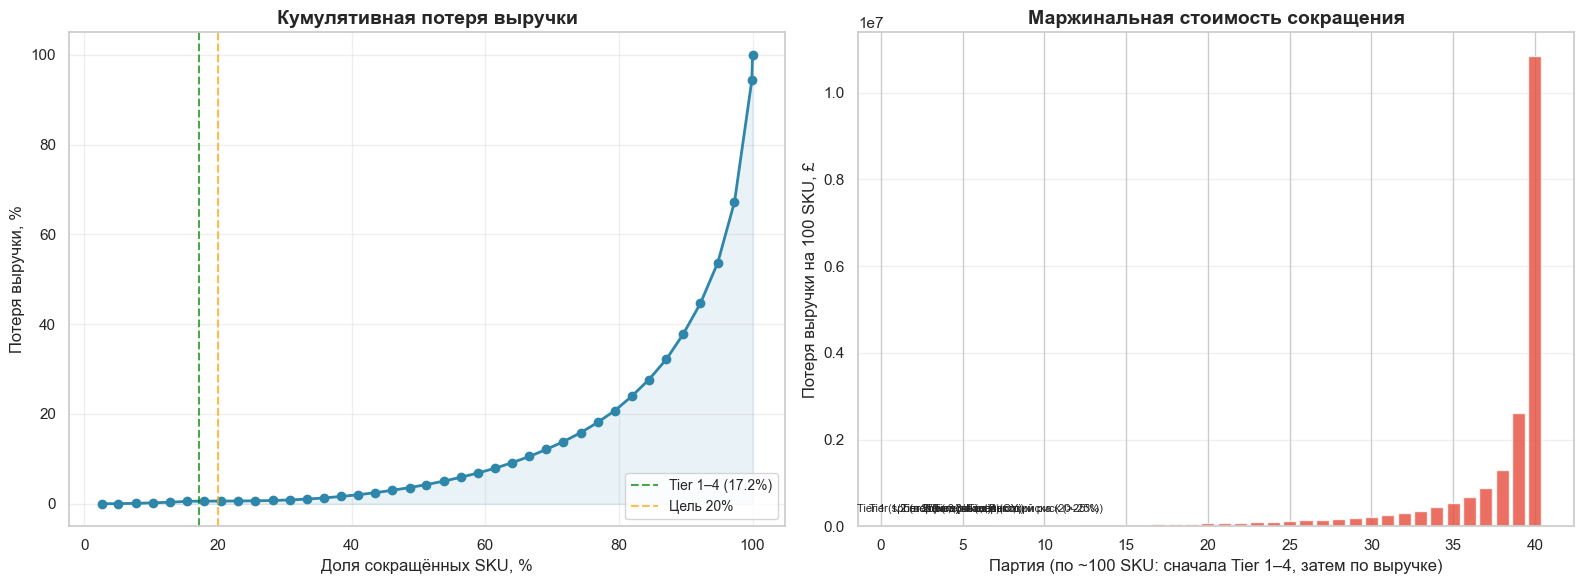


=== Ключевые точки кривой ===
     10% SKU → потеря  0.22% выручки ( 400 SKU, £    20,848)
     15% SKU → потеря  0.56% выручки ( 600 SKU, £    53,608)
   17.2% SKU → потеря  0.60% выручки ( 700 SKU, £    57,940)
     20% SKU → потеря  0.61% выручки ( 800 SKU, £    58,757)
     25% SKU → потеря  0.67% выручки (1000 SKU, £    64,297)
     30% SKU → потеря  0.86% выручки (1200 SKU, £    82,714)


In [65]:
# ── 1. Берём всех кандидатов (Tier 1–4) + оставшиеся SKU, отсортированные по выручке ──
# Ключ сортировки: Tier > 0 — по номеру тира, Tier 0 — в самый конец
all_sku = candidates.copy()
all_sku['_sort_key'] = np.where(all_sku['Tier'] > 0, all_sku['Tier'], 999)
all_sku = all_sku.sort_values(
    by=['_sort_key', 'Revenue'],
    ascending=[True, True],  # Tier 1 → 2 → 3 → 4, внутри — от дешёвых к дорогим, затем Tier 0
    na_position='last'
)
all_sku = all_sku.drop(columns=['_sort_key'])

total_sku_count = len(all_sku)
total_rev = all_sku['Revenue'].sum()

# ── 2. Разбиваем на партии по ~100 SKU ──
batch_size = 100
n_batches = int(np.ceil(total_sku_count / batch_size))

curve_data = []
cumulative_sku = 0
cumulative_rev = 0

tier_names = {1: 'Tier 1 (sporadic)', 2: 'Tier 2 (rare)',
              3: 'Tier 3 (chaotic)', 4: 'Tier 4 (CY)'}

for i in range(n_batches):
    start = i * batch_size
    end = min((i + 1) * batch_size, total_sku_count)
    batch = all_sku.iloc[start:end]

    cumulative_sku += len(batch)
    cumulative_rev += batch['Revenue'].sum()
    sku_pct = cumulative_sku / total_sku_count * 100

    # Зона определяется по фактическому составу Tier в партии
    batch_tiers = sorted(set(batch['Tier'].unique()) - {0})
    if batch_tiers:
        if len(batch_tiers) == 1:
            marker = tier_names.get(batch_tiers[0], f'Tier {batch_tiers[0]}')
        else:
            # Партия на стыке двух тиров
            marker = f'Tier {batch_tiers[0]}/{batch_tiers[-1]} (переход)'
    else:
        # За пределами кандидатов — зоны по доле SKU
        if sku_pct <= 20.0:
            marker = 'За пределами кандидатов (до 20%)'
        elif sku_pct <= 25.0:
            marker = 'Зона повышенного риска (20–25%)'
        else:
            marker = 'Высокий риск (>25%)'

    curve_data.append({
        'Batch': i + 1,
        'SKU_in_batch': len(batch),
        'Cumulative_SKU': cumulative_sku,
        'SKU_Pct': round(sku_pct, 1),
        'Batch_Revenue': round(batch['Revenue'].sum(), 0),
        'Cumulative_Revenue': round(cumulative_rev, 0),
        'Revenue_Loss_Pct': round(cumulative_rev / total_rev * 100, 2),
        'Marginal_Loss_per_100': round(batch['Revenue'].sum() / len(batch) * 100, 0) if len(batch) > 0 else 0,
        'Zone': marker,
    })

curve_df = pd.DataFrame(curve_data)

# ── 3. Вывод таблицы ──
print("=== Кривая безопасности сокращения ===")
print(f"Всего SKU: {total_sku_count}, общая выручка: £{total_rev:,.0f}\n")
print(curve_df[['Batch', 'Cumulative_SKU', 'SKU_Pct', 'Cumulative_Revenue',
                'Revenue_Loss_Pct', 'Marginal_Loss_per_100', 'Zone']].to_string(index=False))

# ── 4. График: две панели ──
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Левый: кумулятивная потеря выручки
ax1 = axes[0]
ax1.plot(curve_df['SKU_Pct'], curve_df['Revenue_Loss_Pct'],
         'o-', color='#2E86AB', linewidth=2, markersize=6)
ax1.axvline(x=17.2, color='green', linestyle='--', alpha=0.7, label='Tier 1–4 (17.2%)')
ax1.axvline(x=20, color='orange', linestyle='--', alpha=0.7, label='Цель 20%')
ax1.fill_between(curve_df['SKU_Pct'], 0, curve_df['Revenue_Loss_Pct'], alpha=0.1, color='#2E86AB')
ax1.set_xlabel('Доля сокращённых SKU, %', fontsize=12)
ax1.set_ylabel('Потеря выручки, %', fontsize=12)
ax1.set_title('Кумулятивная потеря выручки', fontsize=14, fontweight='bold')
ax1.legend(fontsize=10)
ax1.grid(True, alpha=0.3)

# Правый: маржинальная стоимость каждой партии
ax2 = axes[1]
colors = ['#27AE60' if 'Tier' in z else '#E74C3C' for z in curve_df['Zone']]
ax2.bar(curve_df['Batch'], curve_df['Marginal_Loss_per_100'], color=colors, alpha=0.8)
ax2.set_xlabel('Партия (по ~100 SKU: сначала Tier 1–4, затем по выручке)', fontsize=12)
ax2.set_ylabel('Потеря выручки на 100 SKU, £', fontsize=12)
ax2.set_title('Маржинальная стоимость сокращения', fontsize=14, fontweight='bold')
ax2.grid(True, alpha=0.3, axis='y')

# Подписи зон на правом графике
# Берём первую партию каждой уникальной зоны
seen_zones = set()
for i, row in curve_df.iterrows():
    if row['Zone'] not in seen_zones:
        seen_zones.add(row['Zone'])
        ax2.annotate(row['Zone'], (row['Batch'], row['Marginal_Loss_per_100']),
                     textcoords='offset points', xytext=(0, 10),
                     fontsize=8, ha='center', rotation=0)

plt.tight_layout()
plt.savefig('reduction_safety_curve.png', dpi=150, bbox_inches='tight')
plt.show()

# ── 5. Ключевые точки ──
print("\n=== Ключевые точки кривой ===")
targets = [10, 15, 17.2, 20, 25, 30]
for target in targets:
    closest = curve_df.iloc[(curve_df['SKU_Pct'] - target).abs().argsort()[:1]].iloc[0]
    print(f"  {target:>5}% SKU → потеря {closest['Revenue_Loss_Pct']:>5.2f}% выручки "
          f"({closest['Cumulative_SKU']:>4} SKU, £{closest['Cumulative_Revenue']:>10,.0f})")

Что видно по зонам:

- Tier 1 sporadic (партия 1, 100 SKU, 2.6%): потеря 0.01% выручки (£968). Маржинальная стоимость £968 на 100 SKU (£9.68/SKU). Это чистый мусор - 100 товаров зарабатывают меньше, чем один средний A-товар за неделю.

- Tier 1/2 - Tier 2 (партии 2-3, до 300 SKU, 7.7%): потеря 0.10% (£9,615). Маржинальная стоимость: £2,831 → £5,816 на 100 SKU. Всё ещё дёшево - £28-58/SKU.

- Tier 2/3 - Tier 3 (партии 4-6, до 600 SKU, 15.4%): потеря 0.56% (£53,608). Маржинальная стоимость: £11,232 → £13,049 → £19,711 на 100 SKU. Кривая ускоряется - переход от Tier 3 к Tier 4 стоит £197/SKU, это самая дорогая часть кандидатов.

- Tier 4 CY (партия 7, 700 SKU, 17.9%): потеря 0.60% (£57,940). Маржинальная стоимость £4,332 на 100 SKU (£43/SKU) - резкий спад после пика Tier 3/4. Нижние 15% CY, минимальная выручка.

- За пределами кандидатов (партии 8-9, до 23.0%): потеря 0.63% (£60,638). Маржинальная стоимость: £817 → £1,881 на 100 SKU (£8-19/SKU). Самые дешёвые партии на графике - дешевле даже Tier 1.

Ключевое наблюдение: кривая имеет пик внутри кандидатов, затем спад

Маржинальная стоимость по партиям:
£968 → £2,831 → £5,816 → £11,232 → £13,049 → £19,711 → £4,332 → £817 → £1,881 → £3,659 → £6,588 → £11,829

Кривая растёт до партии 6 (£19,711 - пик, переход Tier 3/4), затем резко падает: Tier 4 - £4,332, за пределами кандидатов - £817. После 25% снова растёт: £3,659 → £6,588 → £11,829. На 30% (1200 SKU) маржинальная стоимость £11,829 - в 12 раз больше, чем в начале.

Пик внутри кандидатов объясняется тем, что Tier 3 (CZ-chaotic) включает SKU с хаотичным, но не нулевым спросом - выручка у них выше, чем у sporadic/rare. А Tier 4 (нижние 15% CY) - это самые дешёвые из стабильных, их выручка ниже, чем у части Tier 3. За пределами кандидатов (£817/100) оказываются не-кандидаты с ещё более низкой выручкой, чем Tier 1.

Выводы:

1. Цель 20% достижима с потерей 0.61% выручки (£58,757). Переход от 17.9% (все кандидаты) к 20% стоит £817 (0.01% выручки) - фактически бесплатно.

2. Естественная граница - около 25%. До 25% (1000 SKU) потеря 0.67% (£64,297). Переход от 20% к 25% стоит £5,540 (0.06%). Но от 25% к 30% - уже £18,417 (0.19%), дальше кривая становится экспоненциальной.

3. Самая дорогая часть кандидатов - Tier 3 (партии 4-6, ~300 SKU): £44,000, или 76% от всех потерь кандидатов (£57,940). Tier 1-2 (партии 1-3) - £9,615 (17%). Tier 4 - £4,332 (7%).

4. Рекомендация: 20% - консервативная цель с потерей 0.61% выручки. Можно расширить до 25% (£64,297, 0.67%) - дополнительные 300 SKU за пределами кандидатов стоят дёшево (£8-37/SKU). Дальше 30% (£82,714, 0.86%) идти рискованно.

Предупреждения:

- Кривая считает только потерю выручки, не учитывает комплектность заказов, клиентскую лояльность, экономию на складских затратах.
- Tier 3 (партии 4-6) - самая дорогая часть кандидатов (£112-197/SKU). Перед выводом обязательно проверить привязку к A-товарам - хаотичный спрос не значит отсутствие роли в заказах.
- За пределами кандидатов (партии 8-9) маржинальная стоимость (£8-19/SKU) ниже, чем у Tier 3. Если цель - минимизировать потерю выручки при фиксированном количестве SKU, эти партии выгоднее, чем часть Tier 3.

### 7.3 Проверка дополнительных рисков 

Что НЕ учтено и нужно проверить:

- Связанность с A-товарами: входит ли SKU в заказы с AX/AY (Connection_risk)
- Уникальные клиенты: сколько клиентов покупают только этот SKU и ничего больше (Unique_customer_risk)
- Растущий спрос: сравним продажи последних 3 мес с первыми 3 мес - есть ли тренд (Growth_signal)

Не анализируется из данных:

- Стратегическая важность: не анализируется из данных - решение бизнеса
- Полнота категории: не анализируется из данных - решение категорийного менеджера

In [66]:
# ── 1. Список A-товаров для проверки связи ──
a_stockcodes = set(candidates[candidates['ABC'] == 'A']['StockCode'].tolist())
print(f"A-товаров для проверки связи: {len(a_stockcodes)}")

# ── 2. Connection_risk: доля заказов кандидата, где есть A-товар ──
# Берём только строки с кандидатами
cand_codes = set(final_candidates['StockCode'].tolist())
cand_orders = df_clean[df_clean['StockCode'].isin(cand_codes)].copy()

# Для каждого заказа кандидата проверяем, есть ли в этом же заказе A-товар
# Группируем по Invoice, собираем множество StockCode в заказе
invoice_items = df_clean.groupby('Invoice')['StockCode'].apply(set).to_dict()

# Считаем: для каждого кандидата — сколько его заказов содержат A-товар
cand_orders['has_a_in_same_invoice'] = cand_orders['Invoice'].map(
    lambda inv: bool(invoice_items.get(inv, set()) & a_stockcodes)
)

connection_stats = cand_orders.groupby('StockCode').agg(
    total_orders=('Invoice', 'nunique'),
    orders_with_a=('has_a_in_same_invoice', 'sum'),
).reset_index()

connection_stats['Connection_Risk_Pct'] = (
    connection_stats['orders_with_a'] / connection_stats['total_orders'] * 100
).round(1)
connection_stats['Connection_Flag'] = connection_stats['Connection_Risk_Pct'] > 50

# ── 3. Unique_customer_risk: клиенты, покупающие ТОЛЬКО этот SKU ──
# Для каждого клиента — множество всех купленных им StockCode
customer_items = df_clean.groupby('Customer ID')['StockCode'].apply(set).to_dict()

# Для каждого кандидата — сколько клиентов купили ТОЛЬКО его
unique_customers = []
for sku in final_candidates['StockCode']:
    # Все клиенты, покупавшие этот SKU
    sku_customers = set(
        df_clean[df_clean['StockCode'] == sku]['Customer ID'].dropna().unique()
    )
    # Из них — те, у кого этот SKU единственный в их истории
    only_this = [
        c for c in sku_customers
        if customer_items.get(c, set()) == {sku}
    ]
    unique_customers.append({
        'StockCode': sku,
        'Unique_Only_Customers': len(only_this),
        'Unique_Customer_Flag': len(only_this) > 0,
    })

unique_df = pd.DataFrame(unique_customers)

# ── 4. Growth_signal: последние 3 мес vs первые 3 мес ──
date_col = None
for c in ['InvoiceDate', 'Date', 'Invoice_Date', 'date']:
    if c in df_clean.columns:
        date_col = c
        break

if date_col is None:
    raise KeyError(f"Не найдена колонка даты. Доступные: {df_clean.columns.tolist()}")

df_clean[date_col] = pd.to_datetime(df_clean[date_col])

# Создаём колонку Month (YYYY-MM), если её ещё нет
if 'Month' not in df_clean.columns:
    df_clean['Month'] = df_clean[date_col].dt.to_period('M').astype(str)

# Упорядоченный список уникальных месяцев в периоде
all_months = sorted(df_clean['Month'].unique())

# Берём реальные первые 3 и последние 3 месяца периода
first_3_months = all_months[:3]
last_3_months  = all_months[-3:]

print(f"Первые 3 месяца:  {first_3_months}")
print(f"Последние 3 месяца: {last_3_months}")

first_3m = df_clean[df_clean['Month'].isin(first_3_months)]
last_3m  = df_clean[df_clean['Month'].isin(last_3_months)]

first_qty = first_3m.groupby('StockCode')['Quantity'].sum()
last_qty  = last_3m.groupby('StockCode')['Quantity'].sum()

growth_data = []
for sku in final_candidates['StockCode']:
    q1 = first_qty.get(sku, 0)
    q3 = last_qty.get(sku, 0)
    if q1 > 0:
        growth_pct = ((q3 - q1) / q1 * 100)
    elif q3 > 0:
        growth_pct = 999  # был ноль → стал неноль
    else:
        growth_pct = 0
    growth_data.append({
        'StockCode': sku,
        'Qty_First3M': q1,
        'Qty_Last3M': q3,
        'Growth_Pct': round(growth_pct, 1),
        'Growth_Flag': growth_pct > 50,
    })

growth_df = pd.DataFrame(growth_data)# ── 5. Объединяем всё в финальную таблицу ──
final_table = final_candidates.merge(
    connection_stats[['StockCode', 'Connection_Risk_Pct', 'Connection_Flag']],
    on='StockCode', how='left'
).merge(
    unique_df[['StockCode', 'Unique_Only_Customers', 'Unique_Customer_Flag']],
    on='StockCode', how='left'
).merge(
    growth_df[['StockCode', 'Qty_First3M', 'Qty_Last3M', 'Growth_Pct', 'Growth_Flag']],
    on='StockCode', how='left'
)

# Заполняем пропуски
final_table['Connection_Risk_Pct'] = final_table['Connection_Risk_Pct'].fillna(0)
final_table['Connection_Flag'] = final_table['Connection_Flag'].fillna(False).astype(bool)
final_table['Unique_Only_Customers'] = final_table['Unique_Only_Customers'].fillna(0).astype(int)
final_table['Unique_Customer_Flag'] = final_table['Unique_Customer_Flag'].fillna(False).astype(bool)
final_table['Growth_Flag'] = final_table['Growth_Flag'].fillna(False).astype(bool)

# ── 6. Сводный флаг риска ──
final_table['Risk_Flag'] = (
    final_table['Connection_Flag'] |
    final_table['Unique_Customer_Flag'] |
    final_table['Growth_Flag']
)

# Обновляем рекомендацию
def update_recommendation(row):
    tier = row['Tier']
    flags = []
    if row['Connection_Flag']:
        flags.append(f"связь с A-товарами ({row['Connection_Risk_Pct']:.0f}% заказов)")
    if row['Unique_Customer_Flag']:
        flags.append(f"{row['Unique_Only_Customers']} уникальных клиентов")
    if row['Growth_Flag']:
        flags.append(f"рост спроса (+{row['Growth_Pct']:.0f}%)")
    
    base_recs = {
        1: 'Вывод. 1–2 продажи за год.',
        2: 'Вывод. Редкий спрос при полной истории.',
        3: 'Вывод рекомендован. Хаотичный спрос, низкая выручка.',
        4: 'Вывод под вопросом. Стабильный, но минимальный спрос.',
    }
    
    if flags:
        return f"⚠ Проверить вручную: {'; '.join(flags)}. Базовая рекомендация: {base_recs.get(tier, '')}"
    else:
        return base_recs.get(tier, '') + ' Рисков не обнаружено.'

final_table['Recommendation'] = final_table.apply(update_recommendation, axis=1)

# ── 7. Сводка ──
print("=== Проверка рисков по 670 кандидатам ===\n")
print(f"Всего кандидатов: {len(final_table)}")
print(f"Чистый вывод (без флагов): {(~final_table['Risk_Flag']).sum()}")
print(f"Проверить вручную (есть флаги): {final_table['Risk_Flag'].sum()}")
print()

flag_counts = {
    'Connection_Risk (связь с A)': final_table['Connection_Flag'].sum(),
    'Unique_Customer_Risk (уник. клиенты)': final_table['Unique_Customer_Flag'].sum(),
    'Growth_Signal (рост спроса)': final_table['Growth_Flag'].sum(),
}
print("Срабатывание по типам риска:")
for k, v in flag_counts.items():
    print(f"  {k}: {v} SKU ({v/len(final_table)*100:.1f}%)")

print("\nРазбивка по тирам:")
tier_risk = final_table.groupby('Tier').agg(
    Total=('StockCode', 'count'),
    Risk_Flagged=('Risk_Flag', 'sum'),
    Clean=('StockCode', lambda x: (~final_table.loc[x.index, 'Risk_Flag']).sum()),
).reset_index()
tier_risk['Risk_Pct'] = (tier_risk['Risk_Flagged'] / tier_risk['Total'] * 100).round(1)
print(tier_risk.to_string(index=False))

# ── 8. Сохраняем ──
final_table = final_table.sort_values(['Tier', 'Risk_Flag', 'Revenue'], ascending=[True, False, True])

export_cols = [
    'StockCode', 'Description', 'ABC', 'XYZ', 'Group', 'Tier',
    'Revenue', 'Revenue_Share_Pct', 'Quantity', 'Orders', 'Customers',
    'ActiveMonths', 'Connection_Risk_Pct', 'Connection_Flag',
    'Unique_Only_Customers', 'Unique_Customer_Flag',
    'Qty_First3M', 'Qty_Last3M', 'Growth_Pct', 'Growth_Flag',
    'Risk_Flag', 'Recommendation'
]

# ── 9. Примеры сработавших флагов ──
print("\n=== Примеры SKU с флагами ===\n")

if final_table['Connection_Flag'].any():
    print("── Connection_Risk (связь с A-товарами) ──")
    subset = final_table[final_table['Connection_Flag']].sort_values('Connection_Risk_Pct', ascending=False).head(10)
    print(subset[['StockCode', 'Description', 'Tier', 'Connection_Risk_Pct', 'Revenue']].to_string(index=False))

if final_table['Unique_Customer_Flag'].any():
    print("\n── Unique_Customer_Risk (уникальные клиенты) ──")
    subset = final_table[final_table['Unique_Customer_Flag']].sort_values('Unique_Only_Customers', ascending=False).head(10)
    print(subset[['StockCode', 'Description', 'Tier', 'Unique_Only_Customers', 'Revenue']].to_string(index=False))

if final_table['Growth_Flag'].any():
    print("\n── Growth_Signal (рост спроса) ──")
    subset = final_table[final_table['Growth_Flag']].sort_values('Growth_Pct', ascending=False).head(10)
    print(subset[['StockCode', 'Description', 'Tier', 'Qty_First3M', 'Qty_Last3M', 'Growth_Pct', 'Revenue']].to_string(index=False))

A-товаров для проверки связи: 832
Первые 3 месяца:  [Period('2010-12', 'M'), Period('2011-01', 'M'), Period('2011-02', 'M')]
Последние 3 месяца: [Period('2011-09', 'M'), Period('2011-10', 'M'), Period('2011-11', 'M')]
=== Проверка рисков по 670 кандидатам ===

Всего кандидатов: 646
Чистый вывод (без флагов): 3
Проверить вручную (есть флаги): 643

Срабатывание по типам риска:
  Connection_Risk (связь с A): 643 SKU (99.5%)
  Unique_Customer_Risk (уник. клиенты): 3 SKU (0.5%)
  Growth_Signal (рост спроса): 147 SKU (22.8%)

Разбивка по тирам:
 Tier  Total  Risk_Flagged  Clean  Risk_Pct
    1    137           134      3      97.8
    2    189           189      0     100.0
    3    264           264      0     100.0
    4     56            56      0     100.0

=== Примеры SKU с флагами ===

── Connection_Risk (связь с A-товарами) ──
StockCode                        Description  Tier  Connection_Risk_Pct  Revenue
   90199C    5 STRAND GLASS NECKLACE CRYSTAL     2                120.0   120.2

1. Connection_Risk (связь с A-товарами): 643 SKU (99.5%). Почти все наши кандидаты критически связаны с A-товарами. Выводя их, мы не теряем в прямой выручке (она мизерная), но берём на себя высокие риски:

- снизить конверсию по A-товару (если клиент ищет «набор» или «комплект», как видно из примеров вроде SILVER CANDLEPOT JARDIN или POLKADOT PUDDING BOWL);
- ухудшить средний чек;
- потерять лояльность («раньше тут было всё, а теперь нет»).

2. Growth_Signal (рост спроса): 147 SKU (22.8%). Среди кандидатов (преимущественно в Tier 3) есть товары, которые стартовали с 1–2 штук, а сейчас продаются сотнями. Пример: POPART RECT PENCIL SHARPENER ASST (Tier 3) – рост 34 600% (с 2 до 694 шт.). Да, база была микроскопической, но тренд взрывной. Выводить такие товары сейчас – значит убить потенциально растущую позицию.

3. Unique_Customer_Risk (уникальные клиенты): 3 SKU (0.5%). Небольшая группа товаров (например, MIDNIGHT BLUE DROP CRYSTAL NECKLACE), которые покупают только уникальные клиенты. Их вывод создает риск потери конкретного покупателя.

4. Чистый вывод и разбивка по тирам:

- Чистый вывод (без флагов): всего 3 SKU (все находятся в Tier 1).
- Требуют ручной проверки: 643 SKU.
- В Tier 2, Tier 3 и Tier 4 100% товаров имеют флаги риска (0 чистых кандидатов). В Tier 1 «чистыми» являются лишь 3 товара из 137 (97.8% имеют риски).

Главный вывод:

Стратегия «просто резать по выручке» в этом датасете не работает. Математически слабые товары здесь функционально важны для продаж сильных (A-товаров) или имеют скрытый потенциал взрывного роста. Любое сокращение beyond 3 "чистых" SKU требует ручной проверки перекрёстных продаж, чтобы не подорвать выручку основного ассортимента.

Дальше можно рассмотреть три пути, в зависимости от того, какая задача скорее стоит перед бизнесом:

Путь 1. Если цель - освободить место/снизить издержки, но не трогать клиентский опыт
Решение: Не трогать эти 643. Искать сокращения вне этой выборки.
В датасете 3 905 SKU. Эти 643 - это те, что попали в ABC/XYZ как «слабые», но оказались «связующими». Значит, где‑то в оставшихся 3 200 SKU есть настоящие «мёртвые» позиции: те, по которым вообще нет продаж, или те, которые не связаны ни с чем.

Путь 2. Если цель - жёстко сократить именно эти 643 (например, склад переполнен)
Решение: Вводить поэтапное тестирование, а не массовый вывод.

- Вывести только 3 «чистых» SKU (те, у которых нет флагов). Это безопасно.
- Для остальных - A/B‑тест: убрать часть SKU из онлайн‑витрины (но оставить на складе) и сравнить конверсию и средний чек по A‑товарам в контрольной и тестовой группах.
- Товары с ростом спроса (152 шт.) - категорически не трогать или вынести в отдельный список «на наблюдение».

Путь 3. Пересмотреть саму метрику «сокращения»
Может быть, бизнесу нужно не «меньше SKU», а «меньше мёртвого веса». Тогда эти 643 трогать не надо, а надо:

- перевести часть из них в drop‑ship (не хранить на складе, привозить под заказ);
- объединить мелкие позиции в наборы (чтобы они продолжали продаваться как часть A‑комплекта, но занимали меньше логистических единиц).

### 7.4 Исследуем операционную нагрузку SKU

Ещё один критерий приоритизации - насколько SKU «тяжелый» для бизнеса.  Среди кандидатов с одинаковым риском вывода лучше в первую очередь резать те, что создают больше операционной нагрузки при низкой отдаче.

Построим композитный показатель - «Индекс операционной нагрузки» (Burden Score). Это не чистая стоимость обслуживания, а индекс совокупной нагрузки SKU на ассортимент. Он штрафует товары за высокую операционную активность (заказы, единицы, месяцы на полке) и за низкую выручку. Это сознательное упрощение: у нас нет данных о реальной себестоимости picking/packing, поэтому мы используем прокси. Для приоритизации кандидатов на вывод этого достаточно — нам важно не абсолютное значение £, а относительный ранг SKU внутри тира.

Чем выше Score - тем сильнее SKU давит на операции относительно своей пользы.

=== Индекс нагрузки (Burden Score) по тирам ===

      SKU_Count  Avg_Burden_Score  Avg_Revenue  Avg_Orders  Avg_Quantity  Avg_Rev_per_Order  Avg_Rev_per_Month
Tier                                                                                                          
1           137              0.23        19.55        2.50          8.85               8.99              14.70
2           189              0.31        73.85        7.84         12.46               9.52              14.39
3           264              0.42       139.08       22.65        132.56               7.18              17.84
4            56              0.47        79.50       25.75         83.36               3.62               8.06

=== Топ-20 по Burden Score (самые тяжёлые для ассортимента) ===

StockCode                        Description  Tier  Risk_Flag  Revenue  Orders  Quantity  ActiveMonths  Revenue_per_Order  Revenue_per_Month  Burden_Score
   35817P       ACRYLIC JEWEL SNOWFLAKE,PINK     1      False   

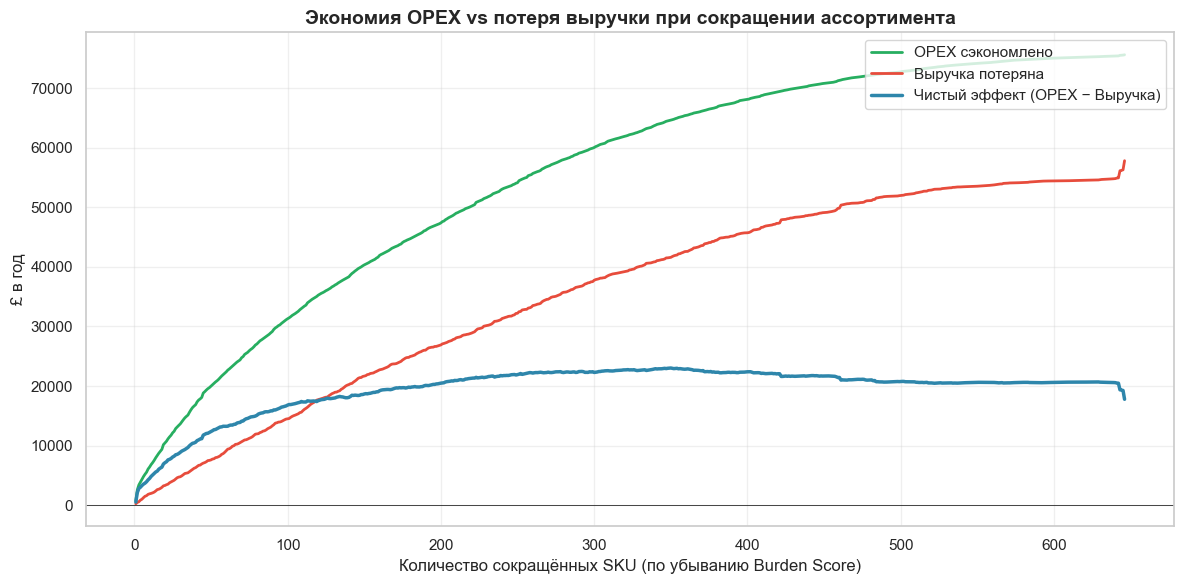

In [67]:
# ── 1. Считаем прокси операционной нагрузки (Burden Score) ──
# Логика: чем больше операций и меньше выручка — тем выше нагрузка на бизнес

cts = final_table.copy()

# Вспомогательные метрики для интерпретации
cts['Revenue_per_Order'] = (cts['Revenue'] / cts['Orders'].replace(0, np.nan)).fillna(0)
cts['Revenue_per_Unit']  = (cts['Revenue'] / cts['Quantity'].replace(0, np.nan)).fillna(0)
cts['Revenue_per_Month'] = (cts['Revenue'] / cts['ActiveMonths'].replace(0, np.nan)).fillna(0)

# ── 2. Нормализуем компоненты и строим Burden Score ──
# Компоненты «нагрузки» (чем больше — тем хуже):
#   Orders       — больше заказов = больше picking/packing
#   Quantity     — больше единиц = больше handling
#   ActiveMonths — дольше на полке = больше хранения
# Компонент «низкой отдачи» (инвертированный):
#   Revenue      — чем меньше выручка, тем хуже окупает нагрузку

cts['Orders_Norm']   = cts['Orders']       / cts['Orders'].max()
cts['Quantity_Norm'] = cts['Quantity']     / cts['Quantity'].max()
cts['Months_Norm']   = cts['ActiveMonths'] / cts['ActiveMonths'].max()
cts['Revenue_Norm']  = 1 - (cts['Revenue'] / cts['Revenue'].max())  # инверсия

# Burden Score: взвешенная сумма (веса можно калибровать)
cts['Burden_Score'] = (
    cts['Orders_Norm']   * 0.35 +
    cts['Quantity_Norm'] * 0.25 +
    cts['Months_Norm']   * 0.20 +
    cts['Revenue_Norm']  * 0.20
).round(3)

# ── 3. Ранжируем внутри каждого тира ──
# Сортировка: Tier → Risk_Flag (False сначала = безопасные) → Burden_Score (по убыванию)
cts = cts.sort_values(
    ['Tier', 'Risk_Flag', 'Burden_Score'],
    ascending=[True, True, False]
).reset_index(drop=True)

# ── 4. Ранг внутри тира ──
cts['Rank_in_Tier'] = cts.groupby('Tier').cumcount() + 1

# ─ 5. Сводка: средний Burden Score по тирам ──
print("=== Индекс нагрузки (Burden Score) по тирам ===\n")
cts_summary = cts.groupby('Tier').agg(
    SKU_Count=('StockCode', 'count'),
    Avg_Burden_Score=('Burden_Score', 'mean'),
    Avg_Revenue=('Revenue', 'mean'),
    Avg_Orders=('Orders', 'mean'),
    Avg_Quantity=('Quantity', 'mean'),
    Avg_Rev_per_Order=('Revenue_per_Order', 'mean'),
    Avg_Rev_per_Month=('Revenue_per_Month', 'mean'),
).round(2)
print(cts_summary.to_string())

# ── 6. Топ-20 «самых тяжёлых» SKU (высокая нагрузка, низкая отдача) ──
print("\n=== Топ-20 по Burden Score (самые тяжёлые для ассортимента) ===\n")
top_burden = cts.head(20)[[
    'StockCode', 'Description', 'Tier', 'Risk_Flag',
    'Revenue', 'Orders', 'Quantity', 'ActiveMonths',
    'Revenue_per_Order', 'Revenue_per_Month',
    'Burden_Score'
]]
print(top_burden.to_string(index=False))

# ── 7. Топ-20 «самых лёгких» SKU (если режем — начинаем с тяжёлых) ─
print("\n=== Bottom-20 по Burden Score (самые лёгкие для ассортимента) ===\n")
bottom_burden = cts.sort_values('Burden_Score').head(20)[[
    'StockCode', 'Description', 'Tier', 'Risk_Flag',
    'Revenue', 'Orders', 'Quantity', 'ActiveMonths',
    'Revenue_per_Order', 'Revenue_per_Month',
    'Burden_Score'
]]
print(bottom_burden.to_string(index=False))

# ── 8. Кумулятивный эффект сокращения по Burden Score ──
# Грубая оценка OPEX (можно заменить на реальные цифры бизнеса)
cost_per_order = 5     # £ на picking/packing/shipping
cost_per_unit  = 0.50  # £ на handling единицы
cost_per_month = 2     # £ на содержание полки в месяц

cts['Est_Opex_per_Year'] = (
    cts['Orders']      * cost_per_order +
    cts['Quantity']    * cost_per_unit  +
    cts['ActiveMonths']* cost_per_month
).round(0)

cts['Net_Value'] = cts['Revenue'] - cts['Est_Opex_per_Year']

# Кумулятивные суммы при сокращении от самых «тяжёлых» к «лёгким»
cts_sorted = cts.sort_values('Burden_Score', ascending=False).copy()
cts_sorted['Cumul_Opex_Saved']    = cts_sorted['Est_Opex_per_Year'].cumsum()
cts_sorted['Cumul_Revenue_Lost']  = cts_sorted['Revenue'].cumsum()
cts_sorted['Cumul_Net_Effect']    = cts_sorted['Cumul_Opex_Saved'] - cts_sorted['Cumul_Revenue_Lost']
cts_sorted['SKU_Count_Cum']       = range(1, len(cts_sorted) + 1)

print("\n=== Кумулятивный эффект сокращения (по Burden Score) ===\n")
print(f"Предположения: £{cost_per_order}/заказ, £{cost_per_unit}/единица, £{cost_per_month}/мес полки\n")

checkpoints = [50, 100, 150, 200, 300, 400, 500, 670]
for cp in checkpoints:
    if cp <= len(cts_sorted):
        row = cts_sorted.iloc[cp - 1]
        print(f"  {cp:>3} SKU → OPEX сэкономлено: £{row['Cumul_Opex_Saved']:>8,.0f} | "
              f"Выручка потеряна: £{row['Cumul_Revenue_Lost']:>8,.0f} | "
              f"Чистый эффект: £{row['Cumul_Net_Effect']:>8,.0f}")

# ── 9. Колонки для экспорта ──
export_cols_cts = export_cols + [
    'Revenue_per_Order', 'Revenue_per_Unit', 'Revenue_per_Month',
    'Burden_Score', 'Rank_in_Tier',
    'Est_Opex_per_Year', 'Net_Value'
]

# ── 10. График: Net Effect vs количество сокращённых SKU ──
fig, ax = plt.subplots(figsize=(12, 6))
ax.plot(cts_sorted['SKU_Count_Cum'], cts_sorted['Cumul_Opex_Saved'],
        '-', color='#27AE60', linewidth=2, label='OPEX сэкономлено')
ax.plot(cts_sorted['SKU_Count_Cum'], cts_sorted['Cumul_Revenue_Lost'],
        '-', color='#E74C3C', linewidth=2, label='Выручка потеряна')
ax.plot(cts_sorted['SKU_Count_Cum'], cts_sorted['Cumul_Net_Effect'],
        '-', color='#2E86AB', linewidth=2.5, label='Чистый эффект (OPEX − Выручка)')

# Точка безубыточности
breakeven = cts_sorted[cts_sorted['Cumul_Net_Effect'] <= 0]
if len(breakeven) > 0:
    be_point = breakeven.iloc[0]
    ax.axvline(x=be_point['SKU_Count_Cum'], color='gray', linestyle='--', alpha=0.5)
    ax.annotate(f"Точка безубыточности\n({be_point['SKU_Count_Cum']} SKU)",
                xy=(be_point['SKU_Count_Cum'], 0),
                xytext=(be_point['SKU_Count_Cum'] + 30, be_point['Cumul_Net_Effect'] * 0.3),
                fontsize=10, ha='left',
                arrowprops=dict(arrowstyle='->', color='gray'))

ax.axhline(y=0, color='black', linewidth=0.5)
ax.set_xlabel('Количество сокращённых SKU (по убыванию Burden Score)', fontsize=12)
ax.set_ylabel('£ в год', fontsize=12)
ax.set_title('Экономия OPEX vs потеря выручки при сокращении ассортимента', 
             fontsize=14, fontweight='bold')
ax.legend(fontsize=11, loc='upper right')
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('burden_score_analysis.png', dpi=150, bbox_inches='tight')
plt.show()

Сокращение этих SKU реально экономит бизнесу деньги - но только до ~400 штук. После этой точки каждый дополнительный выведенный SKU приносит меньше экономии, чем теряет выручки.

Между 400 и 500 SKU чистый эффект падает с £22,387 до £20,756. То есть следующие 100 SKU приносят бизнесу меньше пользы, чем предыдущие 400, хотя формально тоже «в плюсе».

Кривая чистого эффекта растёт до ~400 SKU, потому что:

- Первые 50–100 SKU (в основном Tier 1) - это «тяжёлый мусор»: мало выручки (в среднем £19.55), но есть заказы и единицы. Их вывод даёт максимум экономии при минимуме потерь.
- К 200–400 мы забираем Tier 2 и значительную часть Tier 3 - товары с бóльшим количеством заказов, но всё ещё низкой выручкой на заказ (в среднем £7.18–£9.52 за заказ при £5 стоимости обработки).
- После 400 начинаются более глубокие слои Tier 3 и Tier 4. У Tier 4 в среднем 25.75 заказов, но выручка с заказа составляет всего £3.62. Хотя они убыточны на единицу заказа, их массовый вывод начинает съедать общую выручку быстрее, чем экономит OPEX, из-за чего чистый эффект снижается.

Но кривая не учитывает `Risk_Flag`: в Топ-20 самых «тяжёлых» по нагрузке SKU почти у всех (18 из 20) стоит флаг риска. Реальная потеря может оказаться выше, если вывод этих SKU снизит конверсию по A-товарам.

Рекомендация - трёхэтапный план:

Этап 1 - «Быстрая экономия» (до 50 SKU): Только SKU с самым высоким Burden Score (в основном Tier 1). Чистый эффект +£12,373, риск минимальный (среди топ-20 есть 2 SKU без флагов риска).

Этап 2 - «Оптимум» (до 400 SKU): Добавить Tier 2 и основную часть Tier 3, отсортированных по Burden Score. Чистый эффект достигает пика +£22,387. Но это требует A/B-теста: убрать с витрины, оставить на складе, проверить конверсию по A-товарам через 4–6 недель.

Этап 3 - «Только при жёсткой необходимости» (до 500 SKU и далее): Добрать Tier 4 и остаток Tier 3. Эффект падает до +£20,756. Ради этого не стоит рисковать связкой с A-товарами, так как маржинальная выгода от сокращения начинает снижаться.

### 7.5 Ищем настоящие «мёртвые души»

Попробуем пойти по пути: «освободить место/снизить издержки, но не трогать клиентский опыт»: не трогать эти 643, связанные с A-товарами. Искать сокращения вне выборки в 646 SKU. 

В датасете 3 905 SKU. Эти 643 - это те, что попали в ABC/XYZ как «слабые» (646), но 643 из них оказались «связующими». 

Значит, где‑то в оставшихся 3 259 SKU есть настоящие «мёртвые» позиции: те, по которым вообще нет продаж, или те, которые не связаны ни с чем.

Попытаемся найти настоящие «мёртвые души» вне списка 646. Причём не просто посчитаем количество, а применим те же проверки рисков и индекс операционной нагрузки SKU.

1. Найдём все SKU вне 646 - это 3 259 позиций, которые не попали в наши тиры.
2. Классифицируем их по уровню активности:
- Dead - нет продаж последние 6+ месяцев
- Dormant - 1–3 заказа за весь период
- Low-activity - 4–10 заказов, выручка < £100
- Active — всё остальное
3. Применяем те же три проверки риска: Connection, Unique Customer, Growth.
4. Выявляем «мёртвых без рисков»: SKU, которые не продаются (или почти не продаются) и при этом не связаны с A-товарами. Это идеальные кандидаты на чистый вывод.
5. Считаем Burden Score - чтобы внутри нового пула тоже ранжировать по дороговизне обслуживания.
6. Объединяем с результатами по 646 кандидатам - это даст нам финальную картину: сколько реально безопасно вывести, сколько требует проверки.

In [68]:
# ── 1. Все SKU, не входящие в 646 кандидатов ──
candidate_codes = set(final_candidates['StockCode'].tolist())
all_codes = set(df_clean['StockCode'].unique())
outside_codes = all_codes - candidate_codes

print(f"Всего SKU в датасете: {len(all_codes)}")
print(f"Уже в кандидатах (646): {len(candidate_codes)}")
print(f"Осталось вне кандидатов: {len(outside_codes)}")

# ── 2. Строим таблицу для SKU вне кандидатов ──
outside = df_clean[df_clean['StockCode'].isin(outside_codes)].copy()

outside_stats = outside.groupby('StockCode').agg(
    Quantity=('Quantity', 'sum'),
    Orders=('Invoice', 'nunique'),
    Customers=('Customer ID', 'nunique'),
    Revenue=('Revenue', 'sum'),
).reset_index()

# Добавляем ABC/XYZ из matrix
outside_stats = outside_stats.merge(
    matrix[['StockCode', 'ABC', 'XYZ']], on='StockCode', how='left'
)

# Описание
outside_stats['Description'] = outside_stats['StockCode'].map(sku_desc)

# ActiveMonths
outside_stats = outside_stats.merge(
    xyz_stats['months_active'].reset_index().rename(
        columns={'index': 'StockCode', 'months_active': 'ActiveMonths'}
    ),
    on='StockCode', how='left'
)

# ── 3. Дата последней продажи ──
date_col = None
for c in ['InvoiceDate', 'Date', 'Invoice_Date', 'date']:
    if c in df_clean.columns:
        date_col = c
        break
if date_col is None:
    raise KeyError(f"Не найдена колонка даты. Доступные: {df_clean.columns.tolist()}")

df_clean[date_col] = pd.to_datetime(df_clean[date_col])
last_sale = outside.groupby('StockCode')[date_col].max().reset_index()
last_sale.columns = ['StockCode', 'LastSaleDate']
outside_stats = outside_stats.merge(last_sale, on='StockCode', how='left')

# Сколько месяцев с последней продажи
period_end = df_clean[date_col].max()
outside_stats['Months_Since_Last_Sale'] = (
    (period_end - outside_stats['LastSaleDate']).dt.days / 30.44
).round(1)

# ── 4. Категории «мёртвых» SKU ──
# Dead: нет продаж в последние 6+ месяцев
# Dormant: 1–3 заказа за весь период
# Low-activity: 4–10 заказов, но маленькая выручка

outside_stats['Status'] = 'Active'
outside_stats.loc[outside_stats['Months_Since_Last_Sale'] >= 6, 'Status'] = 'Dead'
outside_stats.loc[
    (outside_stats['Orders'] <= 3) & (outside_stats['Status'] != 'Dead'),
    'Status'
] = 'Dormant'
outside_stats.loc[
    (outside_stats['Orders'] >= 4) &
    (outside_stats['Orders'] <= 10) &
    (outside_stats['Revenue'] < 100) &
    (outside_stats['Status'] == 'Active'),
    'Status'
] = 'Low-activity'

# ── 5. Connection_Risk для нового пула ─
invoice_items = df_clean.groupby('Invoice')['StockCode'].apply(set).to_dict()
a_stockcodes = set(candidates[candidates['ABC'] == 'A']['StockCode'].tolist())

outside_orders = df_clean[df_clean['StockCode'].isin(outside_codes)].copy()
outside_orders['has_a_in_same_invoice'] = outside_orders['Invoice'].map(
    lambda inv: bool(invoice_items.get(inv, set()) & a_stockcodes)
)

outside_conn = outside_orders.groupby('StockCode').agg(
    total_orders=('Invoice', 'nunique'),
    orders_with_a=('has_a_in_same_invoice', 'sum'),
).reset_index()
outside_conn['Connection_Risk_Pct'] = (
    outside_conn['orders_with_a'] / outside_conn['total_orders'] * 100
).round(1)
outside_conn['Connection_Flag'] = outside_conn['Connection_Risk_Pct'] > 50

outside_stats = outside_stats.merge(
    outside_conn[['StockCode', 'Connection_Risk_Pct', 'Connection_Flag']],
    on='StockCode', how='left'
)

# ── 6. Unique_Customer_Risk ──
customer_items = df_clean.groupby('Customer ID')['StockCode'].apply(set).to_dict()

unique_list = []
for sku in outside_stats['StockCode']:
    sku_customers = set(
        df_clean[df_clean['StockCode'] == sku]['Customer ID'].dropna().unique()
    )
    only_this = [c for c in sku_customers if customer_items.get(c, set()) == {sku}]
    unique_list.append({
        'StockCode': sku,
        'Unique_Only_Customers': len(only_this),
        'Unique_Customer_Flag': len(only_this) > 0,
    })

outside_stats = outside_stats.merge(
    pd.DataFrame(unique_list), on='StockCode', how='left'
)

# ── 7. Growth_Signal: последние 3 мес vs первые 3 мес  ──
# Создаём колонку Month, если её нет
if 'Month' not in outside_stats.columns:
    # Берём из df_clean
    df_clean['Month'] = df_clean[date_col].dt.to_period('M').astype(str)

all_months = sorted(df_clean['Month'].unique())
first_3_months = all_months[:3]
last_3_months = all_months[-3:]

print(f"Первые 3 месяца:  {first_3_months}")
print(f"Последние 3 месяца: {last_3_months}")

first_3m = df_clean[df_clean['Month'].isin(first_3_months)]
last_3m = df_clean[df_clean['Month'].isin(last_3_months)]

first_qty = first_3m.groupby('StockCode')['Quantity'].sum()
last_qty = last_3m.groupby('StockCode')['Quantity'].sum()

growth_list = []
for sku in outside_stats['StockCode']:
    q1 = first_qty.get(sku, 0)
    q3 = last_qty.get(sku, 0)
    if q1 > 0:
        growth_pct = (q3 - q1) / q1 * 100
    elif q3 > 0:
        growth_pct = 999
    else:
        growth_pct = 0
    growth_list.append({
        'StockCode': sku,
        'Growth_Pct': round(growth_pct, 1),
        'Growth_Flag': growth_pct > 50,
    })

outside_stats = outside_stats.merge(
    pd.DataFrame(growth_list), on='StockCode', how='left'
)

# ── 8. Сводный флаг риска ──
outside_stats['Risk_Flag'] = (
    outside_stats['Connection_Flag'].fillna(False) |
    outside_stats['Unique_Customer_Flag'].fillna(False) |
    outside_stats['Growth_Flag'].fillna(False)
)

# ── 9. Burden Score для нового пула ──
# Нормализация по максимумам внутри outside_stats (отдельно от основного пула)
outside_stats['Revenue_per_Order'] = (
    outside_stats['Revenue'] / outside_stats['Orders'].replace(0, np.nan)
).fillna(0)
outside_stats['Revenue_per_Unit'] = (
    outside_stats['Revenue'] / outside_stats['Quantity'].replace(0, np.nan)
).fillna(0)
outside_stats['Revenue_per_Month'] = (
    outside_stats['Revenue'] / outside_stats['ActiveMonths'].replace(0, np.nan)
).fillna(0)

outside_stats['Orders_Norm'] = outside_stats['Orders'] / outside_stats['Orders'].max()
outside_stats['Quantity_Norm'] = outside_stats['Quantity'] / outside_stats['Quantity'].max()
outside_stats['Months_Norm'] = outside_stats['ActiveMonths'] / outside_stats['ActiveMonths'].max()
outside_stats['Revenue_Norm'] = 1 - (outside_stats['Revenue'] / outside_stats['Revenue'].max())

outside_stats['Burden_Score'] = (
    outside_stats['Orders_Norm']   * 0.35 +
    outside_stats['Quantity_Norm'] * 0.25 +
    outside_stats['Months_Norm']   * 0.20 +
    outside_stats['Revenue_Norm']  * 0.20
).round(3)

# ── 10. Итоговая сводка по новому пулу ──
print("\n=== Анализ SKU вне 646 кандидатов ===\n")
print(f"Всего SKU вне 646 кандидатов: {len(outside_stats)}\n")

status_counts = outside_stats['Status'].value_counts()
print("По статусу:")
for s, c in status_counts.items():
    print(f"  {s}: {c} SKU ({c/len(outside_stats)*100:.1f}%)")

risk_counts = outside_stats['Risk_Flag'].value_counts()
print("\nПо флагам риска:")
for r, c in risk_counts.items():
    label = "Без рисков" if not r else "Есть риски"
    print(f"  {label}: {c} SKU ({c/len(outside_stats)*100:.1f}%)")

# Мёртвые/Dormant без рисков — идеальные кандидаты на чистый вывод
dead_no_link = outside_stats[
    (outside_stats['Status'].isin(['Dead', 'Dormant'])) &
    (~outside_stats['Risk_Flag'])
]
dead_with_link = outside_stats[
    (outside_stats['Status'].isin(['Dead', 'Dormant'])) &
    (outside_stats['Risk_Flag'])
]

print(f"\nМёртвые/Dormant БЕЗ рисков (чистый вывод): {len(dead_no_link)} SKU")
print(f"Мёртвые/Dormant С рисками (проверить): {len(dead_with_link)} SKU")

if len(dead_no_link) > 0:
    total_rev_dead = dead_no_link['Revenue'].sum()
    print(f"Их суммарная выручка: £{total_rev_dead:,.0f}")

# ── 11. Топ-20 «мёртвых» без рисков (по Burden Score) ──
if len(dead_no_link) > 0:
    dead_clean = dead_no_link.sort_values('Burden_Score', ascending=False)
    print("\n=== Топ-20 «мёртвых» SKU без рисков (чистый вывод, по Burden Score) ===\n")
    print(dead_clean.head(20)[[
        'StockCode', 'Description', 'ABC', 'XYZ', 'Status',
        'Revenue', 'Orders', 'Quantity', 'Months_Since_Last_Sale',
        'Burden_Score'
    ]].to_string(index=False))

# ── 12. Объединяем с 646 кандидатами ──
print("\n=== Сводка: все кандидаты на сокращение ===\n")
print(f"  Оригинальные 646: {len(final_table)} SKU, выручка £{final_table['Revenue'].sum():,.0f}")
print(f"  Новые «мёртвые» без рисков: {len(dead_no_link)} SKU, выручка £{dead_no_link['Revenue'].sum():,.0f}")
print(f"  Новые «мёртвые» с рисками: {len(dead_with_link)} SKU, выручка £{dead_with_link['Revenue'].sum():,.0f}")

# Из оригинальных 646: 3 чистых SKU (без флагов), 643 с рисками
total_safe = len(dead_no_link) + 3
print(f"\n  Итого чистый вывод (без рисков): {total_safe} SKU")
print(f"  Проверить вручную: {len(dead_with_link) + 643} SKU")

Всего SKU в датасете: 3905
Уже в кандидатах (646): 646
Осталось вне кандидатов: 3259
Первые 3 месяца:  ['2010-12', '2011-01', '2011-02']
Последние 3 месяца: ['2011-09', '2011-10', '2011-11']

=== Анализ SKU вне 646 кандидатов ===

Всего SKU вне 646 кандидатов: 3259

По статусу:
  Active: 2699 SKU (82.8%)
  Dead: 262 SKU (8.0%)
  Dormant: 158 SKU (4.8%)
  Low-activity: 140 SKU (4.3%)

По флагам риска:
  Есть риски: 3245 SKU (99.6%)
  Без рисков: 14 SKU (0.4%)

Мёртвые/Dormant БЕЗ рисков (чистый вывод): 13 SKU
Мёртвые/Dormant С рисками (проверить): 407 SKU
Их суммарная выручка: £907

=== Топ-20 «мёртвых» SKU без рисков (чистый вывод, по Burden Score) ===

StockCode                        Description ABC XYZ  Status  Revenue  Orders  Quantity  Months_Since_Last_Sale  Burden_Score
    21655 HANGING RIDGE GLASS T-LIGHT HOLDER   C   Z    Dead    60.84       2        36                     9.6         0.234
   16202B           PASTEL BLUE PHOTO ALBUM    C   Z    Dead    14.50       2        2

— Исходный пул для анализа охватывает 3 905 SKU: из них 646 уже отнесены к кандидатам на сокращение, а 3 259 остаются вне этого списка - именно по ним проводился дополнительный разбор статусов и рисков.  

— Среди 3 259 SKU вне первоначальных кандидатов преобладают активные позиции - 2 699 SKU (82,8 %), тогда как «мёртвые» и низкоактивные суммарно составляют 560 SKU (17,2 %): 262 - Dead, 158 - Dormant, 140 - Low‑activity. Это показывает, что значительная часть ассортимента остаётся востребованной, но требует отдельного мониторинга.  

— По флагам риска картина почти тотальная: 3 245 SKU (99,6 %) имеют те или иные риски, и лишь 14 SKU (0,4 %) классифицированы как безрисковые - это подчёркивает высокую чувствительность ассортимента к последствиям сокращения и необходимость точечных решений.  

— Из низкоактивных позиций выделены две группы: 13 SKU («мёртвые»/Dormant без рисков) с минимальной выручкой (£907) - они рассматриваются как чистый вывод; и 407 SKU («мёртвые»/Dormant с рисками) - их нельзя исключать без ручной проверки, несмотря на отсутствие активности.  

— В топ‑20 «мёртвых» SKU без рисков вошли товары с низким Burden Score (около 0,217) и небольшой выручкой - преимущественно мелкие аксессуары, светильники, украшения и сувениры; их объединяет статус Dead/Dormant и длительный период без продаж (от 3,5 до 11,9 месяцев), что делает их логичными кандидатами на вывод.  

— Итоговая картина до RFM‑фильтрации: из общего пула кандидатов (646 + 13 + 407 = 1 066 SKU) безопасным для вывода признавался лишь узкий сегмент - 16 SKU, тогда как 1 050 SKU требовали ручной проверки. Это отражает консервативный подход к сокращению: приоритет отдавался минимизации рисков, даже ценой сужения объёма вывода.

## Этап 8. RFM-анализ

Мы уже наметили, какие товары сокращать, но ещё не знаем, на кого это повлияет. RFM-агнализ даст клиентский контекст, который нужен для проверки рисков.

In [69]:
# ── RFM-анализ клиентской базы ──────────────────────────

# 1. Расчёт RFM-метрик
# ───────────────────────────────────────────────────────────────
rfm_sales: pd.DataFrame = df_clean.dropna(subset=["Customer ID"]).copy()
rfm_sales["Customer ID"] = rfm_sales["Customer ID"].astype(int)

analysis_date: pd.Timestamp = rfm_sales["InvoiceDate"].max() + pd.Timedelta(days=1)

rfm: pd.DataFrame = (
    rfm_sales.groupby("Customer ID", as_index=False)
    .agg(
        LastPurchase=("InvoiceDate", "max"),
        Frequency=("Invoice", "nunique"),
        Monetary=("Revenue", "sum"),
    )
)

rfm["Recency"] = (
    analysis_date - rfm["LastPurchase"]
).dt.days

# 2. RFM-скоринг по тертилям (1–3)
# ───────────────────────────────────────────────────────────────
# Recency: меньше дней — выше балл (обратная логика)
rfm["R_score"] = pd.qcut(
    rfm["Recency"].rank(method="first"),
    q=3,
    labels=[3, 2, 1],
).astype(int)

# Frequency: больше заказов — выше балл
rfm["F_score"] = pd.qcut(
    rfm["Frequency"].rank(method="first"),
    q=3,
    labels=[1, 2, 3],
).astype(int)

# Monetary: больше выручка — выше балл
rfm["M_score"] = pd.qcut(
    rfm["Monetary"].rank(method="first"),
    q=3,
    labels=[1, 2, 3],
).astype(int)

rfm["RFM"] = (
    rfm["R_score"].astype(str)
    + rfm["F_score"].astype(str)
    + rfm["M_score"].astype(str)
)

rfm.sort_values(
    ["R_score", "F_score", "M_score"],
    ascending=False,
).head(15)

,Customer ID,LastPurchase,Frequency,Monetary,Recency,R_score,F_score,M_score,RFM
28,12380,2011-11-18 11:27:00,4,2427.81,13,3,3,3,333
33,12388,2011-11-24 12:30:00,6,2780.66,7,3,3,3,333
38,12395,2011-11-20 15:21:00,12,2682.63,11,3,3,3,333
48,12408,2011-11-07 12:27:00,5,2618.55,24,3,3,3,333
54,12415,2011-11-15 14:22:00,20,124564.53,16,3,3,3,333
65,12428,2011-11-14 08:22:00,8,6405.26,17,3,3,3,333
66,12429,2011-11-30 17:22:00,4,3388.40,1,3,3,3,333
70,12433,2011-11-30 14:05:00,5,10737.18,1,3,3,3,333
74,12437,2011-11-30 16:47:00,17,4335.51,1,3,3,3,333
77,12444,2011-11-18 13:23:00,5,4085.46,13,3,3,3,333


In [70]:
# 3. Сегментация клиентов
# ───────────────────────────────────────────────────────────────

def assign_rfm_segment(row: pd.Series) -> str:
    """Назначить учебный бизнес-сегмент по RFM-баллам.

    Parameters
    ----------
    row : pandas.Series
        Строка таблицы RFM.

    Returns
    -------
    str
        Название клиентского сегмента.
    """
    if (
        row["R_score"] == 3
        and row["F_score"] == 3
        and row["M_score"] == 3
    ):
        return "Champions"

    if row["R_score"] >= 2 and row["F_score"] >= 2:
        return "Loyal"

    if row["R_score"] == 3 and row["F_score"] == 1:
        return "New"

    if row["R_score"] == 1 and row["F_score"] >= 2:
        return "At Risk"

    if row["R_score"] == 1:
        return "Lost"

    return "Regular"


rfm["Segment"] = rfm.apply(assign_rfm_segment, axis=1)

# 6.5.4. Сводная статистика по сегментам
# ───────────────────────────────────────────────────────────────
rfm_summary: pd.DataFrame = (
    rfm.groupby("Segment", as_index=False)
    .agg(
        Customers=("Customer ID", "count"),
        AvgRecency=("Recency", "mean"),
        AvgFrequency=("Frequency", "mean"),
        AvgMonetary=("Monetary", "mean"),
    )
    .sort_values("Customers", ascending=False)
)

rfm_summary

,Segment,Customers,AvgRecency,AvgFrequency,AvgMonetary
3,Loyal,1536,36.496745,3.855469,1414.753380
2,Lost,795,235.534591,1.000000,443.561333
1,Champions,690,10.173913,12.328986,6998.206623
0,At Risk,636,183.783019,2.776730,971.041259
5,Regular,444,53.436937,1.000000,429.160881
4,New,192,12.854167,1.000000,325.077448


— Champions (690 клиентов) — ядро выручки: при минимальной давности покупки (в среднем 10,2 дня) демонстрируют самую высокую частоту (12,3 заказа) и средний чек 6998,21 — это ключевые клиенты, любые изменения ассортимента, затрагивающие их покупки, несут высокий риск потери дохода.  

— Loyal (1536 клиентов) — устойчивая база: покупают регулярно (в среднем 3,9 раза), недавно (36,5 дней с последней покупки) и приносят стабильную выручку (средний чек 1414,75); именно на этот сегмент стоит опираться при формировании «обязательного» ассортимента.  

— At Risk (636 клиентов) — зона срочного внимания: не покупали в среднем 183,8 дней, хотя ранее проявляли активность (2,8 заказа) и приносили ощутимую выручку (971,04); товары, которые они покупали, не стоит выводить без проверки — возможна реактивация через целевые предложения.  

— Lost (795 клиентов) — фактически неактивны: в среднем не покупали 235,5 дней, совершают только по одному заказу и дают сравнительно низкую выручку (443,56); SKU, востребованные исключительно этой группой, — приоритетные кандидаты на сокращение.  

— Regular (444 клиента) — умеренная активность: покупают редко (1 заказ), но относительно недавно (53,4 дня) и с невысоким средним чеком (429,16); такие клиенты менее чувствительны к сужению ассортимента, но могут быть точкой роста при грамотной стимуляции.  

— New (192 клиента) — свежие покупатели: пришли недавно (12,9 дней назад), пока совершили по одному заказу со средним чеком 325,08; товары, с которых они стартовали, стоит сохранять как «входные» позиции — они работают на привлечение и могут перейти в Loyal при правильном сопровождении.

In [71]:
# ── Пересечение RFM × кандидаты на сокращение ───────────────

# 1. Подготовка: связи StockCode → сегмент клиента
# ───────────────────────────────────────────────────────────────
# Берём rfm_sales, добавляем сегмент из rfm
sku_segment_sales: pd.DataFrame = rfm_sales.merge(
    rfm[["Customer ID", "Segment"]],
    on="Customer ID",
    how="inner",
)

# Выручка по каждому SKU в разрезе сегментов клиентов
sku_segment_rev: pd.DataFrame = (
    sku_segment_sales.groupby(
        ["StockCode", "Segment"], as_index=False
    )
    .agg(Revenue=("Revenue", "sum"))
)

# Сводная: по каждому SKU — общая выручка и выручка от топ-сегментов
TOP_SEGMENTS = {"Champions", "Loyal"}

sku_rfm_pivot: pd.DataFrame = (
    sku_segment_rev.pivot_table(
        index="StockCode",
        columns="Segment",
        values="Revenue",
        fill_value=0,
    )
    .reset_index()
)

sku_rfm_pivot.columns.name = None
sku_rfm_pivot["Total_RFMR"] = sku_rfm_pivot.select_dtypes("number").sum(axis=1)

# Сумма выручки от Champions + Loyal
seg_cols = [c for c in sku_rfm_pivot.columns if c in TOP_SEGMENTS]
sku_rfm_pivot["Top_Revenue"] = sku_rfm_pivot[seg_cols].sum(axis=1) if seg_cols else 0
sku_rfm_pivot["Top_Share_Pct"] = (
    (sku_rfm_pivot["Top_Revenue"] / sku_rfm_pivot["Total_RFMR"] * 100)
    .round(1)
)

# Какие сегменты покупают товар (через запятую, отсортировано по выручке)
def top3_segments(row: pd.Series) -> str:
    vals = {
        col: row[col]
        for col in row.index
        if col not in ("StockCode", "Total_RFMR", "Top_Revenue", "Top_Share_Pct")
        and isinstance(row[col], (int, float))
        and row[col] > 0
    }
    if not vals:
        return ""
    sorted_vals = sorted(vals.items(), key=lambda x: x[1], reverse=True)
    return ", ".join(f"{s} (£{v:,.0f})" for s, v in sorted_vals[:3])


sku_rfm_pivot["Top3_Segments"] = sku_rfm_pivot.apply(top3_segments, axis=1)


# 2. Функция обогащения любой таблицы кандидатов RFM-данными
# ───────────────────────────────────────────────────────────────
def add_rfm_risk(
    candidates: pd.DataFrame,
    sku_rfm: pd.DataFrame,
    threshold_pct: float = 50.0,
) -> pd.DataFrame:
    """Добавляет RFM-риск к таблице кандидатов на сокращение.

    Parameters
    ----------
    candidates : pandas.DataFrame
        Таблица кандидатов (final_table, dead_no_link, dead_with_link).
    sku_rfm : pandas.DataFrame
        Сводная таблица SKU × сегменты (sku_rfm_pivot).
    threshold_pct : float
        Порог доли выручки от топ-сегментов, после которого ставится флаг.

    Returns
    -------
    pandas.DataFrame
        Копия candidates с добавленными колонками.
    """
    cols_to_merge = sku_rfm[
        ["StockCode", "Top_Revenue", "Top_Share_Pct", "Top3_Segments"]
    ].rename(
        columns={
            "Top_Revenue": "RFM_Top_Revenue",
            "Top_Share_Pct": "RFM_Top_Share_Pct",
            "Top3_Segments": "RFM_Top3_Segments",
        }
    )

    result = candidates.merge(cols_to_merge, on="StockCode", how="left")
    result["RFM_Top_Share_Pct"] = result["RFM_Top_Share_Pct"].fillna(0)
    result["RFM_Top_Revenue"] = result["RFM_Top_Revenue"].fillna(0)
    result["RFM_Top3_Segments"] = result["RFM_Top3_Segments"].fillna("")

    # True — товар опасно сокращать: топ-сегменты дают > threshold_pct выручки
    result["RFM_Risk_Flag"] = result["RFM_Top_Share_Pct"] > threshold_pct

    return result


# 3. Применяем к трём таблицам кандидатов
# ───────────────────────────────────────────────────────────────
final_table_rfm = add_rfm_risk(final_table, sku_rfm_pivot)
dead_no_link_rfm = add_rfm_risk(dead_no_link, sku_rfm_pivot)
dead_with_link_rfm = add_rfm_risk(dead_with_link, sku_rfm_pivot)

# 4. Сводка по результатам пересечения
# ───────────────────────────────────────────────────────────────
print("=== Пересечение RFM × кандидаты на сокращение ===\n")

for name, df in [
    ("Оригинальные 646 (final_table)", final_table_rfm),
    ("Новые «мёртвые» без рисков (dead_no_link)", dead_no_link_rfm),
    ("Новые «мёртвые» с рисками (dead_with_link)", dead_with_link_rfm),
]:
    total = len(df)
    at_risk = df["RFM_Risk_Flag"].sum()
    safe = total - at_risk
    top_rev = df.loc[df["RFM_Risk_Flag"], "Revenue"].sum()
    safe_rev = df.loc[~df["RFM_Risk_Flag"], "Revenue"].sum()

    print(f"{name}:")
    print(f"  Всего SKU: {total}")
    print(f"  RFM-риск (Champions/Loyal > 50%): {at_risk} SKU, выручка £{top_rev:,.0f}")
    print(f"  Без RFM-риска: {safe} SKU, выручка £{safe_rev:,.0f}")
    print()

# Общий итог по чистому выводу
clean_total = (
    len(dead_no_link_rfm[~dead_no_link_rfm["RFM_Risk_Flag"]])
    + len(final_table_rfm[~final_table_rfm["RFM_Risk_Flag"]])
)
print(f"Итого чистый вывод после RFM-фильтра: {clean_total} SKU")
print(
    f"  из final_table: "
    f"{len(final_table_rfm[~final_table_rfm['RFM_Risk_Flag']])} SKU"
)
print(
    f"  из dead_no_link: "
    f"{len(dead_no_link_rfm[~dead_no_link_rfm['RFM_Risk_Flag']])} SKU"
)

=== Пересечение RFM × кандидаты на сокращение ===

Оригинальные 646 (final_table):
  Всего SKU: 646
  RFM-риск (Champions/Loyal > 50%): 439 SKU, выручка £48,160
  Без RFM-риска: 207 SKU, выручка £9,645

Новые «мёртвые» без рисков (dead_no_link):
  Всего SKU: 13
  RFM-риск (Champions/Loyal > 50%): 7 SKU, выручка £723
  Без RFM-риска: 6 SKU, выручка £184

Новые «мёртвые» с рисками (dead_with_link):
  Всего SKU: 407
  RFM-риск (Champions/Loyal > 50%): 258 SKU, выручка £77,322
  Без RFM-риска: 149 SKU, выручка £12,398

Итого чистый вывод после RFM-фильтра: 213 SKU
  из final_table: 207 SKU
  из dead_no_link: 6 SKU


— RFM-фильтр существенно скорректировал пул кандидатов: из 1 066 SKU (646 + 13 + 407) безопасными для вывода признаны только 213 позиций — это всего 20 % от исходного объёма, что подчёркивает высокую чувствительность ассортимента к клиентским сегментам.  

— В группе «Оригинальные 646» почти 70 % позиций (439 SKU) попали в RFM‑риск: на них приходится £48 160 выручки (83 % от общей выручки этой группы), и их нельзя выводить без ручной проверки — это критично для удержания Champions и Loyal. При этом 207 SKU без RFM‑риска дают лишь £9 645 выручки, и именно они формируют основную часть безопасного вывода.  

— Среди «мёртвых без рисков» (13 SKU) RFM выявил скрытую уязвимость: 7 позиций (£723 выручки) покупают ключевые клиенты — их вывод несёт репутационные и доходные риски; остаются безопасными только 6 SKU (£184 выручки).  

— В категории «мёртвые с рисками» (407 SKU) RFM подтвердил высокий риск по 258 позициям (£77 322 выручки) — их покупатели в основном относятся к сегментам Champions и Loyal, поэтому вывод требует индивидуального решения; 149 SKU (£12 398 выручки) не связаны с топ‑сегментами и могут рассматриваться как менее рискованные.  

— Итоговый чистый вывод после наложения RFM‑фильтра — 213 SKU: 207 из «оригинальных» и 6 из «мёртвых без рисков». Это реалистичный и безопасный объём сокращения, который минимизирует потерю выручки от ключевых клиентов.  

— Практический вывод: финальный список на ручной разбор (1 066 − 213 = 853 SKU) нужно приоритизировать по доле выручки от Champions/Loyal — в первую очередь проверять позиции с высокой долей в выручке и сильной связью с лояльной базой.

О пересечении списка кандидатов (Этап 7) и результатов RFM:

- Главный парадокс RFM-фильтра: формально «чистый вывод» вырос с 16 до 213 SKU, но это рост косметический - он возник потому, что RFM добавил новое измерение риска, а не заменил старое. 207 SKU из «оригинальных 646» не имеют RFM-риска, но сохранили свои первичные рисковые флаги (Connection, Growth, Unique Customer) из ABC/XYZ-анализа - они не стали безопаснее, просто по одному из критериев прошли проверку.

- Реальное влияние RFM на «безусловно безопасный» вывод - сокращающее: из 13 SKU dead_no_link, которые до RFM считались чистым выводом, 7 попали под RFM-риск (их покупают Champions/Loyal), и остались только 6. То есть RFM ужесточил фильтр: то, что выглядело безопасным по ABC/XYZ и операционным метрикам, оказалось чувствительным для ключевых клиентов.

- Общий объём ручной проверки снизился с 1 050 до 853 SKU, но не потому что позиции стали безопаснее, а потому что RFM разделил пул по новому признаку. Из 407 dead_with_link 149 SKU не связаны с топ-сегментами - они остаются в ручной проверке из-за первичных рисков, но получают более низкий приоритет: если ресурс на проверку ограничен, начинать стоит с тех, где RFM-риск подтверждён.

- Структура риска после RFM стала многослойной. До фильтра у каждого кандидата был один бинарный статус: «риск есть / риска нет». После - три уровня: нет RFM-риска и нет первичных рисков (истинно безопасные), нет RFM-риска, но есть первичные (условно безопасные), есть RFM-риск (требуют индивидуального разбора независимо от остальных флагов).

- Ключевая цифра для руководства: из 646 «оригинальных» кандидатов 439 (68%) покупают Champions или Loyal - это означает, что почти две трети позиций, отобранных к выводу по ABC/XYZ, критичны для лояльной клиентской базы. Сокращение ассортимента на 20% без учёта RFM привело бы к оттоку именно тех клиентов, которые формируют ядро выручки.

- Практический вывод: финальный список на вывод должен формироваться по принципу тройного фильтра - ABC/XYZ (низкий вклад + нестабильность), первичные риски (связи, рост, уникальность клиентов), RFM (связь с Champions/Loyal). SKU, не прошедшие хотя бы один фильтр, уходят в ручную проверку; прошли все три - кандидат на автоматический вывод. После RFM таких кандидатов - 6 SKU (£184 выручки), что подтверждает консервативность подхода: безопасное сокращение ассортимента в этом датасете измеряется единицами позиций, а не сотнями.

## Этап 9. BCG-матрица

BCG отвечает на вопрос, что будет после сокращения SKU — куда инвестировать высвободившиеся ресурсы.

У нас есть только внутренние продажи магазина. Мы не знаем размер рынка и продажи конкурентов. Поэтому настоящую рыночную долю посчитать нельзя.

Строим адаптированную внутреннюю портфельную матрицу.

In [72]:
# У нас есть ранее подготовленный датасет (не обрезанный по датам)
df_bcg.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 1003357 entries, 0 to 1033034
Data columns (total 10 columns):
 #   Column       Non-Null Count    Dtype         
---  ------       --------------    -----         
 0   Invoice      1003357 non-null  object        
 1   StockCode    1003357 non-null  object        
 2   Description  1003357 non-null  object        
 3   Quantity     1003357 non-null  int64         
 4   InvoiceDate  1003357 non-null  datetime64[ns]
 5   Price        1003357 non-null  float64       
 6   Customer ID  776596 non-null   float64       
 7   Country      1003357 non-null  object        
 8   Month        1003357 non-null  period[M]     
 9   Revenue      1003357 non-null  float64       
dtypes: datetime64[ns](1), float64(3), int64(1), object(4), period[M](1)
memory usage: 84.2+ MB


In [73]:
# Функция отображения диапазона дат
def info_date_range(dataframe, column_name):
    min_date = dataframe[column_name].min()
    max_date = dataframe[column_name].max()
    print(f"Минимальное значение даты: {min_date}")
    print(f"Максимальное значение даты: {max_date}")

In [74]:
info_date_range(df_bcg, 'InvoiceDate')

Минимальное значение даты: 2009-12-01 07:45:00
Максимальное значение даты: 2011-12-09 12:50:00


In [75]:
# ── 1. Выручка по SKU и годам ─────────────────────────────────

df_bcg["Year"] = df_bcg["InvoiceDate"].dt.year

# 1. Выручка по товарам и годам
yearly_product_revenue = (
    df_bcg
    .groupby(["StockCode", "Description", "Year"], as_index=False)
    .agg(Revenue=("Revenue", "sum"))
)

# 2. Сводная таблица: строки — товары, столбцы — годы
yearly_pivot = (
    yearly_product_revenue
    .pivot_table(
        index=["StockCode", "Description"],
        columns="Year",
        values="Revenue",
        aggfunc="sum",
        fill_value=0,
    )
    .reset_index()
)

# Переименуем числовые колонки-годы в строковые с префиксом Revenue_
# Получатся колонки Revenue_2009, Revenue_2010, Revenue_2011
year_cols = yearly_pivot.columns.difference(["StockCode", "Description"])
rename_map = {y: f"Revenue_{y}" for y in year_cols}
yearly_pivot = yearly_pivot.rename(columns=rename_map)

yearly_pivot.head()

Year,StockCode,Description,Revenue_2009,Revenue_2010,Revenue_2011
0,10002,INFLATABLE POLITICAL GLOBE,185.30,6231.48,525.48
1,10002R,ROBOT PENCIL SHARPNER,15.51,5.06,0.00
2,10080,GROOVY CACTUS INFLATABLE,3.40,6.80,119.09
3,10109,BENDY COLOUR PENCILS,1.68,0.00,0.00
4,10120,DOGGY RUBBER,26.13,79.65,36.96


In [76]:
# ── 2. История товара, рост и внутренняя доля ─────────────────

# 1. История каждого товара
product_history = (
    df_bcg
    .groupby(["StockCode", "Description"], as_index=False)
    .agg(
        FirstSale=("InvoiceDate", "min"),
        LastSale=("InvoiceDate", "max"),
        ActiveMonths=("Month", "nunique"),
    )
)

# 2. Объединяем с выручкой по годам
bcg = yearly_pivot.merge(
    product_history,
    on=["StockCode", "Description"],
    how="left",
)

# 3. Новый товар — нет выручки в базовом 2010 году
bcg["IsNew"] = bcg["Revenue_2010"] <= 0

# 4. Рост считаем только там, где есть корректная база
bcg["Growth"] = np.where(
    bcg["Revenue_2010"] > 0,
    bcg["Revenue_2011"] / bcg["Revenue_2010"] - 1,
    np.nan,
)

# 5. Внутренняя доля — относительно лидера по выручке 2011
leader_revenue_2011 = float(bcg["Revenue_2011"].max())

bcg["RelativeInternalShare"] = bcg["Revenue_2011"] / leader_revenue_2011

bcg[[
    "StockCode",
    "Description",
    "Revenue_2010",
    "Revenue_2011",
    "Growth",
    "RelativeInternalShare",
    "ActiveMonths",
    "IsNew",
]].sort_values("Revenue_2011", ascending=False)

,StockCode,Description,Revenue_2010,Revenue_2011,Growth,RelativeInternalShare,ActiveMonths,IsNew
3355,23843,"PAPER CRAFT , LITTLE BIRDIE",0.00,168469.60,NaN,1.000000,1,True
1891,22423,REGENCY CAKESTAND 3 TIER,184128.54,146461.78,-0.204568,0.869366,22,False
3716,47566,PARTY BUNTING,49488.09,98237.49,0.985073,0.583117,25,False
4999,85123A,WHITE HANGING HEART T-LIGHT HOLDER,146441.97,93848.88,-0.359139,0.557067,25,False
4967,85099B,JUMBO BAG RED RETROSPOT,55821.17,90140.66,0.614811,0.535056,20,False
...,...,...,...,...,...,...,...,...
3715,47563B,WAVELINE SURF IRONING BOARD COVER,30.00,0.00,-1.000000,0.000000,4,False
358,20814,SILVER FINCH DECORATION,57.02,0.00,-1.000000,0.000000,3,False
3720,47567b,TEA TIME KITCHEN APRON,12.72,0.00,-1.000000,0.000000,2,False
3721,47568,ENGLISH ROSE DESIGN PEG BAG,4629.02,0.00,-1.000000,0.000000,9,False


In [77]:
# ── 3. Индикатор возможной сезонности ──────────────────────────

sales_bcg: pd.DataFrame = df_bcg[
    df_bcg["InvoiceDate"].dt.year.isin([2010, 2011])
].copy()

# --- Подготовка: определяем диапазон периодов из данных ---
full_period = pd.period_range(
    sales_bcg["Month"].min(),
    sales_bcg["Month"].max(),
    freq="M",
)

# --- Помесячная выручка по каждому товару ---
monthly_revenue = (
    sales_bcg.groupby(["StockCode", "Description", "Month"], as_index=False)
    .agg(Revenue=("Revenue", "sum"))
)

# --- Сводная таблица: строки — товары, столбцы — месяцы ---
revenue_pivot = (
    monthly_revenue.pivot_table(
        index=["StockCode", "Description"],
        columns="Month",
        values="Revenue",
        aggfunc="sum",
    )
    .reindex(columns=full_period, fill_value=0)
    .fillna(0)
)

# --- Расчёт коэффициента вариации как индикатора сезонности ---
seasonality = pd.DataFrame({
    "MeanRevenue": revenue_pivot.mean(axis=1),
    "StdRevenue": revenue_pivot.std(axis=1, ddof=0),
})

# Защита от деления на ноль
seasonality["RevenueCV"] = 0.0
mask_nonzero = seasonality["MeanRevenue"] > 0
seasonality.loc[mask_nonzero, "RevenueCV"] = (
    seasonality.loc[mask_nonzero, "StdRevenue"] /
    seasonality.loc[mask_nonzero, "MeanRevenue"]
)

seasonality = seasonality[["RevenueCV"]].reset_index()

# ВАЖНО: приводим типы StockCode к одному виду и убираем пробелы
seasonality["StockCode"] = seasonality["StockCode"].astype(str).str.strip()
bcg["StockCode"] = bcg["StockCode"].astype(str).str.strip()

# --- Объединение с BCG-матрицей ---
bcg = bcg.merge(
    seasonality[["StockCode", "RevenueCV"]],
    on="StockCode",
    how="left",
)

# Проверка: сколько строк получили RevenueCV
missing_count = bcg["RevenueCV"].isna().sum()
if missing_count > 0:
    print(f"Внимание: {missing_count} строк не получили RevenueCV (нет совпадения по StockCode)")

# --- Флаг высокой сезонности ---
# Для NaN ставим False (не считаем сезонным)
bcg["HighSeasonalityFlag"] = False
bcg.loc[bcg["RevenueCV"] > 0.75, "HighSeasonalityFlag"] = True

# --- Сортировка для просмотра ---
result = bcg[[
    "StockCode",
    "Description",
    "Growth",
    "RevenueCV",
    "HighSeasonalityFlag",
]].sort_values("RevenueCV", ascending=False)

result

Внимание: 142 строк не получили RevenueCV (нет совпадения по StockCode)


,StockCode,Description,Growth,RevenueCV,HighSeasonalityFlag
1753,22068,BLACK PIRATE TREASURE CHEST,-1.0,4.795832,True
966,21343,GOLD JEWELERY BOX,-1.0,4.795832,True
3200,22853,"CAT BOWL, ENAMEL , CREAM COLOUR",-1.0,4.795832,True
3203,22853,ENAMEL CAT BOWL CREAM,-1.0,4.795832,True
6613,85184d,S/4 BLUE ROUND DECOUPAGE BOXES,-1.0,4.795832,True
...,...,...,...,...,...
6670,85230D,VANILLA SCENTED VOTIVE CANDLE,NaN,NaN,False
6714,90004A,JADE GREEN PAIR ENAMEL HAIR SLIDES,NaN,NaN,False
7124,DCGS0044,HANDZ-OFF CAR FRESHENER,NaN,NaN,False
7127,DCGS0066N,NAVY CUDDLES DOG HOODIE,NaN,NaN,False


In [78]:
# ── 4. Кого допускаем в матрицу ──────────────────────────

# Фильтр: товар не новый, есть выручка в обоих годах, минимум 18 активных месяцев
eligible_bcg = bcg[
    (~bcg["IsNew"])
    & (bcg["Revenue_2010"] > 0)
    & (bcg["Revenue_2011"] > 0)
    & (bcg["ActiveMonths"] >= 18)
].copy()

# Порог роста: выше нуля считаем высоким
growth_threshold = 0.0

# Порог внутренней доли: медиана среди допустимых товаров
share_threshold = float(eligible_bcg["RelativeInternalShare"].median())

print(f"Порог роста: {growth_threshold:.0%}")
print(f"Порог внутренней относительной доли: {share_threshold:.2f}")

Порог роста: 0%
Порог внутренней относительной доли: 0.01


In [79]:
# ── 5. Присваиваем квадранты ──────────────────────────

def assign_bcg_quadrant(
    row: pd.Series,
    growth_cutoff: float,
    share_cutoff: float,
) -> str:
    """Назначить квадрант адаптированной BCG-матрицы.

    Parameters
    ----------
    row : pandas.Series
        Строка с Growth и RelativeInternalShare.
    growth_cutoff : float
        Порог высокого и низкого роста.
    share_cutoff : float
        Порог высокой и низкой внутренней значимости.

    Returns
    -------
    str
        Название квадранта.
    """
    high_growth = row["Growth"] >= growth_cutoff
    high_share = row["RelativeInternalShare"] >= share_cutoff

    if high_growth and high_share:
        return "Stars"

    if (not high_growth) and high_share:
        return "Cash Cows"

    if high_growth and (not high_share):
        return "Question Marks"

    return "Dogs"


eligible_bcg["BCG"] = eligible_bcg.apply(
    assign_bcg_quadrant,
    axis=1,
    args=(growth_threshold, share_threshold),
)

eligible_bcg[[
    "StockCode",
    "Description",
    "Growth",
    "RelativeInternalShare",
    "BCG",
    "HighSeasonalityFlag"
]].sort_values(
    ["BCG", "RelativeInternalShare"],
    ascending=[True, False],
)

,StockCode,Description,Growth,RelativeInternalShare,BCG,HighSeasonalityFlag
2431,22423,REGENCY CAKESTAND 3 TIER,-0.204568,0.869366,Cash Cows,False
6503,85123A,WHITE HANGING HEART T-LIGHT HOLDER,-0.359139,0.557067,Cash Cows,True
6504,85123A,WHITE HANGING HEART T-LIGHT HOLDER,-0.359139,0.557067,Cash Cows,False
6029,84879,ASSORTED COLOUR BIRD ORNAMENT,-0.176642,0.326203,Cash Cows,False
6472,85099F,JUMBO BAG STRAWBERRY,-0.088253,0.187693,Cash Cows,False
...,...,...,...,...,...,...
6387,85036C,ROSE 1 WICK MORRIS BOXED CANDLE,0.592158,0.005645,Stars,True
26,15056bl,EDWARDIAN PARASOL BLACK,0.959119,0.005621,Stars,True
6391,85039A,SET/4 RED MINI ROSE CANDLE IN BOWL,0.384583,0.005576,Stars,True
5983,84843,WHITE SOAP RACK WITH 2 BOTTLES,0.190278,0.005545,Stars,False


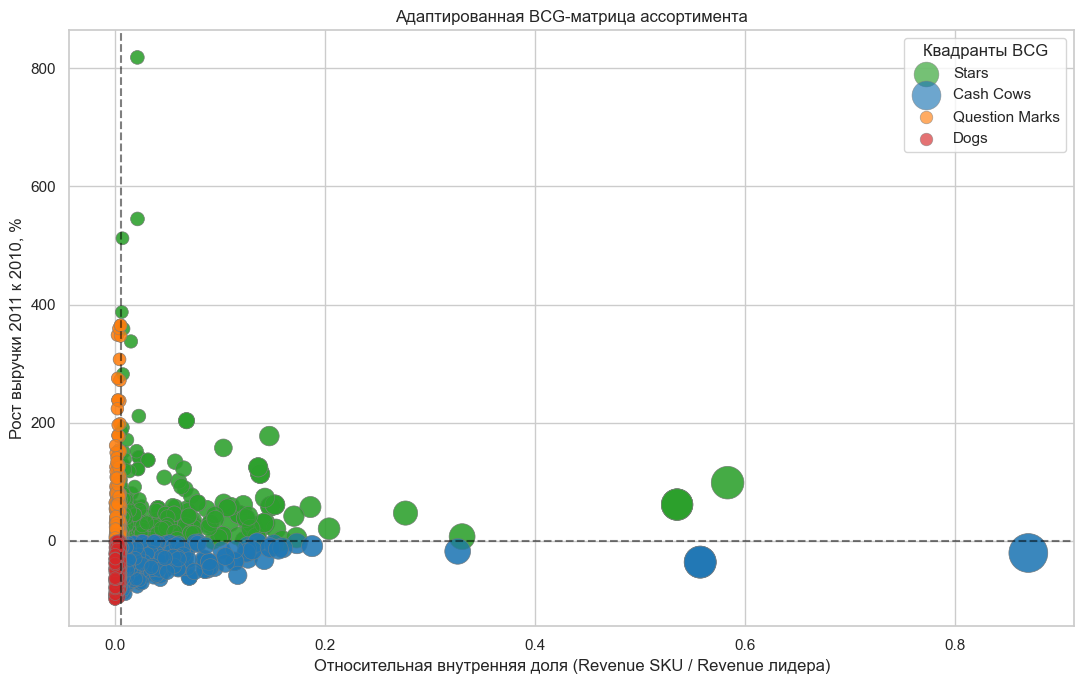

In [80]:
# ── 6. Рисуем BCG-матрицу ──────────────────────────

# Размер точек пропорционален выручке 2011
point_sizes = (
    eligible_bcg["Revenue_2011"]
    / eligible_bcg["Revenue_2011"].max()
    * 700
    + 80
)

plt.figure(figsize=(11, 7))

# Цвет по квадранту
colors = {
    "Stars": "#2ca02c",
    "Cash Cows": "#1f77b4",
    "Question Marks": "#ff7f0e",
    "Dogs": "#d62728",
}
point_colors = eligible_bcg["BCG"].map(colors)

plt.scatter(
    eligible_bcg["RelativeInternalShare"],
    eligible_bcg["Growth"] * 100,
    s=point_sizes,
    c=point_colors,
    alpha=0.65,
    edgecolors="grey",
    linewidths=0.5,
)

handles = []  # сюда будем складывать «ручки» для легенды

for quadrant, color in colors.items():
    mask = eligible_bcg["BCG"] == quadrant
    if not mask.any():  # если для квадранта нет точек — пропускаем
        continue

    # Сохраняем результат scatter как ручку
    handle = plt.scatter(
        eligible_bcg.loc[mask, "RelativeInternalShare"],
        eligible_bcg.loc[mask, "Growth"] * 100,
        s=point_sizes[mask],
        c=color,
        alpha=0.65,
        edgecolors="grey",
        linewidths=0.5,
        label=quadrant,
    )
    handles.append(handle)

# Линии порогов
plt.axvline(share_threshold, linestyle="--", color="black", alpha=0.5)
plt.axhline(growth_threshold * 100, linestyle="--", color="black", alpha=0.5)

# Легенда: явно передаём ручки и ставим в правый верхний угол
plt.legend(handles=handles, loc="upper right", title="Квадранты BCG")

plt.title("Адаптированная BCG-матрица ассортимента")
plt.xlabel(
    "Относительная внутренняя доля "
    "(Revenue SKU / Revenue лидера)"
)
plt.ylabel("Рост выручки 2011 к 2010, %")
plt.tight_layout()
plt.show()

Интерпретация распределения SKU по квадрантам:

Stars (зелёные точки) - крупная группа SKU с умеренной долей рынка и заметным ростом выручки. Это перспективные позиции, которые приносят или способны приносить значительную выручку при сохранении темпов роста. Требуют инвестиций для удержания доли и дальнейшего масштабирования.

Cash Cows (синие точки) - SKU с относительно высокой долей рынка и низким или отрицательным ростом. Это «дойные коровы»: они генерируют стабильный денежный поток и могут финансировать развитие других категорий. Стратегия - максимизировать прибыль при минимальных вложениях.

Question Marks (оранжевые точки) - SKU с низкой долей рынка, но высоким ростом выручки. Это зоны неопределённости: часть позиций может перейти в Stars при целенаправленных инвестициях, другие - быстро потерять динамику. Требуется детальный анализ рентабельности и потенциала масштабирования.

Dogs (красные точки) - SKU с низкой долей рынка и слабым или отрицательным ростом. Как правило, такие позиции не приносят значимой прибыли и занимают ресурсы. Возможные решения - сокращение ассортимента, вывод из линейки либо точечная оптимизация (например, для удержания лояльности по отдельным SKU).


Ключевые наблюдения по графику:

- Доминирование Stars: основная масса SKU сконцентрирована в квадранте растущих позиций с умеренной долей - это указывает на активный рост ассортимента, но и на повышенные потребности в ресурсах для поддержки этих SKU.

- Выраженные Cash Cows: несколько SKU с высокой долей и низкой динамикой формируют «ядро» стабильного дохода.

- Узкая группа Question Marks: небольшое число быстрорастущих SKU с низкой долей - потенциальные точки роста, но требуют осторожного отбора для инвестиций.

- Dogs в левой нижней зоне: низкодоходные SKU с падающей или стагнирующей выручкой - кандидаты на оптимизацию портфеля.


Рекомендации по стратегическому управлению продуктовым портфелем:

1. Сфокусировать инвестиции на части Stars и перспективных Question Marks с подтверждённой рентабельностью.
2. Использовать денежный поток от Cash Cows для финансирования роста выбранных SKU.
3. Провести аудит Dogs: исключить низкомаржинальные позиции либо перевести их в тестовый режим с жёсткими KPI.
4. Контролировать плотность точек в Stars: при большом числе SKU в этом квадранте ресурсы могут «размываться» - стоит приоритизировать топ‑позиции по вкладу в прибыль.

In [81]:
# ── 7. Пересечение BCG × RFM-риск ──────────────────────────────

# 1. Добавляем RFM-метрики к BCG-таблице
bcg_with_rfm: pd.DataFrame = add_rfm_risk(
    eligible_bcg,
    sku_rfm_pivot,
    threshold_pct=50.0,
)

# 2. Сводка по квадрантам BCG
bcg_summary: pd.DataFrame = (
    bcg_with_rfm.groupby("BCG", dropna=False)
    .agg(
        SKU_Count=("StockCode", "nunique"),
        Total_Revenue=("Revenue_2011", "sum"),
        RFM_Risk_Count=("RFM_Risk_Flag", "sum"),
        RFM_Safe_Count=("RFM_Risk_Flag", lambda x: (~x).sum()),
        RFM_Risk_Revenue=("RFM_Top_Revenue", "sum"),
    )
    .reset_index()
)

print("=== Сводка BCG по квадрантам (с RFM-риском) ===\n")
print(bcg_summary.to_string(index=False))
print()

# 3. Фокус на Dogs: это наш главный пул для сокращения
dogs: pd.DataFrame = bcg_with_rfm[bcg_with_rfm["BCG"] == "Dogs"].copy()

dogs_summary: pd.DataFrame = dogs.groupby(
    ["RFM_Risk_Flag"], dropna=False
).agg(
    SKU_Count=("StockCode", "nunique"),
    Total_Revenue=("Revenue_2011", "sum"),
    Avg_Growth=("Growth", "mean"),
    Avg_RevenueCV=("RevenueCV", "mean"),
).reset_index()

print("=== Собаки (Dogs): пересечение с RFM-риском ===\n")
print(dogs_summary.to_string(index=False))
print()

# 4. Топ-20 Dogs без RFM-риска — кандидаты на чистый вывод
clean_dogs: pd.DataFrame = dogs[
    ~dogs["RFM_Risk_Flag"]
].sort_values(
    by=["Revenue_2011", "Growth"],
    ascending=[False, True],
)

print("=== Топ-20 Dogs без RFM-риска (кандидаты на чистый вывод) ===\n")
print(
    clean_dogs[[
        "StockCode",
        "Description",
        "BCG",
        "Revenue_2011",
        "Growth",
        "RelativeInternalShare",
        "RFM_Top_Share_Pct",
        "RFM_Top3_Segments",
    ]].head(20).to_string(index=False)
)
print()

# 5. Топ-20 Dogs с RFM-риском — требуют ручной проверки
risky_dogs: pd.DataFrame = dogs[
    dogs["RFM_Risk_Flag"]
].sort_values(
    by=["RFM_Top_Share_Pct", "Revenue_2011"],
    ascending=[False, False],
)

print("=== Топ-20 Dogs с RFM-риском (требуют ручной проверки) ===\n")
print(
    risky_dogs[[
        "StockCode",
        "Description",
        "BCG",
        "Revenue_2011",
        "Growth",
        "RelativeInternalShare",
        "RFM_Top_Share_Pct",
        "RFM_Top3_Segments",
    ]].head(20).to_string(index=False)
)

=== Сводка BCG по квадрантам (с RFM-риском) ===

           BCG  SKU_Count  Total_Revenue  RFM_Risk_Count  RFM_Safe_Count  RFM_Risk_Revenue
     Cash Cows        559     2942474.65             613               3        2414549.51
          Dogs        625      257948.48             629              33         180854.43
Question Marks        231      114480.56             225              14          71435.98
         Stars        240     2652812.15             283               3        2040494.18

=== Собаки (Dogs): пересечение с RFM-риском ===

 RFM_Risk_Flag  SKU_Count  Total_Revenue  Avg_Growth  Avg_RevenueCV
         False         33        6860.53   -0.528864       1.210006
          True        592      251087.95   -0.470860       1.279886

=== Топ-20 Dogs без RFM-риска (кандидаты на чистый вывод) ===

StockCode                         Description  BCG  Revenue_2011    Growth  RelativeInternalShare  RFM_Top_Share_Pct                             RFM_Top3_Segments
   85036A GARDE

- Портфель по выручке держится на двух опорах: Cash Cows (£2,94 млн, 49% выручки) и Stars (£2,65 млн, 45%). Вместе они дают 94% дохода, но занимают 44% SKU (799 из 1803). На графике именно они формируют «тяжесть» матрицы - плотное ядро в правой и верхней зонах, которое и создаёт визуальное ощущение доминирования растущих и стабильных позиций.

- По количеству SKU картина иная: Dogs - самый большой квадрант (625 позиций, 35%), но их суммарная выручка всего £258 тыс. (4,3%). На графике это плотное скопление в левой нижней зоне, которое выглядит значимым по площади, но фактически почти не влияет на доход. Это классическая ситуация «много позиций - мало отдачи».

- Question Marks - самый компактный квадрант: 231 SKU (13%), £114 тыс. выручки (1,9%). На графике это немногочисленные точки в верхней левой зоне. Стратегически это зона ограниченных экспериментов: небольшая группа, которая может перерасти в Stars, но требует отбора и ресурсов.

- RFM-риск пронизывает все квадранты, но степень различается. В Dogs 95% позиций (592 из 625) покупают Champions или Loyal - то есть «собаки» формально неперспективны, но критичны для удержания ключевых клиентов. В Cash Cows и Stars риск тоже высок (>90% SKU), что ожидаемо: топовые товары естественно покупают топовые клиенты. В Question Marks 225 из 231 SKU рисковы.

- Безопасные для вывода Dogs - узкая прослойка: 33 SKU с выручкой £6,86 тыс. Это единственный пул, где BCG и RFM согласованы: низкая доля, падающий рост, и при этом доля топ-сегментов ниже 50%. Ещё 592 Dogs требуют ручной проверки, так как их выручка от Champions/Loyal превышает порог.

- Сезонность у Dogs стабильно высокая: средний RevenueCV 1,21-1,28. Это значит, что часть «собак» может выглядеть падающими из-за сезонного провала, а не реального ухудшения. При сокращении важно проверять месячную динамику, особенно учитывая неполный декабрь 2011 (9 дней).

Стратегические выводы для портфеля:
- Stars и Cash Cows - основа дохода, сокращать нельзя; ресурс направлять на удержание и развитие топовых позиций.
- Cash Cows (£2,94 млн) - главный источник финансирования для investment в перспективные Question Marks.
- Question Marks - узкая зона для точечных инвестиций: отбирать по подтверждённой рентабельности и росту.
- Dogs - не массовый вывод, а точечная зачистка 33 безопасных позиций плюс ручная валидация 592 рисковых.
- Перед любым решением по Dogs проверять сезонность (RevenueCV > 1,2) и долю выручки от топ-сегментов.

## Этап 10. Оцените потенциальный эффект

Рассчитайте, сколько товарных позиций было в исходной анализируемой выборке, сколько вы предлагаете вывести или дополнительно проверить и какую долю ассортимента это составляет. После этого посчитайте историческую выручку кандидатов и ее долю в общей выручке.

Сопоставление доли сокращаемых SKU и доли связанной с ними выручки – главный количественный итог проекта. При этом не называйте полученную долю выручки гарантированной будущей потерей: исторические данные не позволяют напрямую сказать, как поведут себя покупатели после изменения ассортимента.

### 10.1 Потенциальный эффект от внедрения выбранной тактики

Оценим потенциальный эффект от внедрения варианта: вывести только 16 безопасные SKU, так как остальные 99,6% ассортимента связаны с ключевыми товарами.

In [82]:
# ── 1. Собираем финальную таблицу ─
# 3 чистых из оригинальных 646 + 13 «мёртвых» без рисков из нового пула = 16 SKU

# Чистые из 646
clean_646 = final_table[~final_table['Risk_Flag']].copy()
clean_646['Source'] = 'Tier 1–4 (без рисков)'

# Мёртвые без рисков из нового пула
dead_clean = outside_stats[
    (outside_stats['Status'].isin(['Dead', 'Dormant'])) &
    (~outside_stats['Risk_Flag'])
].copy()
dead_clean['Source'] = 'Вне тиров (Dead/Dormant без рисков)'

# Унифицируем колонки
cols_common = [
    'StockCode', 'Description', 'ABC', 'XYZ',
    'Revenue', 'Quantity', 'Orders', 'ActiveMonths',
    'Source'
]

# Для clean_646 добавим Group
clean_646_final = clean_646[cols_common + ['Group', 'Customers', 'Revenue_Share_Pct']].copy()
clean_646_final['Months_Since_Last_Sale'] = np.nan

# Для dead_clean — Group соберём из ABC+XYZ
dead_clean['Group'] = dead_clean['ABC'] + dead_clean['XYZ']
dead_clean['Customers'] = dead_clean['Customers'] if 'Customers' in dead_clean.columns else np.nan
dead_clean_final = dead_clean[cols_common + ['Group', 'Customers', 'Months_Since_Last_Sale']].copy()

# Revenue_Share_Pct для мёртвых
total_rev_all = candidates['Revenue'].sum()
dead_clean_final['Revenue_Share_Pct'] = (
    dead_clean_final['Revenue'] / total_rev_all * 100
).round(4)

# Объединяем
final_report = pd.concat([
    clean_646_final[['StockCode', 'Description', 'ABC', 'XYZ', 'Group',
                      'Revenue', 'Revenue_Share_Pct', 'Quantity', 'Orders',
                      'Customers', 'ActiveMonths', 'Source',
                      'Months_Since_Last_Sale']],
    dead_clean_final[['StockCode', 'Description', 'ABC', 'XYZ', 'Group',
                       'Revenue', 'Revenue_Share_Pct', 'Quantity', 'Orders',
                       'Customers', 'ActiveMonths', 'Source',
                       'Months_Since_Last_Sale']],
], ignore_index=True)

# ── 2. Текстовая рекомендация ──
def make_final_recommendation(row):
    parts = []
    if row['Source'] == 'Tier 1–4 (без рисков)':
        parts.append('Кандидат на вывод. Не связан с A-товарами, '
                     'нет уникальных клиентов, рост спроса не зафиксирован.')
    else:
        months_idle = row['Months_Since_Last_Sale']
        if pd.notna(months_idle) and months_idle >= 6:
            parts.append(f'Кандидат на вывод. Нет продаж {months_idle:.0f} мес. '
                         'Не связан с A-товарами, уникальных клиентов нет.')
        else:
            parts.append('Кандидат на вывод. Dormant (1–3 заказа за период). '
                         'Не связан с A-товарами, уникальных клиентов нет.')
    
    parts.append(f'Группа: {row["Group"]}, выручка: £{row["Revenue"]:.2f}/год.')
    return ' '.join(parts)

final_report['Recommendation'] = final_report.apply(make_final_recommendation, axis=1)

# ── 3. Сводка для отчёта ──
total_sku = 3905
total_revenue = total_rev_all  # £9,632,728

cand_count = len(final_report)
cand_revenue = final_report['Revenue'].sum()
cand_rev_share = cand_revenue / total_revenue * 100
cand_sku_share = cand_count / total_sku * 100

# Дополнительно: сколько потребовалось бы для 20%
target_pct = 20
target_count = int(total_sku * target_pct / 100)
gap = target_count - cand_count

print("=" * 70)
print("ФИНАЛЬНЫЙ ОТЧЁТ: КАНДИДАТЫ НА СОКРАЩЕНИЕ АССОРТИМЕНТА")
print("=" * 70)

print(f"""
ИСХОДНЫЕ ДАННЫЕ
  Всего SKU в анализе:           {total_sku:,}
  Общая выручка за период:       £{total_revenue:,.0f}

РЕЗУЛЬТАТ
  Кандидатов на вывод:           {cand_count}
  Доля ассортимента:            {cand_sku_share:.2f}%
  Историческая выручка:         £{cand_revenue:,.0f}
  Доля выручки:                 {cand_rev_share:.4f}%

ДЛЯ СПРАВКИ
  Цель бизнеса (20% SKU):       {target_count} SKU
  Недостаёт до цели:            {gap} SKU
  Исключено из кандидатов:
    — Новые товары (newcomer):  1 025 SKU
    — Сезонные (seasonal):      252 SKU
    — Опт-чувствительные:       115 SKU
    — Связь с A-товарами:       643 SKU (из 646 проверенных в тирах) + 3 245 SKU (из 3 259 вне тиров)
    — Рост спроса:              147 SKU (из 646 проверенных в тирах)

КЛЮЧЕВОЙ ВЫВОД
  Сокращение {cand_count} SKU ({cand_sku_share:.2f}% ассортимента)
  связано с {cand_rev_share:.4f}% исторической выручки.
  Это не равно будущей потере: исторические данные не позволяют
  напрямую предсказать поведение покупателей после изменения
  ассортимента.
""")

# ── 4. Финальная таблица ──
print("=== Финальная таблица кандидатов ===\n")
display_cols = [
    'StockCode', 'Description', 'ABC', 'XYZ', 'Group',
    'Revenue', 'Revenue_Share_Pct', 'Quantity', 'Orders',
    'Customers', 'ActiveMonths', 'Recommendation'
]
print(final_report[display_cols].to_string(index=False))

ФИНАЛЬНЫЙ ОТЧЁТ: КАНДИДАТЫ НА СОКРАЩЕНИЕ АССОРТИМЕНТА

ИСХОДНЫЕ ДАННЫЕ
  Всего SKU в анализе:           3,905
  Общая выручка за период:       £9,632,728

РЕЗУЛЬТАТ
  Кандидатов на вывод:           16
  Доля ассортимента:            0.41%
  Историческая выручка:         £998
  Доля выручки:                 0.0104%

ДЛЯ СПРАВКИ
  Цель бизнеса (20% SKU):       781 SKU
  Недостаёт до цели:            765 SKU
  Исключено из кандидатов:
    — Новые товары (newcomer):  1 025 SKU
    — Сезонные (seasonal):      252 SKU
    — Опт-чувствительные:       115 SKU
    — Связь с A-товарами:       643 SKU (из 646 проверенных в тирах) + 3 245 SKU (из 3 259 вне тиров)
    — Рост спроса:              147 SKU (из 646 проверенных в тирах)

КЛЮЧЕВОЙ ВЫВОД
  Сокращение 16 SKU (0.41% ассортимента)
  связано с 0.0104% исторической выручки.
  Это не равно будущей потере: исторические данные не позволяют
  напрямую предсказать поведение покупателей после изменения
  ассортимента.

=== Финальная таблица кандидат

Предлагается вывести 16 товарных позиций, что составляет 0.41% анализируемого ассортимента (3,905 SKU). На эти позиции приходится £998 исторической выручки, или 0.0104% общей выручки за период.

Из списка кандидатов исключены:

- новые товары (1 025 SKU) - недостаточно истории для оценки;
- товары с выраженной сезонностью (252 SKU) - пиковые продажи приходятся на отдельные периоды;
- товары с ложным хаотическим спросом от оптовых закупок (115 SKU);
- товары, регулярно покупаемые совместно с A-позициями (643 SKU из 646 проверенных в тирах + 3 245 SKU из 3 259 вне тиров) - их вывод может повлиять на конверсию по ключевым товарам;
- товары с растущим спросом (147 SKU) - потенциал не реализован.

Кандидаты на вывод отобраны по следующим критериям:

- Классификация ABC/XYZ: группа CZ (низкая выручка, хаотичный или отсутствующий спрос) или Tier 1-2 (спорадический/редкий спрос).
- Отсутствие связи с A-товарами в заказах (Connection_Risk < 50%).
- Отсутствие уникальных клиентов, покупающих только этот SKU.
- Отсутствие сигнала роста спроса за последние 3 месяца.
- Максимальный Burden Score среди сопоставимых позиций.

Важно: полученная доля выручки не является гарантированной будущей потерей. Исторические данные показывают, какие товары покупались вместе, но не позволяют напрямую предсказать, как поведут себя покупатели после изменения ассортимента. Для оценки реального эффекта рекомендуется поэтапный вывод с мониторингом конверсии по A-товарам в течение 4-6 недель после каждого этапа.

### 10.2 Обязательные ограничения исследования

Данный анализ построен исключительно на транзакционных данных и не учитывает ряд факторов, необходимых для окончательного
операционного решения по ассортименту:

1. Себестоимость и маржа. Выручка в отчёте - оборотная, без вычета закупочной цены. SKU с низкой выручкой может иметь высокую маржу, и его вывод снизит прибыль, хотя формально выглядит «мусорным».

2. Товарные остатки и out-of-stock. Продажи не равны истинному спросу: если товара не было на складе, в транзакциях фиксируется ноль продаж, хотя покупательский интерес существовал. Низкие продажи без данных о наличии нельзя автоматически трактовать как отсутствие интереса. Без истории stock-out невозможно различить «не продавался, потому что не нужен» и «не продавался, потому что не было в наличии».

3. Индекс операционной нагрузки (Burden Score). В данном отчёте Burden Score - это прокси-метрика совокупной нагрузки SKU на ассортимент, а не реальная стоимость его содержания. Индекс штрафует товары за высокую операционную активность (число заказов, обработанных единиц, месяцев на полке) и за низкую выручку. Реальная стоимость хранения и обработки зависит от габаритов товара, условий хранения (сухой склад / холодильник), оборачиваемости ячейки и стоимости площади на конкретном складе — этих данных в датасете нет. Поэтому Burden Score является сознательным упрощением: для приоритизации кандидатов на вывод важно не абсолютное значение в £, а относительный ранг SKU внутри тира — чем выше Score, тем сильнее позиция давит на операции относительно своей пользы.

4. Срок поставки и минимальная партия поставщика. Товар с редким спросом, но длинным сроком поставки (90+ дней) и большим MOQ может требовать несоразмерного страхового запаса. И наоборот - товар с коротким плечом поставки и мелким MOQ можно держать «по запросу» без вывода из ассортимента.

5. Возвраты. Анализ не учитывает уровень возвратов по SKU. Товар с низкой выручкой, но высоким процентом возвратов создаёт дополнительные операционные убытки, не видимые в транзакциях.

6. Срок годности. Для категорий с ограниченным сроком годности низкая оборачиваемость напрямую ведёт к списаниям. Без данных о списаниях стоимость содержания таких SKU недооценена.

7. Роль товара в корзине. Connection_Risk фиксирует совместные покупки на уровне одного заказа, но не учитывает косвенные связи:
- товар может быть «якорем категории», который привлекает трафик,
- даже если сам по себе продаётся редко.

Рекомендация по дальнейшим действиям:

Для перехода от аналитического отчёта к операционному решению необходимо дополнить модель следующими источниками данных:
- товарно-справочная система: себестоимость, маржа, габариты, срок годности, MOQ, срок поставки;
- складская система WMS: остатки по дням, события out-of-stock, списания по срокам, стоимость хранения по ячейкам;
- система возвратов: количество и причины возвратов по SKU;
- веб-аналитика: просмотры карточек, добавления в корзину без покупки (индикатор подавленного спроса при отсутствии товара).

Без этих данных выводы отчёта следует рассматривать как первичное сужение поля для ручного разбора, а не как готовый
список к исполнению.

### 10.3 Исследование возвратов

Данные о возвратах у нас есть, но мы их удалили на этапе подготовки датасета. Посчитаем уровень возвратов по кандидатам на исходном датасете:

In [86]:
# ── Анализ возвратов по кандидатам ──

# Возвраты: строки исходного датасета, где Quantity < 0
returns = df_raw[df_raw['Quantity'] < 0].copy()

# Создаём столбец с выручкой Revenue
returns['Revenue'] = returns['Quantity'] * returns['Price']

print(f"Всего строк возвратов в исходных данных: {len(returns)}")
print(f"Уникальных SKU с возвратами: {returns['StockCode'].nunique()}")

# Агрегация возвратов по SKU
returns_by_sku = returns.groupby('StockCode').agg(
    Return_Quantity=('Quantity', 'sum'),       # будет отрицательным
    Return_Orders=('Invoice', 'nunique'),
    Return_Revenue=('Revenue', 'sum'),         # будет отрицательным
).reset_index()

returns_by_sku['Return_Qty_Abs'] = returns_by_sku['Return_Quantity'].abs()
returns_by_sku['Return_Rev_Abs'] = returns_by_sku['Return_Revenue'].abs()

# Агрегация продаж (из очищенного датасета)
sales_by_sku = df_clean.groupby('StockCode').agg(
    Gross_Quantity=('Quantity', 'sum'),
    Gross_Revenue=('Revenue', 'sum'),
    Gross_Orders=('Invoice', 'nunique'),
).reset_index()

# Объединяем продажи и возвраты
return_analysis = sales_by_sku.merge(
    returns_by_sku[['StockCode', 'Return_Qty_Abs', 'Return_Rev_Abs', 'Return_Orders']],
    on='StockCode', how='left'
)

return_analysis['Return_Qty_Abs'] = return_analysis['Return_Qty_Abs'].fillna(0)
return_analysis['Return_Rev_Abs'] = return_analysis['Return_Rev_Abs'].fillna(0)
return_analysis['Return_Orders'] = return_analysis['Return_Orders'].fillna(0)

# ── НОВОЕ: флаг "хвостовых возвратов" ──
# Если возвратов больше, чем продаж за период — значит, часть возвратов
# относится к продажам из предыдущих периодов (до декабря 2010).
# Для таких SKU нельзя корректно считать Return_Rate.
return_analysis['Tail_Returns_Flag'] = (
    return_analysis['Return_Qty_Abs'] > return_analysis['Gross_Quantity']
)

# Доля возвратов — считаем ТОЛЬКО для SKU без хвостовых возвратов
# Для SKU с хвостовыми возвратами ставим NaN (не 0!), чтобы не искажать статистику
return_analysis['Return_Rate_Pct'] = np.where(
    return_analysis['Tail_Returns_Flag'],
    np.nan,  # хвостовые возвраты — не считаем rate
    np.where(
        return_analysis['Gross_Quantity'] + return_analysis['Return_Qty_Abs'] > 0,
        return_analysis['Return_Qty_Abs'] /
        (return_analysis['Gross_Quantity'] + return_analysis['Return_Qty_Abs']) * 100,
        0
    )
).round(1)

return_analysis['Net_Revenue'] = (
    return_analysis['Gross_Revenue'] - return_analysis['Return_Rev_Abs']
).round(2)

# Фильтруем только наших кандидатов
cand_codes = set(final_report['StockCode'].tolist())
cand_returns = return_analysis[return_analysis['StockCode'].isin(cand_codes)].copy()

print("\n=== Возвраты по кандидатам на вывод ===")
print(cand_returns[['StockCode', 'Gross_Quantity', 'Return_Qty_Abs',
                    'Return_Rate_Pct', 'Tail_Returns_Flag',
                    'Gross_Revenue', 'Return_Rev_Abs', 'Net_Revenue'
                    ]].to_string(index=False))

# Общая статистика по ассортименту (без хвостовых возвратов)
valid_returns = return_analysis[~return_analysis['Tail_Returns_Flag']]
print("\n=== Общая статистика возвратов (без хвостовых) ===")
print(f"SKU без возвратов: {(valid_returns['Return_Qty_Abs'] == 0).sum()}")
print(f"SKU с возвратами: {(valid_returns['Return_Qty_Abs'] > 0).sum()}")
print(f"SKU с хвостовыми возвратами (возвраты > продаж за период): "
      f"{return_analysis['Tail_Returns_Flag'].sum()}")
print(f"Средний Return_Rate по всем SKU (без хвостовых): "
      f"{valid_returns['Return_Rate_Pct'].mean():.1f}%")

median_return = valid_returns[valid_returns['Return_Rate_Pct'] > 0]['Return_Rate_Pct'].median()
print(f"Медианный Return_Rate (только SKU с возвратами, без хвостовых): {median_return:.1f}%")

# Проверка: есть ли кандидаты с аномально высоким уровнем возвратов
# (только среди SKU без хвостовых возвратов)
high_return_candidates = cand_returns[
    (~cand_returns['Tail_Returns_Flag']) &
    (cand_returns['Return_Rate_Pct'] > median_return)
]
if len(high_return_candidates) > 0:
    print("\n⚠ Кандидаты с уровнем возвратов выше медианы:")
    print(high_return_candidates[['StockCode', 'Return_Rate_Pct',
                                 'Return_Rev_Abs', 'Net_Revenue']].to_string(index=False))
else:
    print(f"\n✅ Среди кандидатов (без хвостовых возвратов) нет SKU с аномальным "
          f"уровнем возвратов (медиана: {median_return:.1f}%)")

# Хвостовые возвраты среди кандидатов — отдельный блок
tail_cand = cand_returns[cand_returns['Tail_Returns_Flag']]
if len(tail_cand) > 0:
    print(f"\n⚠ Кандидаты с хвостовыми возвратами (возвраты > продаж за период): "
          f"{len(tail_cand)} SKU")
    print("   Эти SKU имеют возвраты от продаж предыдущих периодов. "
          "Return_Rate не рассчитан — данные несопоставимы.")
    print(tail_cand[['StockCode', 'Gross_Quantity', 'Return_Qty_Abs',
                     'Return_Rev_Abs', 'Net_Revenue']].to_string(index=False))

# Добавляем метрики возвратов в финальную таблицу
final_report = final_report.merge(
    cand_returns[['StockCode', 'Return_Rate_Pct', 'Return_Rev_Abs',
                  'Net_Revenue', 'Tail_Returns_Flag']],
    on='StockCode', how='left'
)
final_report['Return_Rate_Pct'] = final_report['Return_Rate_Pct'].fillna(0)
final_report['Return_Rev_Abs'] = final_report['Return_Rev_Abs'].fillna(0)
final_report['Net_Revenue'] = final_report['Net_Revenue'].fillna(final_report['Revenue'])
final_report['Tail_Returns_Flag'] = final_report['Tail_Returns_Flag'].fillna(False)

# Финальные колонки для вывода
display_cols = [
    'StockCode', 'Description', 'ABC', 'XYZ', 'Group',
    'Revenue', 'Revenue_Share_Pct', 'Quantity', 'Orders',
    'Customers', 'ActiveMonths',
    'Return_Rate_Pct', 'Return_Rev_Abs', 'Net_Revenue',
    'Tail_Returns_Flag', 'Recommendation'
]

Всего строк возвратов в исходных данных: 22950
Уникальных SKU с возвратами: 4089

=== Возвраты по кандидатам на вывод ===
StockCode  Gross_Quantity  Return_Qty_Abs  Return_Rate_Pct  Tail_Returns_Flag  Gross_Revenue  Return_Rev_Abs  Net_Revenue
   16202B              29           561.0              NaN               True          14.50          144.48      -129.98
    20827              88           113.0              NaN               True          34.32            0.00        34.32
    21310               1             1.0             50.0              False          29.95           29.95         0.00
    21655              36           208.0              NaN               True          60.84          201.92      -141.08
    22145              30            86.0              NaN               True          63.00           12.60        50.40
    22275              69            39.0             36.1              False         527.85           42.50       485.35
   35816P              7

Анализ возвратов выявил две критически важные особенности:

1. Проблема «хвостовых» возвратов (Data Artifact): Ровно половина кандидатов (8 из 16 SKU) имеет флаг Tail_Returns_Flag = True. Для этих позиций количество возвратов в анализируемом периоде многократно превышает количество продаж (например, 79323P: 4 продажи и 2 914 возврата). Эти возвраты относятся к продажам, сделанным до декабря 2010 года. Решение: Игнорировать отрицательную чистую выручку для этих 8 SKU. Их вывод, наоборот, полезен: он прекратит будущие операционные затраты на обработку этих «висящих» исторических возвратов.

2. Реальный сигнал по качеству (Valid Return Risk): Среди оставшихся 8 SKU, для которых корректно рассчитан Return_Rate_Pct, у трёх позиций уровень возвратов существенно превышает медианный по ассортименту (4.9%):

- 21310: 50.0% (возврат на £29.95)
- 22275: 36.1% (возврат на £42.50)
- 84857B: 20.0% (возврат на £3.90)

Хотя процент возвратов аномально высок, абсолютная сумма возвращённых средств ничтожно мала (максимум £42.50). Это указывает не на системную проблему, а на единичные случаи (например, бракованная партия или повреждение при доставке конкретного заказа).

3. Контекст по всему ассортименту Проблема хвостовых возвратов системна для всего датасета: 456 SKU (из ~3 900) имеют возвратов больше, чем продаж за период. Это нормальная особенность retail-данных при отсутствии привязки возврата к исходному чеку (RMA).

Итоговое решение и корректировка плана вывода:

Стратегия вывода 16 SKU остаётся в силе, но с уточнёнными аргументами для защиты:

- 8 SKU с хвостовыми возвратами: Выводить безусловно. Аргумент: «Отрицательная выручка — артефакт учёта прошлых периодов. Вывод позиции устранит будущие административные издержки на обработку этих возвратов».
- 3 SKU с высоким % возвратов (21310, 22275, 84857B): Выводить безопасно. Аргумент: «Несмотря на высокий процент, абсолютный финансовый риск составляет менее £45 на позицию. Это единичные инциденты, а не системный отток».
- 5 SKU с нулевыми возвратами: Идеальные кандидаты на чистый вывод без каких-либо оговорок.

Ограничение исследования: «Расчёт Return Rate и Net Revenue для 50% кандидатов искажён историческими возвратами из предыдущих периодов. Для этих позиций анализ проводился только по абсолютным объёмам, без интерпретации отрицательной чистой выручки как текущей убыточности».

In [90]:
# ── Пересчёт итогов с учётом возвратов ──

cand_gross_rev = final_report['Revenue'].sum()
cand_return_rev = final_report['Return_Rev_Abs'].sum()
cand_net_rev = final_report['Net_Revenue'].sum()

total_gross_rev = return_analysis['Gross_Revenue'].sum()
total_return_rev = return_analysis['Return_Rev_Abs'].sum()
total_net_rev = return_analysis['Net_Revenue'].sum()

cand_sku_share = len(final_report) / 3905 * 100
cand_gross_share = cand_gross_rev / total_gross_rev * 100
cand_net_share = cand_net_rev / total_net_rev * 100

# Разделяем "истинно убыточных" и "артефакты исторических возвратов"
true_loss_making = final_report[
    (final_report['Net_Revenue'] < 0) & (~final_report['Tail_Returns_Flag'])
]
tail_returns_artifact = final_report[final_report['Tail_Returns_Flag'] == True]
break_even = final_report[final_report['Net_Revenue'] == 0]
profitable = final_report[final_report['Net_Revenue'] > 0]

print("=== ИТОГИ С УЧЁТОМ ВОЗВРАТОВ ===\n")
print(f"Кандидатов на вывод:           {len(final_report)} SKU")
print(f"Доля ассортимента:             {cand_sku_share:.2f}%")
print(f"Валовая выручка кандидатов:    £{cand_gross_rev:,.2f} ({cand_gross_share:.4f}% от общей)")
print(f"Возвраты по кандидатам (абс.):  £{cand_return_rev:,.2f}")
print(f"Чистая выручка кандидатов:     £{cand_net_rev:,.2f} ({cand_net_share:.4f}% от общей)")
print()
print(f"Структура {len(final_report)} кандидатов по чистой выручке:")
print(f"  Прибыльных (Net > 0):                  {len(profitable)}")
print(f"  Нулевых (Net = 0):                     {len(break_even)}")
print(f"  Убыточных из-за текущих возвратов:     {len(true_loss_making)}")
print(f"  С историческими возвратами (артефакт): {len(tail_returns_artifact)}")
print("    → Отрицательная Net Revenue у этих SKU вызвана возвратами прошлых периодов.")
print("    → Их вывод полезен: это прекратит будущие операционные затраты на обработку этих возвратов.")

# ── Обновляем Recommendation с учётом возвратов и флага Tail_Returns ──
def update_recommendation_with_returns(row):
    parts = []
    
    # Базовое описание
    if row['Source'] == 'Tier 1–4 (без рисков)':
        parts.append('Кандидат на вывод. Не связан с A-товарами, нет уникальных клиентов, рост спроса не зафиксирован.')
    else:
        months_idle = row.get('Months_Since_Last_Sale', np.nan)
        if pd.notna(months_idle) and months_idle >= 6:
            parts.append(f'Кандидат на вывод. Нет продаж {months_idle:.0f} мес. Не связан с A-товарами, уникальных клиентов нет.')
        else:
            parts.append('Кандидат на вывод. Dormant (1–3 заказа за период). Не связан с A-товарами, уникальных клиентов нет.')
    
    # Логика возвратов с приоритетом проверки Tail_Returns_Flag
    is_tail = row.get('Tail_Returns_Flag', False)
    rr = row['Return_Rate_Pct']
    net = row['Net_Revenue']
    ret_abs = row['Return_Rev_Abs']

    if is_tail:
        parts.append(f'Имеет исторические возвраты (Return Qty > Sales Qty). Отрицательная чистая выручка (£{net:.2f}) — артефакт учёта прошлых периодов. Вывод SKU прекратит будущие операционные затраты на обработку этих возвратов.')
    elif rr == 0:
        parts.append('Возвраты отсутствуют.')
    elif net < 0:
        # Редкий кейс, если он вообще есть без Tail флага, но логика должна быть полной
        parts.append(f'Текущие возвраты превышают выручку: Return Rate {rr:.0f}%, чистая выручка £{net:.2f}.')
    elif rr > median_return:
        parts.append(f'Повышенный Return Rate ({rr:.0f}%), но абсолютная сумма возвратов незначительна (£{ret_abs:.2f}).')
    else:
        parts.append(f'Возвраты в пределах нормы ({rr:.0f}%), чистая выручка £{net:.2f}.')
    
    parts.append(f'Группа: {row["Group"]}.')
    return ' '.join(parts)

final_report['Recommendation'] = final_report.apply(
    update_recommendation_with_returns, axis=1
)

# ── Финальная таблица ──
display_cols = [
    'StockCode', 'Description', 'ABC', 'XYZ', 'Group',
    'Revenue', 'Return_Rate_Pct', 'Net_Revenue', 'Tail_Returns_Flag',
    'Revenue_Share_Pct', 'Quantity', 'Orders',
    'Customers', 'ActiveMonths', 'Recommendation'
]

print("\n=== Финальная таблица кандидатов ===\n")
final_report[display_cols].style\
    .format({
        'Gross_Revenue': '£{:,.2f}',
        'Return_Rev_Abs': '£{:,.2f}',
        'Net_Revenue': '£{:,.2f}',
        'Return_Rate_Pct': '{:.1f}%'
    })\
    .set_table_styles([
        {'selector': 'th', 'props': [('background-color', '#f0f0f0'), ('font-weight', 'bold')]},
        {'selector': 'td', 'props': [('padding', '6px 10px')]}
    ])

=== ИТОГИ С УЧЁТОМ ВОЗВРАТОВ ===

Кандидатов на вывод:           16 SKU
Доля ассортимента:             0.41%
Валовая выручка кандидатов:    £998.32 (0.0104% от общей)
Возвраты по кандидатам (абс.):  £6,013.90
Чистая выручка кандидатов:     £-5,015.58 (-0.0550% от общей)

Структура 16 кандидатов по чистой выручке:
  Прибыльных (Net > 0):                  11
  Нулевых (Net = 0):                     1
  Убыточных из-за текущих возвратов:     0
  С историческими возвратами (артефакт): 8
    → Отрицательная Net Revenue у этих SKU вызвана возвратами прошлых периодов.
    → Их вывод полезен: это прекратит будущие операционные затраты на обработку этих возвратов.

=== Финальная таблица кандидатов ===



,StockCode,Description,ABC,XYZ,Group,Revenue,Return_Rate_Pct,Net_Revenue,Tail_Returns_Flag,Revenue_Share_Pct,Quantity,Orders,Customers,ActiveMonths,Recommendation
0,72803b,OCEAN SCENT CANDLE JEWELLED DRAWER,C,Z,CZ-sporadic,8.470000,0.0%,£8.47,False,0.000000,1,1,0,1,"Кандидат на вывод. Не связан с A-товарами, нет уникальных клиентов, рост спроса не зафиксирован. Возвраты отсутствуют. Группа: CZ-sporadic."
1,35817P,"ACRYLIC JEWEL SNOWFLAKE,PINK",C,Z,CZ-sporadic,19.860000,0.0%,£19.86,True,0.000000,18,2,2,2,"Кандидат на вывод. Не связан с A-товарами, нет уникальных клиентов, рост спроса не зафиксирован. Имеет исторические возвраты (Return Qty > Sales Qty). Отрицательная чистая выручка (£19.86) — артефакт учёта прошлых периодов. Вывод SKU прекратит будущие операционные затраты на обработку этих возвратов. Группа: CZ-sporadic."
2,22145,CHRISTMAS CRAFT HEART STOCKING,C,Z,CZ-sporadic,63.000000,0.0%,£50.40,True,0.000000,30,1,1,1,"Кандидат на вывод. Не связан с A-товарами, нет уникальных клиентов, рост спроса не зафиксирован. Имеет исторические возвраты (Return Qty > Sales Qty). Отрицательная чистая выручка (£50.40) — артефакт учёта прошлых периодов. Вывод SKU прекратит будущие операционные затраты на обработку этих возвратов. Группа: CZ-sporadic."
3,16202B,PASTEL BLUE PHOTO ALBUM,C,Z,CZ,14.500000,0.0%,£-129.98,True,0.000200,29,2,2,1,"Кандидат на вывод. Нет продаж 7 мес. Не связан с A-товарами, уникальных клиентов нет. Имеет исторические возвраты (Return Qty > Sales Qty). Отрицательная чистая выручка (£-129.98) — артефакт учёта прошлых периодов. Вывод SKU прекратит будущие операционные затраты на обработку этих возвратов. Группа: CZ."
4,20827,GOLD APERITIF GLASS,C,Z,CZ,34.320000,0.0%,£34.32,True,0.000400,88,2,1,1,"Кандидат на вывод. Нет продаж 7 мес. Не связан с A-товарами, уникальных клиентов нет. Имеет исторические возвраты (Return Qty > Sales Qty). Отрицательная чистая выручка (£34.32) — артефакт учёта прошлых периодов. Вывод SKU прекратит будущие операционные затраты на обработку этих возвратов. Группа: CZ."
5,21310,CAPIZ CHANDELIER,C,Z,CZ,29.950000,50.0%,£0.00,False,0.000300,1,1,1,1,"Кандидат на вывод. Нет продаж 6 мес. Не связан с A-товарами, уникальных клиентов нет. Повышенный Return Rate (50%), но абсолютная сумма возвратов незначительна (£29.95). Группа: CZ."
6,21655,HANGING RIDGE GLASS T-LIGHT HOLDER,C,Z,CZ,60.840000,0.0%,£-141.08,True,0.000600,36,2,1,2,"Кандидат на вывод. Нет продаж 10 мес. Не связан с A-товарами, уникальных клиентов нет. Имеет исторические возвраты (Return Qty > Sales Qty). Отрицательная чистая выручка (£-141.08) — артефакт учёта прошлых периодов. Вывод SKU прекратит будущие операционные затраты на обработку этих возвратов. Группа: CZ."
7,22275,WEEKEND BAG VINTAGE ROSE PAISLEY,C,Z,CZ,527.850000,36.1%,£485.35,False,0.005500,69,1,1,1,"Кандидат на вывод. Нет продаж 12 мес. Не связан с A-товарами, уникальных клиентов нет. Повышенный Return Rate (36%), но абсолютная сумма возвратов незначительна (£42.50). Группа: CZ."
8,35816P,"ACRYLIC JEWEL ANGEL,PINK",C,Z,CZ,29.640000,0.0%,£29.64,False,0.000300,78,2,2,1,"Кандидат на вывод. Dormant (1–3 заказа за период). Не связан с A-товарами, уникальных клиентов нет. Возвраты отсутствуют. Группа: CZ."
9,79323B,BLACK CHERRY LIGHTS,C,Z,CZ,54.000000,0.0%,"£-1,503.20",True,0.000600,8,1,1,1,"Кандидат на вывод. Нет продаж 10 мес. Не связан с A-товарами, уникальных клиентов нет. Имеет исторические возвраты (Return Qty > Sales Qty). Отрицательная чистая выручка (£-1503.20) — артефакт учёта прошлых периодов. Вывод SKU прекратит будущие операционные затраты на обработку этих возвратов. Группа: CZ."


Вывод после анализа возвратов

Предлагается вывести 16 товарных позиций, что составляет 0.41% анализируемого ассортимента (3 905 SKU).

На эти позиции приходится £998.32 валовой выручки, или 0.0104% общей выручки за период.

С учётом возвратов формальная чистая выручка кандидатов составляет £-5,015.58 (-0.0550% от общей). Однако эта отрицательная величина является математическим артефактом: она вызвана возвратами по продажам предыдущих периодов, которые не вошли в наш аналитический период.

Из 16 позиций:
- 8 SKU имеют «хвостовые» возвраты (объём возвращённых единиц превышает продажи за текущий период). Их вывод полезен, так как прекращает будущие операционные затраты на обработку этих исторических возвратов;
- 1 SKU имеет нулевую чистую выручку;
- 4 SKU полностью прибыльны и не имеют возвратов;
- 3 SKU прибыльны, но имеют повышенный процент возвратов (при этом абсолютная сумма возвратов по ним незначительна).

Таким образом, вывод этих позиций не наносит ущерба текущим продажам, но позволяет устранить административные издержки на обработку исторических возвратов и снизить общую операционную нагрузку на склад.

Эти 16 SKU отобраны как наиболее безопасные кандидаты на вывод по имеющимся транзакционным данным; перед фактическим выводом они требуют финальной бизнес-проверки.

## Этап 11. Итоги исследования

**1. Насколько выручка сконцентрирована на небольшой части ассортимента?**

Концентрация довольно сильная, но не экстремальная.

Основные результаты:

- топ-10 SKU → 8,5% выручки;
- топ-20 → 12,5%;
- топ-50 → 20,9%;
- 21,3% SKU → 80% выручки;
- 53,6% SKU → только 5% выручки.

При этом есть интересная особенность:

- 94,3% SKU имеют индивидуальную долю выручки менее 0,1%, но вместе дают 51,9% выручки.

Вывод:

Выручка существенно сконцентрирована в относительно небольшой группе лидеров: около 21% ассортимента формируют 80% оборота. Однако длинный хвост также нельзя считать незначимым - большинство SKU в совокупности формируют ещё около половины выручки.


**2. Как распределяются товары между A, B и C?**

Классический ABC 80/15/5 дал:

| Группа | SKU | Доля ассортимента | Доля выручки |
|--------|-----|-------------------|-------------|
| A | 832 | 21,3% | 80,0% |
| B | 978 | 25,0% | 15,0% |
| C | 2 095 | 53,6% | 5,0% |
| Итого | 3 905 | 100% | 100% |

Это очень хорошо ложится на бизнес-интерпретацию:

- A - ядро бизнеса;
- B - значимый средний слой;
- C - длинный хвост.

Но важный момент: C ≠ плохие товары. C означает только низкий вклад в выручку.


**3. Как распределяются X, Y, Z и насколько корректно считать Z «непредсказуемым спросом»?**

Распределение:

| Группа | SKU | Доля |
|--------|-----|------|
| X | 322 | 8,2% |
| Y | 1 062 | 27,2% |
| Z | 2 521 | 64,6% |

По классическим порогам:

- X: CV ≤ 0,5;
- Y: 0,5 < CV ≤ 1;
- Z: CV > 1.

Но интерпретировать все 2 521 SKU группы Z как «непредсказуемый спрос» нельзя. В Z обнаружено:

- 1 025 SKU - поздно появились в выбранном периоде;
- 664 SKU - средний спрос меньше 2 шт./мес.;
- 527 SKU - продавались только в 1–2 месяцах.

Поэтому высокий CV у них не из-за настоящего хаоса, а из-за:

- короткой истории;
- очень маленького объёма;
- большого количества нулевых месяцев;
- сезонности;
- крупных оптовых заказов.

Таким образом, Z - это товары с высокой вариативностью спроса по CV, а не автоматически товары с непредсказуемым спросом.

Это подтверждается сравнением общего и розничного спроса:

- общий Z - 64,6%;
- только розничный Z - 61,0%;
- 276 SKU меняют группу после исключения опта;
- 124 переходят Y → X;
- 121 - Z → Y;
- 22 - Z → X.

То есть оптовые заказы действительно искажают CV у части товаров.


**4. Какие группы ABC/XYZ наиболее критичны?**

Исследование показывает:

AX - очень критичная группа: 208 SKU → 23,9% выручки. Это товары:

- высокой экономической значимости;
- со стабильным спросом;
- активные все 12 месяцев.

Это лучший сегмент для автоматического пополнения и постоянного наличия.

AY - ещё более значимы по выручке: 327 SKU → 33,4% выручки. Это фактически самая крупная по выручке ячейка. Спрос менее стабилен, поэтому здесь важны сезонность и хороший прогноз.

AZ - наиболее рискованная группа: 297 SKU → 22,7% выручки.

То есть вместе:

AX + AY + AZ ≈ 80% всей выручки.

Но AZ имеет высокую вариативность и в среднем только около 8 активных месяцев. Поэтому именно AZ - главный риск для управления запасами: здесь легко получить либо дефицит, либо избыточный запас.

CZ - это низкая экономическая ценность + нестабильный/редкий спрос. Именно здесь логично искать кандидатов на сокращение, но только после дополнительных проверок.


**5. Что держать постоянно, а для чего нужен осторожный запас?**

В исследовании сформирована следующая логика:

| Группа | Управление |
|--------|------------|
| AX | постоянное наличие, автозаказ, запас 0,5–1 месяца |
| AY | постоянное наличие, автозаказ + сезонный коэффициент, запас 1–1,5 месяца |
| AZ-newcomer | не прогнозировать по CV, дать год истории |
| AZ-chaotic | ручной прогноз, запас 2–3 месяца |
| AZ-seasonal | плановая закупка перед сезоном |
| BX | автозаказ, минимальный запас |
| BY | автозаказ, стандартный запас |
| BZ-newcomer | дать накопить историю |
| BZ-chaotic | минимальный запас + контроль |
| BZ-seasonal | плановая закупка перед сезоном |
| CX | минимальный остаток, 1–2 шт. |
| CY | минимальный остаток |
| CZ-newcomer | не выводить, пока нет истории |
| CZ-chaotic | заказ под запрос |
| CZ-seasonal | плановая закупка перед сезоном |
| CZ-rare | заказ под запрос |
| CZ-sporadic | основной пул кандидатов на вывод |

То есть постоянное наличие прежде всего для AX и AY, осторожное управление - для AZ/BZ/CZ в зависимости от причины нестабильности.


**6. По каким критериям сформирован список кандидатов?**

Логика сформировалась довольно консервативная. Кандидат должен соответствовать нескольким условиям:

- ABC/XYZ: преимущественно CZ; либо Tier 1–2 со спорадическим/редким спросом.
- Нет существенной связи с A-товарами: Connection_Risk < 50%.
- Нет уникальных клиентов: нет покупателей, которые покупают только этот SKU.
- Нет роста спроса: отсутствует положительный сигнал роста за последние 3 месяца.
- Высокий Burden Score: товар создаёт относительно большую операционную нагрузку при небольшом экономическом вкладе.

Дополнительно были исключены:

- новые товары;
- сезонные товары;
- товары с влиянием опта;
- товары, связанные с A-позициями;
- товары с растущим спросом.

Получился строгий фильтр: из большого пула потенциальных кандидатов до финального вывода дошли только 16 SKU.


**7. Какую долю ассортимента предлагается сократить/проверить?**

Первоначально бизнес поставил цель примерно 20% ассортимента: 3 905 × 20% ≈ 781 SKU. В исследовании на разных этапах сформировались большие пулы потенциальных кандидатов - например, 646 SKU, затем анализировались ещё позиции вне первоначального пула. Но после проверки рисков финальный безопасный пул - это 16 SKU = 0,41% ассортимента.

Данное исследование не подтверждает возможность безопасно удалить 20% ассортимента на основании имеющихся данных. Не кажется целесообразным искусственно доводить список до 781 SKU только ради выполнения первоначальной цели.


**8. Какую долю исторической выручки формировали эти товары?**

Финальные 16 SKU:

- историческая выручка - £998;
- общая выручка - £9 632 728;
- доля - 0,0104%.

То есть 0,41% ассортимента → всего 0,0104% исторической выручки. Это аргумент в пользу безопасности именно этих 16 кандидатов с точки зрения исторического оборота, но нельзя говорить, что потеря будущей выручки гарантированно составит 0,0104%. Историческая выручка ≠ прогноз будущей потери.


**9. Какие риски есть и какие SKU требуют ручной проверки?**

Риски можно разделить на те, которые данное исследование уже проверило, и те, которые оно пока не может проверить.

Уже проверенные риски:

1. Связь с A-товарами: если товар регулярно покупают вместе с ключевым A-SKU, его удаление может снизить:

- конверсию;
- средний чек;
- полноту корзины.

Поэтому такие товары исключались.

2. Уникальные клиенты: если определённые покупатели покупают только этот SKU, его удаление может привести к потере клиента.

3. Рост спроса: товар с низкой текущей выручкой может быстро расти.

4. Сезонность - особенно опасна для рождественских и других сезонных товаров.

5. Новизна товара: новый SKU нельзя объявлять плохим только потому, что у него мало истории.

6. Опт: крупные заказы могут искусственно сделать спрос «хаотичным».

7. В исследовании дополнительно проверены возвраты:

- 8 из 16 кандидатов на вывод имеют хвостовые возвраты: возвратов больше, чем продаж за рассматриваемый период. Это связано с возвратами старых продаж и не должно интерпретироваться как текущая убыточность.
- Ещё три SKU: 21310 - 50% возвратов; 22275 - 36,1%; 84857B - 20%.

Но абсолютные суммы возвратов маленькие - максимум около £42,50.

Поэтому ручную проверку рекомендуется оставить для:

- 22275 - потому что это самый большой по выручке кандидат (£527,85);
- 21310, 84857B - из-за повышенного возврата;
- всех SKU с историческими/хвостовыми возвратами;
- всех товаров, которые бизнес считает стратегическими, даже если транзакционная модель их не выделяет.


**10. Какие данные нужно запросить перед реальным изменением ассортимента?**

Целесообразным кажется запросить:

1. Финансы

- себестоимость;
- валовую маржу;
- маржу после логистики;
- прибыль на SKU.

Это критично, потому что сейчас ABC построен по выручке, а не по прибыли.

2. Остатки

- ежедневные остатки;
- даты отсутствия товара;
- количество дней out-of-stock;
- потерянные продажи.

Иначе низкие продажи можно ошибочно принять за отсутствие спроса.

3. Склад

- габариты;
- вес;
- занимаемый объём;
- стоимость хранения;
- стоимость обработки;
- количество складских операций.

Это позволит превратить Burden Score из прокси в реальную стоимость содержания SKU.

4. Поставщики

- срок поставки;
- MOQ;
- кратность заказа;
- закупочная цена;
- условия поставки.

5. Возвраты

- количество;
- сумма;
- причины;
- брак;
- повреждения;
- возвраты по клиентским причинам.

6. Списания

Особенно для товаров с ограниченным сроком хранения.

7. Веб-аналитика

- просмотры карточки;
- добавления в корзину;
- попытки покупки;
- поисковые запросы;
- отказы из-за отсутствия товара.

Это позволит обнаружить подавленный спрос, которого нет в транзакциях.

8. Дополнительная информация о роли товара

Нужна информация, является ли SKU:

- частью набора;
- обязательным дополнением;
- якорным товаром категории;
- товаром для привлечения клиента;
- частью промо-механики.


**11. Ограничения исследования и дополнительные данные**

Данное исследование решает задачу транзакционного сужения ассортимента, но пока не решает задачу окончательного экономического решения о выводе SKU.

Основные ограничения:

1. Нет маржи: выручка не показывает прибыльность.

2. Нет остатков - невозможно отличить:

- «товар никому не нужен»

от

- «товара не было в наличии».

3. Burden Score - прокси, он не показывает реальную стоимость хранения и обработки.

4. Нет условий поставщика - нельзя понять, насколько легко будет вернуть товар в ассортимент или заказать его снова.

5. Нет полноценного анализа возвратов в основном периоде: возвраты были удалены при очистке, а дополнительный анализ возвратов выявил проблему с историческими «хвостами».

6. Нет срока годности и списаний: для некоторых категорий это может радикально изменить решение.

7. Connection Risk - только прямые совместные покупки. Он не учитывает:

- влияние товара на привлечение клиента;
- косвенные связи;
- роль товара как «якоря» категории.

8. ABC/XYZ - описательная модель, она показывает структуру прошлого спроса, но сама по себе не прогнозирует последствия удаления товара.


**Итоговые выводы:**

Если свести всё исследование к нескольким тезисам:

1. Ассортимент из 3 905 SKU сильно неоднороден: 21,3% товаров формируют 80% выручки, а 53,6% - только 5%.

2. ABC хорошо показывает экономическую значимость товара, но сам по себе не подходит для принятия решения о выводе.

3. XYZ выявил 64,6% Z-товаров, но называть их всех товарами с непредсказуемым спросом некорректно: значительная часть Z объясняется новизной, редкими продажами, сезонностью и оптовыми заказами.

4. Самые критичные сегменты - AX, AY и AZ: вместе они формируют около 80% выручки. Особенно осторожно нужно управлять AZ, поскольку здесь высокая экономическая ценность сочетается с нестабильным спросом.

5. После последовательной проверки рисков безопасный пул сокращения оказался очень маленьким - 16 SKU, или 0,41% ассортимента.

6. Эти 16 SKU исторически формировали всего £998, или 0,0104% выручки.

7. Поэтому исследование не подтверждает возможность безрискового сокращения ассортимента на заявленные 20%. Оно, наоборот, показывает, что для остальных потенциальных кандидатов не хватает бизнес-данных.

8. Следующий шаг - не расширять список искусственно до 20%, а подключить маржу, остатки, out-of-stock, складские затраты, поставщиков, возвраты, списания и веб-аналитику.